# Embedded Feature Selection for a Tiny Genomic Cohort (n = 28)

### Penalized regression, nested leave-one-out cross-validation, permutation tests and stability selection on imputed SNP dosages

*A step-by-step, heavily commented tutorial for bioinformatics researchers.*

---

**The problem.** You have imputed genotypes for **28 people**: thousands of SNP *dosages*, which are continuous values in [0, 2], and one **continuous phenotype**, for example a drug dose, a biomarker level or a physiological measurement. You want to know two things:

1. **Which variants carry signal?** (feature selection)
2. **How well can genotype predict the phenotype in a *new* person?** (honest generalization)

With $p \gg n$ (thousands of SNPs, 28 people), almost every default workflow gives answers that look convincing and are false. This notebook builds a defensible pipeline one step at a time. Every step can be checked against **ground truth**, because the data are simulated from a population-genetic model calibrated to published human data (Section 2).

```
 Imputed dosages (0–2, continuous)  +  continuous phenotype  +  covariates
        │
        ▼
 [QC: MAF ≥ 0.10 · Rsq ≥ 0.8 · HWE]  ───────────►  drop unreliable / uninformative variants
        │
        ▼
 [LD pruning  r² < 0.1  (reference-panel LD)]  ─►  keep ~independent genetic signals
        │
        ▼
 [Ancestry PCs projected from reference] ──────►  covariates (unpenalized, via Frisch–Waugh–Lovell)
        │
        ▼
 ┌──────────────── OUTER loop: Leave-One-Out (28 folds) ────────────────┐
 │  train on 27 people                                                  │
 │    └─ INNER loop: repeated 5-fold CV tunes Elastic Net (λ, l1_ratio) │
 │  predict the 1 held-out person (never seen by ANY step above)        │
 └──────────────────────────────────────────────────────────────────────┘
        │
        ▼
 [Honest R² from 28 held-out predictions] ─► [Permutation test] ─► [Stability selection]
```

### Contents

| # | Section | Key idea |
|---|---------|----------|
| 1 | Setup, configuration & logging | every tunable number in one place; a full audit log |
| 2 | Grounding in real-world data | published parameters; **power calculation for n = 28** |
| 3 | Simulating human genomes (msprime, Out-of-Africa model) | realistic allele frequencies & LD |
| 4 | Simulating imputation dosages | where continuous dosages come from; Rsq |
| 5 | Simulating the phenotype | oligogenic architecture with known truth |
| 6 | Variant QC | MAF, minor-allele count, Rsq, HWE at n = 28 |
| 7 | Linkage disequilibrium: intuition & pitfalls | why r² estimated from 28 people is unreliable |
| 8 | LD pruning in pure Python, and in-fold clumping | a transparent PLINK-style `--indep-pairwise`; why pruning can lose the causal signal |
| 9 | Population structure & covariates | projected PCs |
| 10 | **The math**: OLS → Ridge → Lasso → Elastic Net | geometry, soft-thresholding, grouping |
| 11 | Lasso vs Elastic Net inside a real LD block | the grouping effect you can see |
| 12 | Why LOOCV, and why *nested* | the bias of the null model; leakage |
| 13 | A transparent nested-LOOCV engine | per-fold logging |
| 14 | Model comparison (genome-wide search) | EN, Lasso, clumping + EN, GWAS-top-k + Ridge, shallow forests |
| 15 | **Shrinking the search space with priors** | the chance-correlation wall; candidate regions with decoys |
| 16 | How much can we trust R²? | bootstrap CIs, external truth, replicate cohorts |
| 17 | **Permutation test** (Freedman–Lane) | is the R² better than chance? |
| 18 | **Selection stability** (complementary-pairs stability selection) | which SNPs and genes are *reproducibly* selected? |
| 19 | Negative control: a purely polygenic trait | what failure looks like |
| 20 | Final model & reporting checklist | what to put in the paper |
| 21 | Running this on your own data | PLINK `.raw` / VCF `DS` loaders, PLINK commands |
| 22 | Take-home messages & references | |

> **Runtime:** about 20 minutes on a 4-core machine, most of it the permutation test (Section 17). Set the environment variable `TUTORIAL_FAST=1` for a quick (~7 min) run with fewer permutations, replicates and subsamples.
>
> **How each section is organised:** *Goal*, then *Concept* (markdown with the maths), then *Code* (commented, with log output), then *What to look for* (how to read the result).

## 1. Setup, configuration & logging

**Goal.** Import the libraries, fix every random seed, put **every tunable parameter in a single `CFG` dictionary**, and set up a logger that writes both to the notebook and to `outputs/tutorial_run.log`.

**Why it matters.** With n = 28, small analytic choices (MAF threshold, λ-selection rule, number of inner folds) can swing results. A single config plus a log file is your audit trail. Reviewers, and future you, can see exactly what was run.

In [1]:
# ── Standard library ────────────────────────────────────────────────────────
import os, sys, time, math, gzip, logging, warnings, platform
from contextlib import contextmanager
from dataclasses import dataclass

# ── Scientific stack ────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from cycler import cycler

# ── Machine learning ────────────────────────────────────────────────────────
import sklearn
from sklearn.linear_model import (ElasticNetCV, ElasticNet, RidgeCV, LassoCV, Lasso,
                                  LinearRegression, enet_path)
from sklearn.ensemble import ExtraTreesRegressor, RandomForestRegressor
from sklearn.model_selection import RepeatedKFold
from sklearn.exceptions import ConvergenceWarning
from joblib import Parallel, delayed

# ── Population-genetic simulation ───────────────────────────────────────────
import msprime

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda v: f"{v:,.4g}")

In [2]:
# =============================================================================
# CONFIGURATION: every number that influences the analysis lives here.
# =============================================================================
FAST = os.environ.get("TUTORIAL_FAST", "0") == "1"   # quick mode for testing

CFG = dict(
    seed=2026,                       # master seed → the whole notebook is reproducible

    # ── Genome simulation (Section 3) ─────────────────────────────────────────
    n_segments=20,                   # independent 1-Mb segments ("pseudo-chromosomes")
    segment_length=1_000_000,        # bp per segment
    recomb_rate=1e-8,                # per bp per generation (≈ 1 cM/Mb, human average)
    mut_rate=1.29e-8,                # per bp per generation (Kong et al. 2012; Scally & Durbin 2012)
    n_ref_eur=400, n_ref_eas=100,    # reference panel (think: 1000 Genomes / HRC haplotypes)
    n_pool_eur=400, n_pool_eas=100,  # "population pool" from which study cohorts are drawn
    n_cohort_eur=22, n_cohort_eas=6, # our study: n = 28 (mostly European, some East Asian)
    min_sim_maf=0.01,                # discard ultra-rare simulated sites up-front (memory)

    # ── Imputation model (Section 4) ─────────────────────────────────────────
    array_fraction=0.03,             # fraction of variants directly genotyped on the array
    imp_sigma_median=0.20,           # median genotype-uncertainty (observation noise SD)
    imp_sigma_logsd=0.50,            # spread of that uncertainty across variants
    imp_maf_exponent=0.35,           # rarer variants impute worse: sigma ∝ (0.25/MAF)^exponent

    # ── Phenotype architecture (Section 5) ──────────────────────────────────
    major_h2=(0.30, 0.15, 0.08),     # variance explained by 3 large-effect causal variants
    n_poly=200, poly_h2=0.05,        # polygenic background: many tiny effects
    sex_var=0.05, age_var=0.03,      # variance explained by covariates
    ancestry_var=0.04,               # non-genetic ancestry-correlated shift (a confounder)
    negctrl_h2=0.50, negctrl_n_causal=2000,   # Section 19: purely polygenic control trait

    # ── Variant QC (Section 6) ───────────────────────────────────────────────
    maf_min=0.10,                    # with n = 28 → minor-allele count ≥ 5.6
    rsq_min=0.80,                    # strict imputation-quality filter
    hwe_p_min=1e-6,

    # ── LD pruning (Section 8), PLINK-style --indep-pairwise 50 5 0.1 ──────────
    prune_window=50, prune_step=5, prune_r2=0.10,
    clump_r2=0.10, clump_kb=250,     # in-fold LD clumping (PLINK --clump-r2 0.1 --clump-kb 250)

    # ── Covariates (Section 9) ───────────────────────────────────────────────
    n_pcs=1,                         # ancestry PCs used as covariates (n = 28 → be frugal)

    # ── Modelling (Sections 13–14) ───────────────────────────────────────────
    l1_ratios=(0.7, 0.8, 0.9),       # Lasso-leaning Elastic Net mixing values
    n_alphas=30,                     # length of the λ path
    inner_splits=5, inner_repeats=2, # inner CV = repeated 5-fold on the 27 training people
    max_snps=5,                      # hard cap variant: "≤ 5 SNPs or you are overfitting"
    gwas_top_k=(2, 3),               # univariate pre-selection + Ridge
    unpruned_l1_ratios=(0.5, 0.9),   # EN on the unpruned SNP set (grouping strategy, §11)
    candidate_kb=100, candidate_offset_kb=50, n_decoy_regions=5,   # §15 candidate-region analysis
    n_trees=500, tree_max_depth=3, tree_min_leaf=4,

    # ── Uncertainty & inference (Sections 16–18) ───────────────────────────────
    n_bootstrap=2000,
    n_replicate_cohorts=12,
    n_permutations=100,
    cpss_pairs=100, cpss_q=5, cpss_l1_ratio=0.9, cpss_pi_thr=0.6,
)
if FAST:
    CFG.update(n_permutations=24, n_replicate_cohorts=4, cpss_pairs=25, n_bootstrap=500, n_trees=200)

CAP = f"≤{CFG['max_snps']} SNPs"            # label of the hard-capped Elastic Net variant
N_JOBS = max(1, (os.cpu_count() or 2))
OUT_DIR = "outputs"
os.makedirs(OUT_DIR, exist_ok=True)
rng_master = np.random.default_rng(CFG["seed"])

In [3]:
# =============================================================================
# LOGGING: timestamps + levels, mirrored to the notebook and a log file.
# =============================================================================
LOG_PATH = os.path.join(OUT_DIR, "tutorial_run.log")
logger = logging.getLogger("fs_tutorial")
logger.setLevel(logging.INFO)          # switch to logging.DEBUG for even more detail
logger.handlers.clear()
logger.propagate = False
_fmt = logging.Formatter("%(asctime)s | %(levelname)-5s | %(message)s", datefmt="%H:%M:%S")
for _h in (logging.StreamHandler(sys.stdout), logging.FileHandler(LOG_PATH, mode="w")):
    _h.setFormatter(_fmt)
    logger.addHandler(_h)


@contextmanager
def log_step(title):
    """Log the start/end of an analysis step together with its wall-clock time."""
    logger.info(f"▶ {title}")
    t0 = time.perf_counter()
    try:
        yield
    finally:
        logger.info(f"✔ {title} (done in {time.perf_counter() - t0:.1f} s)")


import scipy
logger.info(f"Python {platform.python_version()} | numpy {np.__version__} | pandas {pd.__version__} | "
            f"scipy {scipy.__version__} | scikit-learn {sklearn.__version__} | msprime {msprime.__version__}")
logger.info(f"FAST mode = {FAST} | parallel workers = {N_JOBS} | log file → {LOG_PATH}")
logger.info("Configuration:\n" + "\n".join(f"    {k:<22} = {v}" for k, v in CFG.items()))

03:51:27 | INFO  | Python 3.11.15 | numpy 2.4.6 | pandas 3.0.6 | scipy 1.17.1 | scikit-learn 1.9.1 | msprime 1.4.4


03:51:27 | INFO  | FAST mode = False | parallel workers = 4 | log file → outputs/tutorial_run.log


03:51:27 | INFO  | Configuration:
    seed                   = 2026
    n_segments             = 20
    segment_length         = 1000000
    recomb_rate            = 1e-08
    mut_rate               = 1.29e-08
    n_ref_eur              = 400
    n_ref_eas              = 100
    n_pool_eur             = 400
    n_pool_eas             = 100
    n_cohort_eur           = 22
    n_cohort_eas           = 6
    min_sim_maf            = 0.01
    array_fraction         = 0.03
    imp_sigma_median       = 0.2
    imp_sigma_logsd        = 0.5
    imp_maf_exponent       = 0.35
    major_h2               = (0.3, 0.15, 0.08)
    n_poly                 = 200
    poly_h2                = 0.05
    sex_var                = 0.05
    age_var                = 0.03
    ancestry_var           = 0.04
    negctrl_h2             = 0.5
    negctrl_n_causal       = 2000
    maf_min                = 0.1
    rsq_min                = 0.8
    hwe_p_min              = 1e-06
    prune_window           = 50
    prune_s

In [4]:
# =============================================================================
# PLOTTING STYLE: one consistent, colour-blind-validated categorical palette.
# =============================================================================
PAL = dict(blue="#2a78d6", orange="#eb6834", aqua="#1baf7a", yellow="#eda100",
           magenta="#e87ba4", green="#008300", violet="#4a3aa7", red="#e34948",
           gray="#8a8984", lightgray="#d9d8d4", ink="#0b0b0b", ink2="#52514e")
SEQ_BLUE = LinearSegmentedColormap.from_list("seq_blue", ["#f4f8fd", "#86b6ef", "#2a78d6", "#104281", "#0d366b"])
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 150, "font.size": 10,
    "axes.titlesize": 11, "axes.titleweight": "bold", "axes.labelcolor": PAL["ink2"],
    "axes.edgecolor": PAL["gray"], "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "axes.axisbelow": True, "grid.color": "#ebeae6", "grid.linewidth": 0.6,
    "xtick.color": PAL["ink2"], "ytick.color": PAL["ink2"], "legend.frameon": False,
    "axes.prop_cycle": cycler(color=[PAL[c] for c in ("blue", "orange", "aqua", "yellow", "magenta", "green", "violet", "red")]),
})
CAUSAL_COLORS = [PAL["orange"], PAL["aqua"], PAL["violet"]]   # causal A, B, C everywhere

## 2. Grounding the simulation in real-world data

**Goal.** Use a simulation where we *know the truth* (which SNPs are causal, what the real out-of-sample R² is) but whose statistical properties match real human data. Every parameter below comes from the published literature.

| Quantity | Real-world value | Source | How we use it |
|---|---|---|---|
| Human demographic history | 3-population Out-of-Africa model (YRI/CEU/CHB) fitted to the site-frequency spectrum; bottleneck, then exponential growth in Europe & East Asia | Gutenkunst *et al.* 2009, *PLoS Genet* 5:e1000695 (also the `OutOfAfrica_3G09` model in stdpopsim) | Exact parameter values in `msprime` → realistic allele-frequency spectrum and LD |
| Mutation rate | ≈ 1.2–1.3 × 10⁻⁸ per bp per generation | Kong *et al.* 2012 *Nature*; Scally & Durbin 2012 *Nat Rev Genet* | 1.29 × 10⁻⁸ |
| Recombination rate | ≈ 1 cM/Mb genome average (≈ 1 × 10⁻⁸ per bp) | Kong *et al.* 2010 *Nature*; HapMap 2007 | 1 × 10⁻⁸, uniform (simplification: no hotspots) |
| LD extent in Europeans | r² decays toward background over ~10–100 kb, varying strongly with local recombination | Reich *et al.* 2001 *Nature*; International HapMap Consortium 2005 | emerges from the coalescent, verified in Section 7 |
| Imputation output | dosage = posterior expected allele count; Minimac **Rsq = Var(dosage) / 2p(1−p)**; common filters Rsq > 0.3 (liberal) or > 0.8 (strict) | Das *et al.* 2016 *Nat Genet* 48:1284; Marchini & Howie 2010 *Nat Rev Genet* | same definitions; strict 0.8 filter |
| Imputation accuracy vs frequency | lower accuracy for low-frequency variants | Das *et al.* 2016; many benchmarking studies | imputation noise grows as MAF falls |
| Large-effect ("oligogenic") traits | Warfarin dose: *VKORC1* + *CYP2C9* together explain roughly 30–40% of dose variance; Lp(a): two *LPA* SNPs explain ≈ 36% of variance | IWPC 2009 *NEJM* 360:753; Clarke *et al.* 2009 *NEJM* 361:2518 | 3 causal variants explaining 30% / 15% / 8% |
| CV error bars at small n | error bars on CV accuracy ≈ ±10% even at n = 100; across-fold SE underestimates them | Varoquaux 2018 *NeuroImage* 180:68 | measured directly with replicate cohorts (Section 16) |

**Why a large-effect trait?** With n = 28, **only variants with very large effects are learnable at all**. The power calculation below makes this concrete. If your trait is highly polygenic (height, BMI, most common diseases), no algorithm can rescue n = 28. Section 19 shows what that failure looks like, so you can recognise it.

### 2.1 Power: how big must a SNP effect be to be detectable with n = 28?

For a single-SNP regression, the t-statistic depends only on the variance explained $R^2$ and the residual degrees of freedom $\text{df} = n - 2$:

$$ t^2 = \frac{R^2}{1-R^2}\,\text{df} \quad\Longrightarrow\quad R^2_{\text{crit}} = \frac{t_{\alpha/2,\,\text{df}}^2}{t_{\alpha/2,\,\text{df}}^2 + \text{df}} $$

Under the alternative, $t$ follows a non-central t distribution with non-centrality $\delta = \sqrt{n\,R^2/(1-R^2)}$ (equivalently $t^2 \sim F(1, \text{df}; \delta^2)$), which gives the power.

In [5]:
def r2_detection_threshold(n, alpha, n_cov=0):
    """Smallest single-SNP R² that reaches two-sided significance `alpha` (OLS t-test)."""
    df = n - 2 - n_cov
    t = stats.t.isf(alpha / 2, df)
    return t**2 / (t**2 + df)


def single_snp_power(n, r2, alpha, n_cov=0):
    """Power of the single-SNP t-test for a variant explaining `r2` of phenotypic variance."""
    df = n - 2 - n_cov
    ncp = n * r2 / (1 - r2)                       # non-centrality of the equivalent F(1, df) test = δ²
    fcrit = stats.t.isf(alpha / 2, df) ** 2       # two-sided t-test ⇔ one-sided F-test on t²
    return stats.ncf.sf(fcrit, 1, df, ncp)


n_study = CFG["n_cohort_eur"] + CFG["n_cohort_eas"]
M_EFF = 400    # ≈ number of independent SNPs left after LD pruning in this simulation (Section 8)
thresholds = {"nominal (0.05)": 0.05, f"Bonferroni over {M_EFF:,} pruned SNPs": 0.05 / M_EFF,
              "genome-wide (5e-8)": 5e-8}
tbl = pd.DataFrame({name: {f"n={n}": r2_detection_threshold(n, a) for n in (28, 100, 1000, 10000)}
                    for name, a in thresholds.items()}).T
logger.info("Minimum single-SNP R² needed to reach significance:\n" + tbl.round(4).to_string())

03:51:28 | INFO  | Minimum single-SNP R² needed to reach significance:
                                  n=28  n=100  n=1000  n=10000
nominal (0.05)                  0.1398 0.0386  0.0038   0.0004
Bonferroni over 400 pruned SNPs 0.4381 0.1401  0.0146   0.0015
genome-wide (5e-8)              0.6874 0.2627  0.0294    0.003


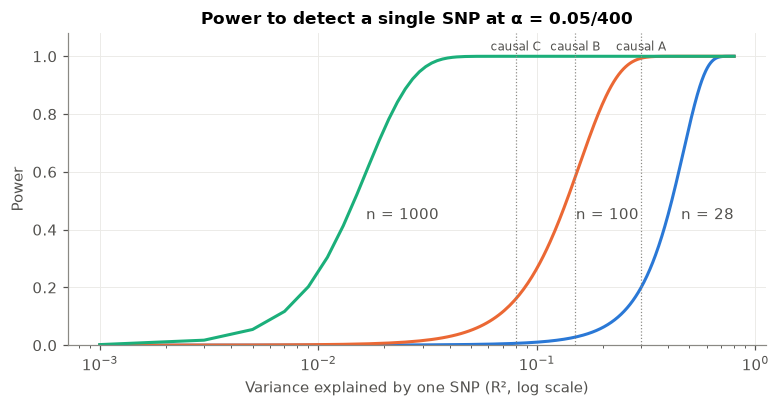

03:51:28 | INFO  | Causal A (R² = 0.30): power at n=28 = 0.20, at n=100 = 0.99


03:51:28 | INFO  | Causal B (R² = 0.15): power at n=28 = 0.03, at n=100 = 0.58


03:51:28 | INFO  | Causal C (R² = 0.08): power at n=28 = 0.01, at n=100 = 0.16


In [6]:
fig, ax = plt.subplots(figsize=(7.2, 3.8))
r2_grid = np.linspace(0.001, 0.8, 400)
alpha_b = 0.05 / M_EFF
for n, col in zip((28, 100, 1000), (PAL["blue"], PAL["orange"], PAL["aqua"])):
    ax.plot(r2_grid, single_snp_power(n, r2_grid, alpha_b), color=col, lw=2)
    # direct label at the curve's 50%-power point
    r50 = r2_grid[np.argmin(np.abs(single_snp_power(n, r2_grid, alpha_b) - 0.5))]
    ax.annotate(f"n = {n}", (r50, 0.5), xytext=(6, -12), textcoords="offset points", color=PAL["ink2"])
for h, lab in zip(CFG["major_h2"], "ABC"):
    ax.axvline(h, color=PAL["gray"], lw=0.8, ls=":")
    ax.text(h, 1.02, f"causal {lab}", ha="center", fontsize=8, color=PAL["ink2"])
ax.set(xscale="log", xlabel="Variance explained by one SNP (R², log scale)", ylabel="Power",
       title=f"Power to detect a single SNP at α = 0.05/{M_EFF:,}", ylim=(0, 1.08))
plt.tight_layout(); plt.show()

for h, lab in zip(CFG["major_h2"], "ABC"):
    logger.info(f"Causal {lab} (R² = {h:.2f}): power at n=28 = {single_snp_power(28, h, alpha_b):.2f}, "
                f"at n=100 = {single_snp_power(100, h, alpha_b):.2f}")

**What to look for.**
* At n = 28 a SNP must explain about **45% of the variance** to survive a Bonferroni correction over ~400 independent tests, and about **70%** for genome-wide significance. Even our strongest causal variant (30%) has low power in a single-SNP test.
* So **do not expect to *discover* SNPs with n = 28**. The realistic goals are (i) *prediction* using a few strong signals, and (ii) *prioritising* candidates for replication. Stability selection (Section 18) serves goal (ii), and Section 15 shows the most effective lever: shrinking the search space.

### 2.2 A second warning: sample LD (r²) is very noisy at n = 28

For two **unlinked** SNPs (true r² = 0), the sample correlation satisfies $n\,r^2 \approx \chi^2_1$, so $\mathbb{E}[r^2] \approx 1/(n-1)$ and $P(r^2 > c) \approx P(\chi^2_1 > n c)$. We use this in Section 7.

In [7]:
rows = []
for n in (28, 100, 500):
    rows.append({"n": n, "E[r²] (null)": 1 / (n - 1), "95th pct": stats.chi2.ppf(0.95, 1) / n,
                 "99th pct": stats.chi2.ppf(0.99, 1) / n, "P(r² > 0.1)": stats.chi2.sf(0.1 * n, 1)})
null_r2_tbl = pd.DataFrame(rows).set_index("n")
logger.info("Sampling distribution of r² between two INDEPENDENT SNPs:\n" + null_r2_tbl.round(4).to_string())
logger.info("→ At n = 28, ~9% of truly independent SNP pairs exceed the r² < 0.1 pruning threshold by chance alone.")

03:51:28 | INFO  | Sampling distribution of r² between two INDEPENDENT SNPs:
     E[r²] (null)  95th pct  99th pct  P(r² > 0.1)
n                                                 
28          0.037    0.1372     0.237       0.0943
100        0.0101    0.0384    0.0663       0.0016
500         0.002    0.0077    0.0133            0


03:51:28 | INFO  | → At n = 28, ~9% of truly independent SNP pairs exceed the r² < 0.1 pruning threshold by chance alone.


## 3. Simulating human genomes with the coalescent (msprime)

**Goal.** Generate haplotypes whose allele frequencies and LD patterns look like real human data.

**Concept (in two sentences).** The coalescent simulates the *genealogy* of a sample backwards in time under a demographic model. Recombination gives each genomic position its own local tree, and mutations dropped on the trees create SNPs. Because the genealogies are shared between nearby positions, **LD emerges naturally** with the right decay pattern. Nothing is imposed by hand.

We use the Gutenkunst *et al.* (2009) Out-of-Africa model:

```
          present ──────────────────────────────────────────────────
           YRI (12,300)        CEU (grows 0.4%/gen)   CHB (grows 0.55%/gen)
              │                     │                     │
              │                     └──────┬──────────────┘  21.2 kya: CEU–CHB split
              │                        OOA bottleneck (2,100)
              └──────────────┬──────────────┘                140 kya: out of Africa
                        ancestral Africa (12,300)
                             │                                220 kya: expansion
                        ancestral (7,300)
```

We sample **European (CEU-like)** and **East-Asian (CHB-like)** individuals. Each 1-Mb segment is simulated independently and behaves like a separate chromosome, since LD does not cross segments.

In [8]:
def build_ooa_demography():
    """Three-population Out-of-Africa model of Gutenkunst et al. (2009).

    Maximum-likelihood parameter estimates from the paper (the same values used by
    stdpopsim's HomSap/OutOfAfrica_3G09). Times are converted from years to generations
    with a 25-year generation time.
    """
    gen = 25
    N_A, N_B, N_AF = 7_300, 2_100, 12_300          # ancestral, bottleneck, African sizes
    N_EU0, N_AS0 = 1_000, 510                      # founding sizes of Europe / East Asia
    r_EU, r_AS = 0.004, 0.0055                     # exponential growth rates per generation
    T_AF, T_B, T_EU_AS = 220e3 / gen, 140e3 / gen, 21.2e3 / gen
    N_EU = N_EU0 / math.exp(-r_EU * T_EU_AS)       # present-day sizes after growth
    N_AS = N_AS0 / math.exp(-r_AS * T_EU_AS)

    d = msprime.Demography()
    d.add_population(name="YRI", initial_size=N_AF)
    d.add_population(name="CEU", initial_size=N_EU, growth_rate=r_EU)
    d.add_population(name="CHB", initial_size=N_AS, growth_rate=r_AS)
    d.add_population(name="OOA", initial_size=N_B)
    d.add_population(name="AMH", initial_size=N_AF)
    d.add_population(name="ANC", initial_size=N_A)
    # present-day migration (per generation, symmetric)
    d.set_symmetric_migration_rate(["YRI", "CEU"], 3e-5)
    d.set_symmetric_migration_rate(["YRI", "CHB"], 1.9e-5)
    d.set_symmetric_migration_rate(["CEU", "CHB"], 9.6e-5)
    # events backwards in time
    d.add_population_split(time=T_EU_AS, derived=["CEU", "CHB"], ancestral="OOA")
    d.add_symmetric_migration_rate_change(time=T_EU_AS, populations=["YRI", "OOA"], rate=25e-5)
    d.add_population_split(time=T_B, derived=["YRI", "OOA"], ancestral="AMH")
    d.add_population_split(time=T_AF, derived=["AMH"], ancestral="ANC")
    d.sort_events()
    return d


demography = build_ooa_demography()
logger.info(f"Out-of-Africa demography built: populations = {[p.name for p in demography.populations]}, "
            f"{len(demography.events)} demographic events (splits / migration changes)")

03:51:28 | INFO  | Out-of-Africa demography built: populations = ['YRI', 'CEU', 'CHB', 'OOA', 'AMH', 'ANC'], 4 demographic events (splits / migration changes)


In [9]:
n_eur_total = CFG["n_ref_eur"] + CFG["n_pool_eur"]
n_eas_total = CFG["n_ref_eas"] + CFG["n_pool_eas"]
geno_blocks, pos_list, chr_list = [], [], []

with log_step(f"Coalescent simulation of {CFG['n_segments']} × {CFG['segment_length']/1e6:.0f} Mb "
              f"for {n_eur_total + n_eas_total} diploid individuals"):
    for s in range(CFG["n_segments"]):
        ts = msprime.sim_ancestry(
            samples={"CEU": n_eur_total, "CHB": n_eas_total},  # diploids per population
            demography=demography,
            sequence_length=CFG["segment_length"],
            recombination_rate=CFG["recomb_rate"],
            random_seed=CFG["seed"] + s + 1)
        mts = msprime.sim_mutations(ts, rate=CFG["mut_rate"], model=msprime.BinaryMutationModel(),
                                    random_seed=CFG["seed"] + 10_000 + s)
        if s == 0:
            # Population label of each diploid individual (2 consecutive sample nodes per individual)
            node_pop = mts.tables.nodes.population[mts.samples()][0::2]
            pop_names = np.array([mts.population(int(p)).metadata["name"] for p in node_pop])
        H = mts.genotype_matrix()                       # sites × haplotypes, values 0/1
        G = (H[:, 0::2] + H[:, 1::2]).astype(np.int8)   # sites × individuals, allele count 0/1/2
        p_alt = G.mean(axis=1) / 2
        keep = np.minimum(p_alt, 1 - p_alt) >= CFG["min_sim_maf"]
        geno_blocks.append(G[keep])
        pos_list.append(mts.tables.sites.position[keep].astype(np.int64) + 1)
        chr_list.append(np.full(keep.sum(), s + 1))
        logger.info(f"  chr{s+1:02d}: {mts.num_trees:>5,} local trees | {mts.num_sites:>6,} segregating sites "
                    f"→ {keep.sum():>5,} with MAF ≥ {CFG['min_sim_maf']:.0%}")

G_all = np.concatenate(geno_blocks, axis=0).T          # individuals × SNPs (int8)
snp_chr = np.concatenate(chr_list)
snp_pos = np.concatenate(pos_list)
snp_id = np.array([f"chr{c}:{p}" for c, p in zip(snp_chr, snp_pos)])
del geno_blocks

# Individual metadata: population and role (reference panel vs study pool)
meta = pd.DataFrame({"iid": [f"IND{i:04d}" for i in range(len(pop_names))],
                     "pop": np.where(pop_names == "CEU", "EUR", "EAS")})
meta["role"] = "pool"
for pop, n_ref in (("EUR", CFG["n_ref_eur"]), ("EAS", CFG["n_ref_eas"])):
    meta.loc[meta.index[meta["pop"] == pop][:n_ref], "role"] = "reference"
logger.info(f"Genotype matrix: {G_all.shape[0]:,} individuals × {G_all.shape[1]:,} SNPs "
            f"({G_all.nbytes/1e6:.0f} MB) | roles: {meta.groupby(['role','pop']).size().to_dict()}")

03:51:28 | INFO  | ▶ Coalescent simulation of 20 × 1 Mb for 1000 diploid individuals


03:51:28 | INFO  |   chr01: 4,233 local trees |  5,728 segregating sites → 1,229 with MAF ≥ 1%


03:51:28 | INFO  |   chr02: 4,432 local trees |  5,959 segregating sites → 1,267 with MAF ≥ 1%


03:51:29 | INFO  |   chr03: 4,042 local trees |  5,686 segregating sites → 1,250 with MAF ≥ 1%


03:51:29 | INFO  |   chr04: 4,164 local trees |  5,677 segregating sites → 1,299 with MAF ≥ 1%


...

03:51:30 | INFO  |   chr18: 4,067 local trees |  5,481 segregating sites → 1,494 with MAF ≥ 1%


03:51:30 | INFO  |   chr19: 4,372 local trees |  5,893 segregating sites → 1,282 with MAF ≥ 1%


03:51:30 | INFO  |   chr20: 4,472 local trees |  5,999 segregating sites → 1,585 with MAF ≥ 1%


03:51:30 | INFO  | ✔ Coalescent simulation of 20 × 1 Mb for 1000 diploid individuals (done in 2.1 s)


03:51:30 | INFO  | Genotype matrix: 1,000 individuals × 27,428 SNPs (27 MB) | roles: {('pool', 'EAS'): 100, ('pool', 'EUR'): 400, ('reference', 'EAS'): 100, ('reference', 'EUR'): 400}


**What to look for.** Each 1-Mb segment has hundreds of local trees, one per recombination interval, and thousands of segregating sites, which matches the ~3–4 SNPs/kb seen in sequenced human samples. For computational convenience we keep only 20 Mb (~0.7% of the genome). A real imputed dataset has 5–10 million common variants, so after QC and pruning you would have **~100,000+** candidate SNPs rather than ~400. That makes the $p \gg n$ problem, and every warning in this notebook, **even more severe** on real data.

## 4. Where continuous dosages come from: simulating genotype imputation

**Goal.** Turn true genotypes $g \in \{0,1,2\}$ into **imputed dosages** $d \in [0,2]$ the way an imputation server (Michigan / TOPMed, Minimac4, Beagle, IMPUTE5) does.

**Concept.** The imputation engine does not know your genotype. It computes a **posterior probability** for each genotype given the array data and the reference haplotypes, then reports the **expected allele count** (the `DS` field in the VCF):

$$ d_{ij} \;=\; \mathbb{E}[\,g_{ij}\mid \text{data}\,] \;=\; 0\cdot P(g{=}0) + 1\cdot P(g{=}1) + 2\cdot P(g{=}2). $$

We mimic this with a simple Bayesian observation model. For person $i$ at variant $j$, the imputation "sees" a noisy signal $z_{ij} = g_{ij} + \sigma_j\varepsilon_{ij}$ and combines it with a Hardy–Weinberg prior built from the reference-panel allele frequency $p_j$:

$$ P(g \mid z) \;\propto\; \underbrace{\binom{2}{g}p_j^g(1-p_j)^{2-g}}_{\text{HWE prior}} \;\cdot\; \underbrace{\phi\!\left(\tfrac{z-g}{\sigma_j}\right)}_{\text{likelihood}} $$

* Small $\sigma_j$ (well-tagged variant): posteriors are near 0/1, and dosages cluster at 0, 1 and 2.
* Large $\sigma_j$ (poorly tagged or rare variant): dosages are **shrunk toward the mean $2p_j$**.

**Rsq (Minimac) / INFO.** Shrinkage lowers the variance of the dosages, and that is exactly what the quality metric measures:

$$ \text{Rsq}_j = \frac{\operatorname{Var}(d_{\cdot j})}{2\hat p_j(1-\hat p_j)} \;\approx\; \operatorname{corr}(d_{\cdot j}, g_{\cdot j})^2 . $$

**A useful consequence (regression calibration).** Because $d = \mathbb{E}[g\mid\text{data}]$, regressing the phenotype on the dosage gives an **unbiased per-allele effect**. What you lose is *variance explained* (≈ multiplied by Rsq), and therefore power. This is one reason dosages beat hard calls: rounding throws away the calibration.

In [10]:
def impute_dosages(G_true, p_prior, sigma, rng):
    """Simulate imputed dosages from true genotypes via a Bayesian noisy-observation model.

    G_true : (n, m) int   true allele counts 0/1/2
    p_prior: (m,)         alternative-allele frequency in the reference panel (HWE prior)
    sigma  : (m,)         per-variant observation noise (larger → worse imputation)
    Returns dosages (n, m) float32 = posterior expected allele count.
    """
    Z = G_true + rng.normal(size=G_true.shape).astype(np.float32) * sigma          # noisy signal
    log_prior = np.log(np.stack([(1 - p_prior) ** 2, 2 * p_prior * (1 - p_prior), p_prior ** 2]))
    log_post = np.stack([log_prior[g] - (Z - g) ** 2 / (2 * sigma ** 2) for g in (0, 1, 2)])
    log_post -= log_post.max(axis=0, keepdims=True)                              # numerical stability
    post = np.exp(log_post)
    post /= post.sum(axis=0, keepdims=True)
    return (post[1] + 2 * post[2]).astype(np.float32)


def minimac_rsq(D):
    """Minimac-style imputation quality: observed dosage variance / expected binomial variance."""
    p = D.mean(axis=0) / 2
    expected = 2 * p * (1 - p)
    with np.errstate(divide="ignore", invalid="ignore"):
        r = np.where(expected > 1e-8, D.var(axis=0) / expected, 0.0)
    return np.clip(r, 0, 1)


rng_imp = np.random.default_rng(CFG["seed"] + 1)
ref_idx = np.flatnonzero(meta["role"] == "reference")
pool_idx = np.flatnonzero(meta["role"] == "pool")
G_ref = G_all[ref_idx]                                   # reference panel: TRUE genotypes (like WGS)
G_pool_true = G_all[pool_idx]                            # study pool: true genotypes (hidden from us!)
meta_pool = meta.iloc[pool_idx].reset_index(drop=True)

p_ref = np.clip(G_ref.mean(axis=0) / 2, 1e-3, 1 - 1e-3)
maf_ref = np.minimum(p_ref, 1 - p_ref)
m_snps = G_all.shape[1]

# Per-variant imputation difficulty: log-normal spread, worse for rare variants, ~exact for array SNPs
is_array = rng_imp.random(m_snps) < CFG["array_fraction"]
sigma_imp = (np.exp(rng_imp.normal(np.log(CFG["imp_sigma_median"]), CFG["imp_sigma_logsd"], m_snps))
             * (0.25 / np.maximum(maf_ref, 0.02)) ** CFG["imp_maf_exponent"]).astype(np.float32)
sigma_imp[is_array] = 0.02

with log_step("Imputing dosages for the study pool"):
    D_pool = impute_dosages(G_pool_true.astype(np.float32), p_ref.astype(np.float32), sigma_imp, rng_imp)

rsq_pool = minimac_rsq(D_pool)
with np.errstate(invalid="ignore"):
    emp_r2 = np.array([np.corrcoef(D_pool[:, j], G_pool_true[:, j])[0, 1] ** 2
                       if G_pool_true[:, j].std() > 0 else np.nan for j in range(m_snps)])
logger.info(f"Dosage matrix (pool): {D_pool.shape} | array-genotyped variants: {is_array.sum():,}")
logger.info(f"Rsq quantiles (5/25/50/75/95%): {np.round(np.nanpercentile(rsq_pool, [5,25,50,75,95]), 3)}")
logger.info(f"Fraction with Rsq ≥ 0.3: {np.mean(rsq_pool >= 0.3):.1%} | ≥ 0.8: {np.mean(rsq_pool >= 0.8):.1%}")
logger.info(f"Calibration: corr(Rsq, empirical dosage r² with truth) = "
            f"{pd.Series(rsq_pool).corr(pd.Series(emp_r2)):.3f}")

03:51:30 | INFO  | ▶ Imputing dosages for the study pool


03:51:32 | INFO  | ✔ Imputing dosages for the study pool (done in 2.3 s)


03:51:34 | INFO  | Dosage matrix (pool): (500, 27428) | array-genotyped variants: 776


03:51:34 | INFO  | Rsq quantiles (5/25/50/75/95%): [0.103 0.539 0.905 1.    1.   ]


03:51:34 | INFO  | Fraction with Rsq ≥ 0.3: 85.8% | ≥ 0.8: 59.9%


03:51:34 | INFO  | Calibration: corr(Rsq, empirical dosage r² with truth) = 0.986


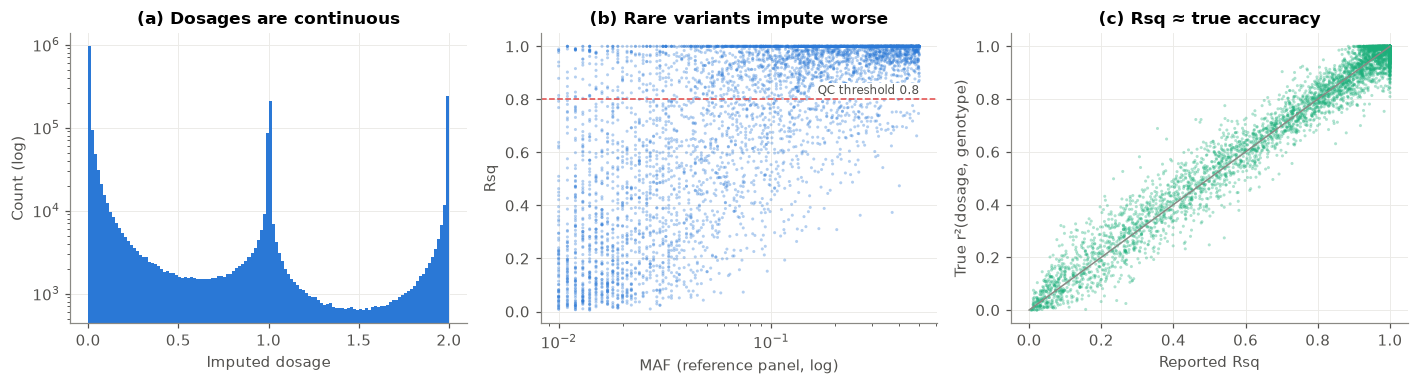

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
# (a) distribution of dosage values: peaks at 0/1/2 with uncertainty in between
axes[0].hist(D_pool[:, ::7].ravel(), bins=120, color=PAL["blue"], edgecolor="none")
axes[0].set(yscale="log", xlabel="Imputed dosage", ylabel="Count (log)", title="(a) Dosages are continuous")
# (b) Rsq falls with MAF
common = maf_ref >= 0.01
axes[1].scatter(maf_ref[common][::5], rsq_pool[common][::5], s=4, alpha=0.35, color=PAL["blue"], edgecolors="none")
axes[1].axhline(CFG["rsq_min"], color=PAL["red"], lw=1, ls="--")
axes[1].text(0.5, CFG["rsq_min"] + 0.02, f"QC threshold {CFG['rsq_min']}", ha="right", fontsize=8, color=PAL["ink2"],
             bbox=dict(facecolor="white", edgecolor="none", pad=1))
axes[1].set(xscale="log", xlabel="MAF (reference panel, log)", ylabel="Rsq", title="(b) Rare variants impute worse")
# (c) Rsq is a good proxy for true accuracy
ok = np.isfinite(emp_r2)
axes[2].scatter(rsq_pool[ok][::5], emp_r2[ok][::5], s=4, alpha=0.35, color=PAL["aqua"], edgecolors="none")
axes[2].plot([0, 1], [0, 1], color=PAL["gray"], lw=1)
axes[2].set(xlabel="Reported Rsq", ylabel="True r²(dosage, genotype)", title="(c) Rsq ≈ true accuracy")
plt.tight_layout(); plt.show()

**What to look for.** (a) Most dosages sit at 0, 1 or 2, with a continuum in between: these are the "continuous dosage variables" that penalized regression handles natively. (b) Imputation quality drops for rare variants. (c) The reported Rsq tracks the *true* squared correlation with the genotype, which is why filtering on Rsq works.

## 5. Simulating the phenotype: an oligogenic trait with known truth

**Goal.** Create a continuous phenotype (think: log-transformed stable drug dose, or a circulating biomarker) with an architecture similar to warfarin dose or Lp(a):

$$ y_i \;=\; \underbrace{\sum_{k\in\{A,B,C\}} \beta_k g_{ik}}_{\text{3 large effects}} \;+\; \underbrace{\sum_{l=1}^{200} \gamma_l g_{il}}_{\text{polygenic background}} \;+\; \underbrace{\theta_1\,\text{sex}_i + \theta_2\,\text{age}_i}_{\text{covariates}} \;+\; \underbrace{\eta\,\mathbb{1}[\text{EAS}_i]}_{\text{ancestry confounder}} \;+\; \varepsilon_i $$

| Component | Variance explained |
|---|---|
| Causal A: common SNP inside a **strong LD block** (comparable to the two *LPA* SNPs for Lp(a), or the *VKORC1* haplotype for warfarin dose) | 30% |
| Causal B | 15% |
| Causal C | 8% |
| Polygenic background (200 tiny effects) | 5% |
| Sex + age | 8% |
| Ancestry-correlated non-genetic shift (e.g. diet or environment) | 4% |
| Noise | ≈ 30% |

The phenotype is built from the **true** genotypes. We only ever observe the **imputed dosages**, just like in a real study.

In [12]:
def corr_r2(A, B):
    """Squared Pearson correlation between every column of A and every column of B."""
    A = (A - A.mean(0)) / np.where(A.std(0) > 0, A.std(0), 1)
    B = (B - B.mean(0)) / np.where(B.std(0) > 0, B.std(0), 1)
    return (A.T @ B / len(A)) ** 2


rng_ph = np.random.default_rng(CFG["seed"] + 2)
G_ref_f = G_ref.astype(np.float32)

# ── Choose the three major causal variants ──────────────────────────────────
cand = np.flatnonzero((maf_ref >= 0.20) & ~is_array & (rsq_pool >= 0.5))
cand_sub = rng_ph.choice(cand, size=min(600, len(cand)), replace=False)
n_strong_proxies = np.zeros(len(cand_sub), int)
for t, j in enumerate(cand_sub):                        # count LD proxies (r² > 0.8 within ±100 kb)
    nb = np.flatnonzero((snp_chr == snp_chr[j]) & (np.abs(snp_pos - snp_pos[j]) <= 100_000))
    nb = nb[nb != j]
    n_strong_proxies[t] = (corr_r2(G_ref_f[:, [j]], G_ref_f[:, nb])[0] > 0.8).sum()

causal_A = cand_sub[np.argmax(n_strong_proxies)]        # the SNP with the largest high-LD block
others = [(j, k) for j, k in zip(cand_sub, n_strong_proxies) if snp_chr[j] != snp_chr[causal_A] and 1 <= k <= 10]
causal_B = others[0][0]
causal_C = next(j for j, _ in others[1:] if snp_chr[j] not in (snp_chr[causal_A], snp_chr[causal_B]))
causal = np.array([causal_A, causal_B, causal_C])
CAUSAL_LABEL = dict(zip(causal, ["A", "B", "C"]))

def scaled_effect(g, target_var):
    """Effect size so that the component `effect * g` has variance `target_var` (total variance ≈ 1)."""
    v = np.var(g)
    return np.sqrt(target_var / v) if v > 0 else 0.0

Gp = G_pool_true.astype(np.float64)
signs = rng_ph.choice([-1, 1], size=3)
beta_major = np.array([s * scaled_effect(Gp[:, j], h) for s, j, h in zip(signs, causal, CFG["major_h2"])])

poly_idx = rng_ph.choice(np.setdiff1d(np.arange(m_snps), causal), size=CFG["n_poly"], replace=False)
gamma = rng_ph.normal(size=CFG["n_poly"])
poly_score = Gp[:, poly_idx] @ gamma
poly_score *= np.sqrt(CFG["poly_h2"] / poly_score.var())

n_pool = len(meta_pool)
sex = rng_ph.integers(0, 2, n_pool).astype(float)                 # 0 = female, 1 = male
age = np.clip(rng_ph.normal(55, 10, n_pool), 25, 85)
is_eas = (meta_pool["pop"] == "EAS").to_numpy().astype(float)
comp = pd.DataFrame({
    "causal_A": Gp[:, causal_A] * beta_major[0], "causal_B": Gp[:, causal_B] * beta_major[1],
    "causal_C": Gp[:, causal_C] * beta_major[2], "polygenic": poly_score,
    "sex": sex * scaled_effect(sex, CFG["sex_var"]), "age": age * scaled_effect(age, CFG["age_var"]),
    "ancestry": is_eas * scaled_effect(is_eas, CFG["ancestry_var"]),
})
noise_var = 1 - sum([*CFG["major_h2"], CFG["poly_h2"], CFG["sex_var"], CFG["age_var"], CFG["ancestry_var"]])
comp["noise"] = rng_ph.normal(0, np.sqrt(noise_var), n_pool)
y_pool = comp.sum(axis=1).to_numpy()
y_pool = (y_pool - y_pool.mean()) / y_pool.std()                   # z-scored phenotype

# ── Negative-control trait (Section 19): same covariates, purely polygenic genetics ──
neg_idx = rng_ph.choice(np.arange(m_snps), size=CFG["negctrl_n_causal"], replace=False)
neg_g = Gp[:, neg_idx] @ rng_ph.normal(size=CFG["negctrl_n_causal"])
neg_g *= np.sqrt(CFG["negctrl_h2"] / neg_g.var())
y_neg_pool = neg_g + comp["sex"] + comp["age"] + comp["ancestry"] + rng_ph.normal(
    0, np.sqrt(1 - CFG["negctrl_h2"] - CFG["sex_var"] - CFG["age_var"] - CFG["ancestry_var"]), n_pool)
y_neg_pool = ((y_neg_pool - y_neg_pool.mean()) / y_neg_pool.std()).to_numpy()

truth = pd.DataFrame({"label": ["A", "B", "C"], "snp": snp_id[causal], "maf_ref": maf_ref[causal],
                      "rsq_pool": rsq_pool[causal], "array_snp": is_array[causal],
                      "n_proxies_r2>0.8": [n_strong_proxies[list(cand_sub).index(j)] for j in causal],
                      "beta_per_allele": beta_major / np.std(comp.sum(axis=1)),
                      "target_R2": CFG["major_h2"]})
logger.info("Ground-truth causal variants (hidden from the analysis!):\n" + truth.to_string(index=False))
logger.info("Realised variance components in the pool (fraction of total):\n" +
            (comp.var() / comp.sum(axis=1).var()).round(3).to_string())

03:51:35 | INFO  | Ground-truth causal variants (hidden from the analysis!):
label          snp  maf_ref  rsq_pool  array_snp  n_proxies_r2>0.8  beta_per_allele  target_R2
    A chr14:490391    0.455         1      False                28          -0.7745        0.3
    B chr15:554136    0.461         1      False                 7          -0.5404       0.15
    C chr11:596298    0.479         1      False                 7          -0.3912       0.08


03:51:35 | INFO  | Realised variance components in the pool (fraction of total):
causal_A     0.31
causal_B    0.155
causal_C    0.083
polygenic   0.052
sex         0.052
age         0.031
ancestry    0.041
noise       0.283


### 5.1 Drawing the study cohort (n = 28) and a hidden validation set

We draw **22 European + 6 East-Asian** people from the pool: this is *your study*. The remaining 472 pool members form a **hidden validation set**. A real study never has one, but here it lets us check whether the cross-validated R² from 28 people tells the truth (Section 16). We also split the pool into disjoint "replicate cohorts" of the same design, to see how much results would change if a *different* 28 people had been recruited.

In [13]:
rng_coh = np.random.default_rng(CFG["seed"] + 3)
eur_pool = rng_coh.permutation(np.flatnonzero(meta_pool["pop"] == "EUR"))
eas_pool = rng_coh.permutation(np.flatnonzero(meta_pool["pop"] == "EAS"))
ne, na = CFG["n_cohort_eur"], CFG["n_cohort_eas"]
max_reps = min(len(eur_pool) // ne, len(eas_pool) // na)
replicate_cohorts = [np.sort(np.r_[eur_pool[r*ne:(r+1)*ne], eas_pool[r*na:(r+1)*na]]) for r in range(max_reps)]
coh = replicate_cohorts[0]                                        # ← OUR STUDY COHORT
val = np.setdiff1d(np.arange(n_pool), coh)                        # hidden validation set
n = len(coh)

y = y_pool[coh]
logger.info(f"Study cohort: n = {n} ({(meta_pool['pop'][coh]=='EUR').sum()} EUR, "
            f"{(meta_pool['pop'][coh]=='EAS').sum()} EAS) | hidden validation: {len(val)} | "
            f"disjoint replicate cohorts available: {max_reps}")
logger.info(f"Phenotype in cohort: mean = {y.mean():+.2f}, SD = {y.std():.2f}, "
            f"Shapiro–Wilk p = {stats.shapiro(y).pvalue:.2f}")

# How much does each component explain *in these particular 28 people*? (sampling noise!)
coh_share = (comp.iloc[coh].var() / comp.iloc[coh].sum(axis=1).var()).round(3)
logger.info("Variance components realised in the 28-person cohort (compare with pool values above):\n"
            + coh_share.to_string())

03:51:35 | INFO  | Study cohort: n = 28 (22 EUR, 6 EAS) | hidden validation: 472 | disjoint replicate cohorts available: 16


03:51:35 | INFO  | Phenotype in cohort: mean = -0.22, SD = 1.04, Shapiro–Wilk p = 0.51


03:51:35 | INFO  | Variance components realised in the 28-person cohort (compare with pool values above):
causal_A    0.328
causal_B    0.113
causal_C    0.065
polygenic   0.053
sex         0.047
age         0.024
ancestry     0.04
noise       0.251


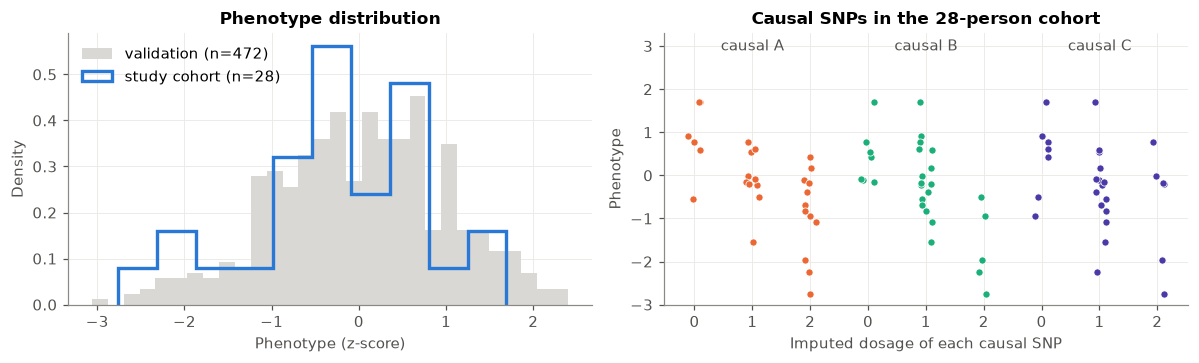

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
axes[0].hist(y_pool[val], bins=30, density=True, color=PAL["lightgray"], label="validation (n=472)")
axes[0].hist(y, bins=10, density=True, histtype="step", lw=2.2, color=PAL["blue"], label="study cohort (n=28)")
axes[0].set(xlabel="Phenotype (z-score)", ylabel="Density", title="Phenotype distribution"); axes[0].legend()
for k, (j, lab) in enumerate(zip(causal, "ABC")):
    jitter = rng_coh.uniform(-0.12, 0.12, n)
    axes[1].scatter(D_pool[coh, j] + jitter + 3 * k, y, s=22, color=CAUSAL_COLORS[k], edgecolors="white", linewidths=0.5)
    axes[1].text(3 * k + 1, 2.9, f"causal {lab}", ha="center", color=PAL["ink2"])
axes[1].set(xticks=[0, 1, 2, 3, 4, 5, 6, 7, 8], xticklabels=["0", "1", "2"] * 3, ylim=(-3, 3.3),
            xlabel="Imputed dosage of each causal SNP", ylabel="Phenotype", title="Causal SNPs in the 28-person cohort")
plt.tight_layout(); plt.show()

## 6. Variant quality control at n = 28

**Goal.** Remove variants that are unreliable (poor imputation) or uninformative (too rare to estimate anything).

| Filter | Threshold | Reasoning specific to n = 28 |
|---|---|---|
| Polymorphic in cohort | dosage SD > 0 | a constant column carries no information |
| **MAF** | ≥ 0.10 | **Minor-allele count** MAC = 2·n·MAF. At MAF = 0.05 there are only ~3 copies of the minor allele in 28 people, so any "effect" rests on 1–3 individuals. At 0.10, MAC ≥ 5.6 |
| **Rsq** | ≥ 0.8 | strict: noisy dosages dilute signal, and n = 28 cannot absorb that loss |
| HWE | p ≥ 10⁻⁶ | flags genotyping artefacts. At n = 28 the test has almost **no power**, so expect it to remove nothing. On real data run it on the *genotyped array* SNPs before imputation |

> **Leakage note.** These filters use only the genotypes, never the phenotype, so applying them once to all 28 people does **not** leak phenotype information into the cross-validation. (Strictly, the held-out person's genotype contributes to the MAF estimate. That is unsupervised and its effect is negligible.)
>
> **Rsq caveat.** Rsq computed from only 28 dosages is itself noisy. If the imputation server reports Rsq from a larger batch, use that value.

In [15]:
def hwe_chisq_pvalue(D):
    """1-df chi-square Hardy–Weinberg test on hard-called genotypes (dosage rounded to 0/1/2)."""
    hard = np.rint(D)
    n_ = hard.shape[0]
    n0, n1, n2 = (hard == 0).sum(0), (hard == 1).sum(0), (hard == 2).sum(0)
    p = (n1 + 2 * n2) / (2 * n_)
    exp = np.stack([n_ * (1 - p) ** 2, 2 * n_ * p * (1 - p), n_ * p ** 2])
    obs = np.stack([n0, n1, n2])
    with np.errstate(divide="ignore", invalid="ignore"):
        chi = np.nansum(np.where(exp > 0, (obs - exp) ** 2 / exp, 0), axis=0)
    return stats.chi2.sf(chi, 1)


def qc_variants(D, maf_min, rsq_min, hwe_p_min, verbose=True):
    """Apply the QC funnel to a cohort dosage matrix. Returns (keep mask, per-SNP stats, funnel table)."""
    n_ = D.shape[0]
    p = D.mean(0) / 2
    maf = np.minimum(p, 1 - p)
    st = pd.DataFrame({"maf": maf, "mac": 2 * n_ * maf, "rsq": minimac_rsq(D), "hwe_p": hwe_chisq_pvalue(D)})
    steps = [("all simulated variants", np.ones(len(st), bool)),
             ("polymorphic in cohort", D.std(0) > 0),
             (f"MAF ≥ {maf_min} (MAC ≥ {2*n_*maf_min:.1f})", st["maf"].to_numpy() >= maf_min),
             (f"Rsq ≥ {rsq_min}", st["rsq"].to_numpy() >= rsq_min),
             (f"HWE p ≥ {hwe_p_min:g}", st["hwe_p"].to_numpy() >= hwe_p_min)]
    keep = np.ones(len(st), bool)
    funnel = []
    for name, mask in steps:
        before = keep.sum()
        keep &= mask
        funnel.append({"step": name, "remaining": keep.sum(), "removed": before - keep.sum()})
    funnel = pd.DataFrame(funnel)
    if verbose:
        logger.info("QC funnel:\n" + funnel.to_string(index=False))
    return keep, st, funnel


D_coh = D_pool[coh]
with log_step("Variant QC on the 28-person cohort"):
    qc_keep, snp_stats, qc_funnel = qc_variants(D_coh, CFG["maf_min"], CFG["rsq_min"], CFG["hwe_p_min"])

for j, lab in zip(causal, "ABC"):
    logger.info(f"  causal {lab} ({snp_id[j]}): cohort MAF = {snp_stats.maf[j]:.2f}, Rsq = {snp_stats.rsq[j]:.2f} "
                f"→ {'PASSES' if qc_keep[j] else 'REMOVED by'} QC")

03:51:36 | INFO  | ▶ Variant QC on the 28-person cohort


03:51:36 | INFO  | QC funnel:
                  step  remaining  removed
all simulated variants      27428        0
 polymorphic in cohort      27334       94
 MAF ≥ 0.1 (MAC ≥ 5.6)      13752    13582
             Rsq ≥ 0.8      10212     3540
         HWE p ≥ 1e-06      10212        0


03:51:36 | INFO  | ✔ Variant QC on the 28-person cohort (done in 0.0 s)


03:51:36 | INFO  |   causal A (chr14:490391): cohort MAF = 0.39, Rsq = 1.00 → PASSES QC


03:51:36 | INFO  |   causal B (chr15:554136): cohort MAF = 0.46, Rsq = 0.85 → PASSES QC


03:51:36 | INFO  |   causal C (chr11:596298): cohort MAF = 0.48, Rsq = 0.93 → PASSES QC


## 7. Linkage disequilibrium: intuition and a pitfall

**Concept.** For unphased dosage data, the LD statistic used for pruning is simply the **squared Pearson correlation between the dosage vectors** of two SNPs (this is what PLINK `--indep-pairwise` computes):

$$ r^2_{jk} = \operatorname{corr}(d_{\cdot j}, d_{\cdot k})^2 . $$

High r² means the two SNPs carry (almost) the same information, so a regression cannot tell which one is causal. Three experiments follow:

1. **The pitfall.** r² between SNPs on *different chromosomes* (true LD = 0), estimated from 28 people vs. 500 reference-panel people.
2. **LD decay** with physical distance in the reference panel.
3. **An LD heatmap** around causal A.

In [16]:
rng_ld = np.random.default_rng(CFG["seed"] + 4)
qc_idx = np.flatnonzero(qc_keep)

# (1) r² between random pairs of UNLINKED SNPs (different pseudo-chromosomes)
a = rng_ld.choice(qc_idx, 4000); b = rng_ld.choice(qc_idx, 4000)
unlinked = snp_chr[a] != snp_chr[b]
a, b = a[unlinked], b[unlinked]
def paired_r2(M, a, b):
    A = M[:, a].astype(float); B = M[:, b].astype(float)
    A = (A - A.mean(0)) / np.where(A.std(0) > 0, A.std(0), 1)
    B = (B - B.mean(0)) / np.where(B.std(0) > 0, B.std(0), 1)
    return (A * B).mean(0) ** 2
r2_null_coh = paired_r2(D_coh, a, b)
r2_null_ref = paired_r2(G_ref, a, b)
logger.info(f"Unlinked SNP pairs: {len(a):,} | fraction with r² > {CFG['prune_r2']}: "
            f"cohort (n=28) = {np.mean(r2_null_coh > CFG['prune_r2']):.1%}, "
            f"reference (n={len(ref_idx)}) = {np.mean(r2_null_ref > CFG['prune_r2']):.1%} "
            f"[theory for n=28: {stats.chi2.sf(0.1 * 28, 1):.1%}]")

# (2) LD decay in the reference panel
dist_all, r2_all = [], []
for c in range(1, CFG["n_segments"] + 1):
    idx = rng_ld.choice(np.flatnonzero((snp_chr == c) & qc_keep), 250, replace=False)
    R2 = corr_r2(G_ref_f[:, idx], G_ref_f[:, idx])
    iu = np.triu_indices(len(idx), 1)
    dist_all.append(np.abs(snp_pos[idx][:, None] - snp_pos[idx][None, :])[iu]); r2_all.append(R2[iu])
dist_all, r2_all = np.concatenate(dist_all), np.concatenate(r2_all)
bins = np.logspace(2, 6, 25)
bin_id = np.digitize(dist_all, bins)
decay = pd.DataFrame({"d": dist_all, "r2": r2_all, "bin": bin_id}).groupby("bin").agg(d=("d", "median"), r2=("r2", "mean"))
half = decay.loc[decay.r2 <= decay.r2.iloc[0] / 2, "d"]
logger.info(f"LD decay: mean r² at <1 kb = {decay.r2.iloc[0]:.2f}; falls to half by ~{half.iloc[0]/1e3:.0f} kb; "
            f"background at 1 Mb ≈ {decay.r2.iloc[-1]:.3f}")

03:51:36 | INFO  | Unlinked SNP pairs: 3,796 | fraction with r² > 0.1: cohort (n=28) = 13.6%, reference (n=500) = 0.7% [theory for n=28: 9.4%]


03:51:36 | INFO  | LD decay: mean r² at <1 kb = 0.66; falls to half by ~12 kb; background at 1 Mb ≈ 0.009


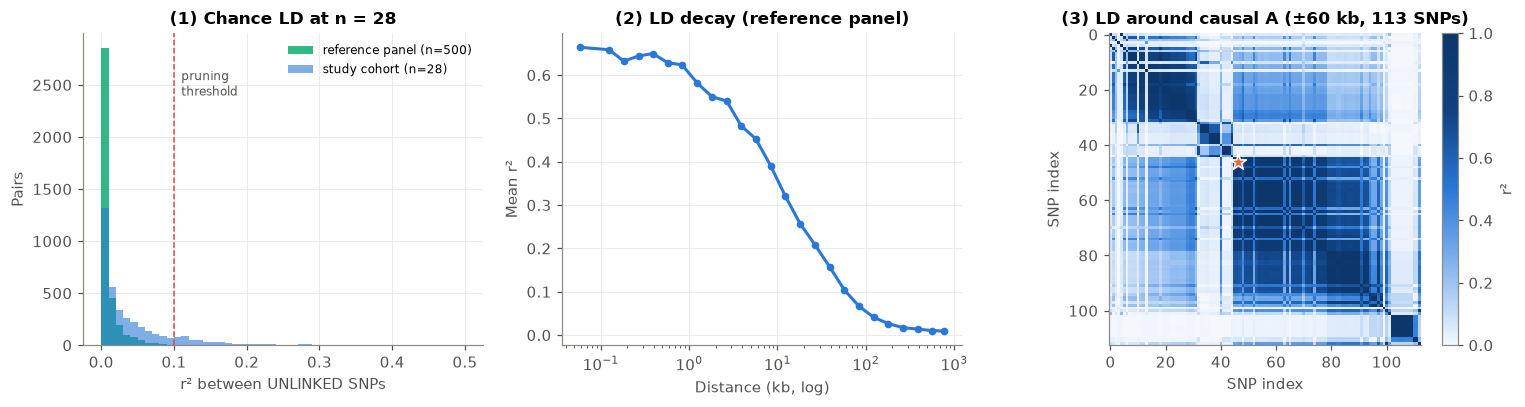

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.8), gridspec_kw={"width_ratios": [1, 1, 1.05]})
bins_r2 = np.linspace(0, 0.5, 51)
axes[0].hist(r2_null_ref, bins=bins_r2, color=PAL["aqua"], alpha=0.9, label=f"reference panel (n={len(ref_idx)})")
axes[0].hist(r2_null_coh, bins=bins_r2, color=PAL["blue"], alpha=0.6, label="study cohort (n=28)")
axes[0].axvline(CFG["prune_r2"], color=PAL["red"], ls="--", lw=1)
axes[0].text(CFG["prune_r2"] + 0.01, axes[0].get_ylim()[1] * 0.8, "pruning\nthreshold", fontsize=8, color=PAL["ink2"])
axes[0].set(xlabel="r² between UNLINKED SNPs", ylabel="Pairs", title="(1) Chance LD at n = 28"); axes[0].legend(fontsize=8)

axes[1].plot(decay.d / 1e3, decay.r2, marker="o", ms=4, color=PAL["blue"], lw=2)
axes[1].set(xscale="log", xlabel="Distance (kb, log)", ylabel="Mean r²", title="(2) LD decay (reference panel)")

win = np.flatnonzero((snp_chr == snp_chr[causal_A]) & qc_keep & (np.abs(snp_pos - snp_pos[causal_A]) <= 60_000))
R2w = corr_r2(G_ref_f[:, win], G_ref_f[:, win])
im = axes[2].imshow(R2w, cmap=SEQ_BLUE, vmin=0, vmax=1, interpolation="nearest")
ca = int(np.flatnonzero(win == causal_A)[0]) if causal_A in win else None
if ca is not None:
    axes[2].scatter([ca], [ca], marker="*", s=120, color=PAL["orange"], edgecolors="white", zorder=3)
axes[2].set(title=f"(3) LD around causal A (±60 kb, {len(win)} SNPs)", xlabel="SNP index", ylabel="SNP index")
axes[2].grid(False)
plt.colorbar(im, ax=axes[2], fraction=0.046, label="r²")
plt.tight_layout(); plt.show()

**What to look for.**
1. **The pitfall.** In the cohort (blue), a large share of *truly independent* SNP pairs exceeds r² = 0.1 **by chance**. The share is even higher than the 9% predicted in Section 2.2, because the cohort mixes two ancestries: allele-frequency differences between EUR and EAS make unlinked SNPs correlated (*structure-induced LD*), which is also why a few reference-panel pairs exceed 0.1. Pruning on LD estimated from 28 people therefore throws away many independent SNPs essentially at random. **Estimate LD from an ancestry-matched reference panel** (1000 Genomes, HRC or gnomAD haplotypes, or the imputation reference itself), where the null distribution (green) is tight.
2. LD falls off within tens of kb, in line with European data.
3. Causal A sits in a block of highly correlated SNPs. Any of them would "explain" the signal equally well.

## 8. LD pruning in pure Python (PLINK-style `--indep-pairwise 50 5 0.1`)

**Goal.** Keep a subset of SNPs such that no two SNPs within a sliding window have r² > 0.1.

**Algorithm** (same logic as PLINK):
1. Slide a window of 50 SNPs along each chromosome, moving 5 SNPs at a time.
2. Within the window, compute the pairwise r² among SNPs still retained.
3. While any pair has r² > threshold, drop one SNP of the most correlated pair (the one with the **lower MAF**, as PLINK 2 does).

**Why prune before penalized regression?** It reduces $p$, removes near-duplicate columns that make Lasso's choice arbitrary, and gives "one SNP ≈ one independent signal", which makes selection frequencies interpretable. **Cost:** the causal variant itself may be pruned away and replaced by a *tag SNP*. We check this against the ground truth below.

In [18]:
def ld_prune(G_ld, chrom, pos, maf, candidates, window=50, step=5, r2_thr=0.1):
    """PLINK-style sliding-window LD pruning.

    G_ld       : (n_ld, m) genotype/dosage matrix used to ESTIMATE LD (reference panel or cohort)
    candidates : indices of SNPs eligible for pruning (e.g. those passing QC)
    Returns a boolean mask (length m) of retained SNPs.
    """
    keep = np.zeros(G_ld.shape[1], bool)
    keep[candidates] = True
    n_removed = 0
    for c in np.unique(chrom[candidates]):
        idx = candidates[chrom[candidates] == c]
        idx = idx[np.argsort(pos[idx])]
        # standardise once per chromosome → r² is then a scaled cross-product
        Z = G_ld[:, idx].astype(np.float64)
        sd = Z.std(0)
        Z = (Z - Z.mean(0)) / np.where(sd > 0, sd, 1)
        for start in range(0, len(idx), step):
            w = np.arange(start, min(start + window, len(idx)))
            w = w[keep[idx[w]]]
            if len(w) < 2:
                continue
            R2 = (Z[:, w].T @ Z[:, w] / Z.shape[0]) ** 2
            np.fill_diagonal(R2, 0)
            alive = np.ones(len(w), bool)
            while True:
                sub = np.where(np.outer(alive, alive), R2, 0)
                i, j = np.unravel_index(np.argmax(sub), sub.shape)
                if sub[i, j] <= r2_thr:
                    break
                drop = i if maf[idx[w[i]]] < maf[idx[w[j]]] else j     # drop the lower-MAF SNP
                alive[drop] = False
                keep[idx[w[drop]]] = False
                n_removed += 1
    return keep


maf_coh = snp_stats["maf"].to_numpy()
with log_step("LD pruning with REFERENCE-panel LD"):
    pruned_ref = ld_prune(G_ref, snp_chr, snp_pos, maf_coh, qc_idx,
                          CFG["prune_window"], CFG["prune_step"], CFG["prune_r2"])
with log_step("LD pruning with COHORT (n = 28) LD, for comparison only"):
    pruned_coh = ld_prune(D_coh, snp_chr, snp_pos, maf_coh, qc_idx,
                          CFG["prune_window"], CFG["prune_step"], CFG["prune_r2"])

logger.info(f"SNPs after QC: {qc_keep.sum():,} → after pruning with reference LD: {pruned_ref.sum():,} "
            f"| with cohort LD: {pruned_coh.sum():,}")
logger.info(f"Overlap between the two pruned sets: {(pruned_ref & pruned_coh).sum():,} SNPs "
            f"(Jaccard = {(pruned_ref & pruned_coh).sum() / (pruned_ref | pruned_coh).sum():.2f})")

03:51:36 | INFO  | ▶ LD pruning with REFERENCE-panel LD


03:51:37 | INFO  | ✔ LD pruning with REFERENCE-panel LD (done in 0.1 s)


03:51:37 | INFO  | ▶ LD pruning with COHORT (n = 28) LD, for comparison only


03:51:37 | INFO  | ✔ LD pruning with COHORT (n = 28) LD, for comparison only (done in 0.1 s)


03:51:37 | INFO  | SNPs after QC: 10,212 → after pruning with reference LD: 379 | with cohort LD: 314


03:51:37 | INFO  | Overlap between the two pruned sets: 235 SNPs (Jaccard = 0.51)


In [19]:
# ── Did the causal variants (or good proxies) survive pruning? ──────────────
feat_idx = np.flatnonzero(pruned_ref)            # ← FINAL FEATURE SET used for modelling
feat_names = snp_id[feat_idx]
p_feat = len(feat_idx)

# r² (reference panel) between every retained SNP and every causal SNP (same chromosome only)
tag_r2 = np.zeros((p_feat, 3))
for k, j in enumerate(causal):
    same = snp_chr[feat_idx] == snp_chr[j]
    tag_r2[same, k] = corr_r2(G_ref_f[:, feat_idx[same]], G_ref_f[:, [j]])[:, 0]
TAG_THR = 0.5   # a retained SNP "tags" a causal variant if r² ≥ 0.5 (reference panel)

for k, (j, lab) in enumerate(zip(causal, "ABC")):
    retained = j in feat_idx
    best = tag_r2[:, k].argmax()
    logger.info(f"  causal {lab}: {'RETAINED' if retained else 'pruned/removed'}; best retained proxy "
                f"{feat_names[best]} with r² = {tag_r2[best, k]:.2f}")
logger.info(f"Feature matrix for modelling: n = {n} × p = {p_feat:,} (p/n = {p_feat / n:.0f})")

03:51:37 | INFO  |   causal A: pruned/removed; best retained proxy chr14:500517 with r² = 0.59


03:51:37 | INFO  |   causal B: pruned/removed; best retained proxy chr15:507555 with r² = 0.27


03:51:37 | INFO  |   causal C: pruned/removed; best retained proxy chr11:593949 with r² = 0.98


03:51:37 | INFO  | Feature matrix for modelling: n = 28 × p = 379 (p/n = 14)


### 8.1 The price of pruning, and an alternative: LD *clumping* inside each fold

Pruning is **phenotype-blind**. Inside an LD block it keeps whichever SNP survives the MAF tie-breaks, which is often *not* the SNP most correlated with the causal variant. Worse, pruning is greedy and chained: SNP *a* is removed because of *b*, then *b* is removed because of *c*. The only guarantee is that each removed SNP had r² > 0.1 with *something* at the time. The log above shows how well each causal variant is still tagged after pruning.

**Clumping** (as in PLINK `--clump`, and the "C" in C+T polygenic scores) is the phenotype-*aware* version:

1. Rank SNPs by association strength $|r(x_j, y)|$.
2. Take the strongest SNP as an *index SNP*. Remove every SNP within 250 kb with r² > 0.1 to it.
3. Repeat with the strongest remaining SNP.

The index SNPs are again ~independent, but each LD block is now represented by its **most associated** SNP. Because clumping uses the phenotype, it **must run inside every outer training fold**, never on the full data (Section 12). Only the LD neighbour lists, which are phenotype-free, are computed once from the reference panel.

In [20]:
def build_ld_neighbours(G_ld, chrom, pos, cols, r2_thr, max_kb):
    """Phenotype-free pre-computation for clumping.

    For every SNP in `cols`, return the positions (indices 0..len(cols)-1) of the other SNPs on the same
    chromosome within `max_kb` whose r² (estimated in G_ld, e.g. the reference panel) exceeds `r2_thr`.
    """
    nbrs = [np.array([], dtype=int)] * len(cols)
    for c in np.unique(chrom[cols]):
        loc = np.flatnonzero(chrom[cols] == c)
        Z = G_ld[:, cols[loc]].astype(np.float64)
        sd = Z.std(0)
        Z = (Z - Z.mean(0)) / np.where(sd > 0, sd, 1)
        R2 = (Z.T @ Z / Z.shape[0]) ** 2
        close = np.abs(pos[cols[loc]][:, None] - pos[cols[loc]][None, :]) <= max_kb * 1000
        M = (R2 > r2_thr) & close
        np.fill_diagonal(M, False)
        for a, i in enumerate(loc):
            nbrs[i] = loc[np.flatnonzero(M[a])]
    return nbrs


def clump(scores, nbrs):
    """Greedy LD clumping: walk SNPs from strongest to weakest score, keep an index SNP, drop its LD neighbours."""
    removed = np.zeros(len(scores), bool)
    keep = []
    for j in np.argsort(-scores):
        if removed[j]:
            continue
        keep.append(j)
        removed[nbrs[j]] = True
    return np.array(keep)


with log_step(f"Reference-panel LD neighbour lists for clumping (r² > {CFG['clump_r2']}, ±{CFG['clump_kb']} kb)"):
    X_qc = D_coh[:, qc_idx].astype(np.float64)            # all QC-passing SNPs (unpruned)
    nbrs_qc = build_ld_neighbours(G_ref, snp_chr, snp_pos, qc_idx, CFG["clump_r2"], CFG["clump_kb"])
logger.info(f"Median LD neighbours per SNP: {np.median([len(v) for v in nbrs_qc]):.0f}")

# Illustration only (uses the phenotype of all 28 → NOT for performance estimation): clump on the full cohort
r_full = np.array([np.corrcoef(X_qc[:, j], y)[0, 1] if X_qc[:, j].std() > 0 else 0 for j in range(len(qc_idx))])
idx_snps = qc_idx[clump(np.abs(r_full), nbrs_qc)]
qc_pos_of = {j: t for t, j in enumerate(qc_idx)}
for k, (j, lab) in enumerate(zip(causal, "ABC")):
    if j in qc_pos_of:
        best = max(idx_snps[snp_chr[idx_snps] == snp_chr[j]], key=lambda s_: corr_r2(G_ref_f[:, [s_]], G_ref_f[:, [j]])[0, 0])
        logger.info(f"  causal {lab}: best-tagging CLUMP index SNP {snp_id[best]} with r² = "
                    f"{corr_r2(G_ref_f[:, [best]], G_ref_f[:, [j]])[0, 0]:.2f} (pruning gave r² = {tag_r2[:, k].max():.2f})")
logger.info(f"Clumping keeps {len(idx_snps):,} index SNPs (pruning kept {p_feat:,}).")

03:51:37 | INFO  | ▶ Reference-panel LD neighbour lists for clumping (r² > 0.1, ±250 kb)


03:51:37 | INFO  | ✔ Reference-panel LD neighbour lists for clumping (r² > 0.1, ±250 kb) (done in 0.1 s)


03:51:37 | INFO  | Median LD neighbours per SNP: 53


03:51:37 | INFO  |   causal A: best-tagging CLUMP index SNP chr14:490248 with r² = 1.00 (pruning gave r² = 0.59)


03:51:37 | INFO  |   causal B: best-tagging CLUMP index SNP chr15:554011 with r² = 1.00 (pruning gave r² = 0.27)


03:51:37 | INFO  |   causal C: best-tagging CLUMP index SNP chr11:608866 with r² = 0.62 (pruning gave r² = 0.98)


03:51:37 | INFO  | Clumping keeps 621 index SNPs (pruning kept 379).


## 9. Population structure and covariates

**Goal.** Build a covariate matrix: sex, age, and ancestry principal component(s).

**Why project from a reference panel?** PCA on 28 people is unstable, because the PCs mostly capture noise. Instead we compute the PC axes in the reference panel (500 people) and **project** the cohort onto them. This is the standard approach for small studies, e.g. projecting onto 1000 Genomes PCs.

**Why only one PC?** Every unpenalized covariate costs a degree of freedom. With n = 28 we keep the covariate set minimal: sex, age and PC1. PC1 separates the European and East-Asian ancestry that is present in this cohort.

In [21]:
def fit_reference_pca(G_ref_sub, n_pc=10):
    """PCA on standardised reference genotypes. Returns (mean, sd, loadings[n_pc × p], variance ratios)."""
    mu = G_ref_sub.mean(0)
    sd = G_ref_sub.std(0)
    sd = np.where(sd > 0, sd, 1)
    Z = (G_ref_sub - mu) / sd
    U, S, Vt = np.linalg.svd(Z, full_matrices=False)
    return mu, sd, Vt[:n_pc], (S ** 2 / (S ** 2).sum())[:n_pc], (U * S)[:, :n_pc]


def project_pcs(D, pca):
    mu, sd, V, _, _ = pca
    return ((D - mu) / sd) @ V.T


with log_step("Reference-panel PCA on the pruned SNPs"):
    pca_ref = fit_reference_pca(G_ref_f[:, feat_idx])
pcs_coh = project_pcs(D_coh[:, feat_idx], pca_ref)
logger.info(f"Variance explained by reference PCs 1–5: {np.round(pca_ref[3][:5], 3)}")


def make_covariates(sex_, age_, pcs_, n_pc=CFG["n_pcs"]):
    """Covariate matrix [sex, age, PC1..PCk] (intercept is added later)."""
    return np.column_stack([sex_, age_, pcs_[:, :n_pc]])


COV_NAMES = ["sex", "age"] + [f"PC{i+1}" for i in range(CFG["n_pcs"])]
C = make_covariates(sex[coh], age[coh], pcs_coh)
cov_df = pd.DataFrame(C, columns=COV_NAMES)
cov_df["pop"] = meta_pool["pop"].to_numpy()[coh]
logger.info("Covariate–phenotype correlations in the cohort: " +
            ", ".join(f"{c}: r = {np.corrcoef(C[:, i], y)[0, 1]:+.2f}" for i, c in enumerate(COV_NAMES)))

03:51:37 | INFO  | ▶ Reference-panel PCA on the pruned SNPs


03:51:37 | INFO  | ✔ Reference-panel PCA on the pruned SNPs (done in 0.0 s)


03:51:37 | INFO  | Variance explained by reference PCs 1–5: [0.077 0.01  0.01  0.01  0.01 ]


03:51:37 | INFO  | Covariate–phenotype correlations in the cohort: sex: r = +0.38, age: r = -0.13, PC1: r = -0.02


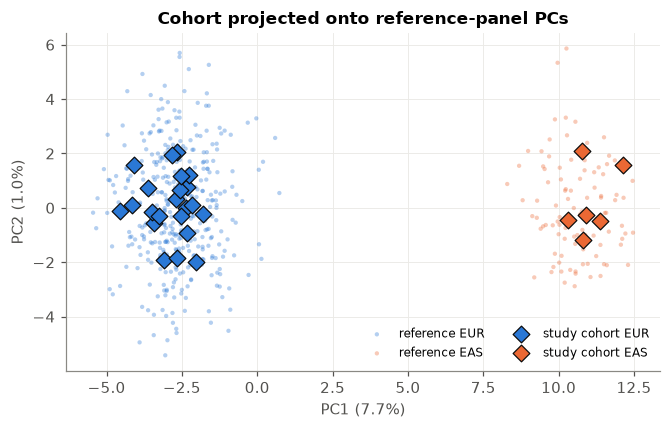

In [22]:
fig, ax = plt.subplots(figsize=(6.2, 4))
ref_pops = meta["pop"].to_numpy()[ref_idx]
for pop, col in (("EUR", PAL["blue"]), ("EAS", PAL["orange"])):
    m_ = ref_pops == pop
    ax.scatter(pca_ref[4][m_, 0], pca_ref[4][m_, 1], s=8, alpha=0.35, color=col, edgecolors="none", label=f"reference {pop}")
for pop, col in (("EUR", PAL["blue"]), ("EAS", PAL["orange"])):
    m_ = cov_df["pop"].to_numpy() == pop
    ax.scatter(pcs_coh[m_, 0], pcs_coh[m_, 1], s=60, marker="D", color=col, edgecolors=PAL["ink"], linewidths=0.8,
               label=f"study cohort {pop}")
ax.set(xlabel=f"PC1 ({pca_ref[3][0]:.1%})", ylabel=f"PC2 ({pca_ref[3][1]:.1%})",
       title="Cohort projected onto reference-panel PCs"); ax.legend(fontsize=8, ncol=2)
plt.tight_layout(); plt.show()

## 10. The math: from OLS to Ridge, Lasso and Elastic Net

### 10.1 Why ordinary least squares fails when p ≫ n

OLS minimises $\|y - X\beta\|_2^2$. With $n = 28$ people and $p \approx 400$ SNPs, the centred design $X$ has rank at most $n-1 = 27$, so there are **infinitely many** $\beta$ with *zero* training error. The model interpolates noise perfectly: training R² = 1, and it tells you nothing about new people.

### 10.2 Penalized regression: add a price for large coefficients

scikit-learn's Elastic Net solves

$$
\hat\beta \;=\; \arg\min_{\beta}\; \frac{1}{2n}\,\|y - X\beta\|_2^2 \;+\; \lambda\Big[\rho\,\|\beta\|_1 \;+\; \frac{1-\rho}{2}\,\|\beta\|_2^2\Big]
$$

| sklearn name | glmnet (R) name | meaning |
|---|---|---|
| `alpha` | `lambda` ($\lambda$) | overall penalty **strength** |
| `l1_ratio` | `alpha` ($\rho$) | **mix** between L1 ($\rho=1$, Lasso) and L2 ($\rho=0$, Ridge) |

> ⚠️ **Naming trap:** "α" means *strength* in scikit-learn but *mixing* in glmnet. When a paper says "we tuned α", check which software it used.

* **Ridge** ($\rho=0$): shrinks all coefficients smoothly toward 0 but **never exactly to 0**. No feature selection.
* **Lasso** ($\rho=1$): the L1 penalty sets many coefficients **exactly to 0**. This is embedded feature selection.
* **Elastic Net** ($0<\rho<1$): sparse like Lasso, and stable under correlation like Ridge.

### 10.3 Why the L1 penalty gives exact zeros: soft-thresholding

For an orthonormal design the solution is available in closed form, per coefficient:

$$
\hat\beta_j^{\text{ridge}} = \frac{\hat\beta_j^{\text{OLS}}}{1+\lambda}, \qquad
\hat\beta_j^{\text{lasso}} = S\!\left(\hat\beta_j^{\text{OLS}},\,\lambda\right), \qquad
\hat\beta_j^{\text{EN}} = \frac{S\!\left(\hat\beta_j^{\text{OLS}},\,\lambda\rho\right)}{1+\lambda(1-\rho)}
$$

where $S(z,\gamma) = \operatorname{sign}(z)\,(|z|-\gamma)_+$ is the **soft-thresholding** operator. Any SNP whose marginal effect is smaller than $\gamma$ is set **exactly** to zero. The coordinate-descent algorithm in scikit-learn and glmnet applies this operator repeatedly, one coefficient at a time.

### 10.4 Geometry

Equivalently, minimise the RSS subject to the penalty staying below a budget. The RSS contours are ellipses around the OLS solution, and the solution is where the smallest ellipse touches the constraint region. The L1 region (a diamond) has **corners on the axes**, so the contact point very often lies at a corner, where one coefficient is exactly 0.

### 10.5 The grouping effect (Zou & Hastie 2005)

For two standardized predictors with correlation $r$, the Elastic Net solution satisfies

$$ |\hat\beta_j - \hat\beta_k| \;\le\; \frac{C(y)}{\lambda(1-\rho)}\,\sqrt{2(1-r)} , $$

so as $r \to 1$ (SNPs in perfect LD) their coefficients are forced to be **equal**. Lasso has no such property: it picks one SNP of a correlated group essentially at random.

### 10.6 Covariates without penalty: the Frisch–Waugh–Lovell (FWL) trick

We want sex, age and PC1 in the model **unpenalized** (glmnet's `penalty.factor = 0`), but scikit-learn has no such option. The FWL theorem says that, if the covariates are unpenalized, the penalized SNP coefficients are identical to those obtained by first **regressing the covariates out of both $y$ and $X$** and then fitting the penalized model on the residuals. We do this *inside each training fold*, using training data only.

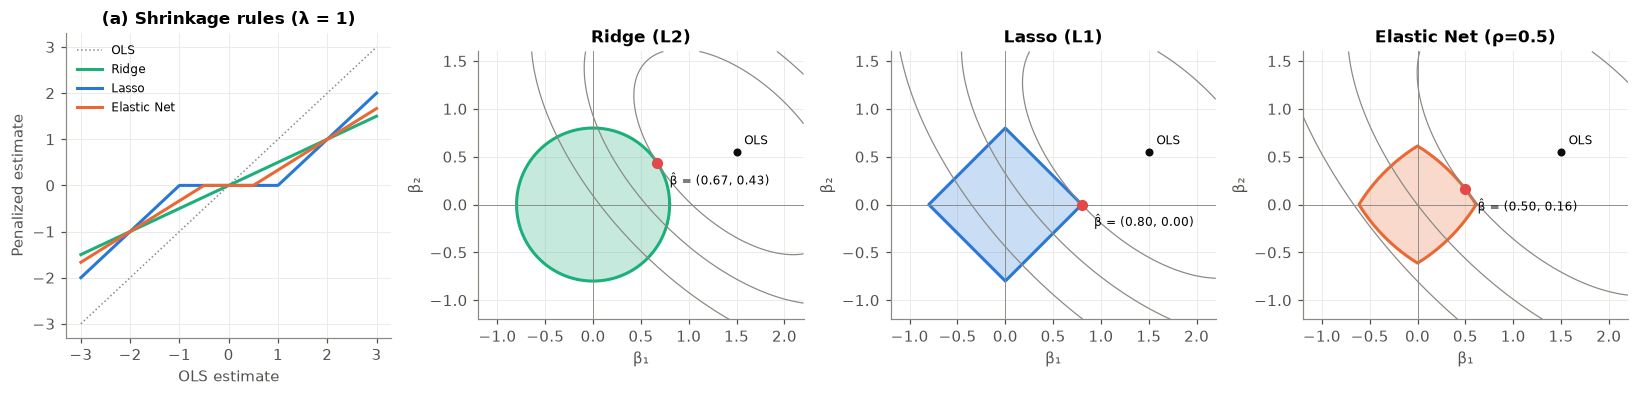

In [23]:
fig, axes = plt.subplots(1, 4, figsize=(15, 3.7))
# ── (a) soft-thresholding vs ridge shrinkage ────────────────────────────────
z = np.linspace(-3, 3, 400); lam, rho = 1.0, 0.5
soft = lambda z_, g: np.sign(z_) * np.maximum(np.abs(z_) - g, 0)
axes[0].plot(z, z, color=PAL["gray"], lw=1, ls=":", label="OLS")
axes[0].plot(z, z / (1 + lam), color=PAL["aqua"], lw=2, label="Ridge")
axes[0].plot(z, soft(z, lam), color=PAL["blue"], lw=2, label="Lasso")
axes[0].plot(z, soft(z, lam * rho) / (1 + lam * (1 - rho)), color=PAL["orange"], lw=2, label="Elastic Net")
axes[0].set(xlabel="OLS estimate", ylabel="Penalized estimate", title="(a) Shrinkage rules (λ = 1)")
axes[0].legend(fontsize=8)

# ── (b–d) constraint geometry ───────────────────────────────────────────────
b_ols = np.array([1.5, 0.55])
A = np.array([[1.0, 0.55], [0.55, 1.0]])                  # X'X for two correlated predictors
Q = lambda B: np.einsum("...i,ij,...j->...", B - b_ols, A, B - b_ols)
th = np.linspace(0, 2 * np.pi, 2000); cs, sn = np.cos(th), np.sin(th)
t_budget = 0.8
radii = {
    "Ridge (L2)": np.full_like(th, t_budget),
    "Lasso (L1)": t_budget / (np.abs(cs) + np.abs(sn)),
}
a_q, b_q = (1 - rho) / 2, rho * (np.abs(cs) + np.abs(sn))      # EN: a r² + b r = t
radii["Elastic Net (ρ=0.5)"] = (-b_q + np.sqrt(b_q ** 2 + 4 * a_q * (0.5 * t_budget))) / (2 * a_q)
g1, g2 = np.meshgrid(np.linspace(-1.2, 2.2, 300), np.linspace(-1.2, 1.6, 300))
QQ = Q(np.stack([g1, g2], -1))
for ax, (name, r), col in zip(axes[1:], radii.items(), (PAL["aqua"], PAL["blue"], PAL["orange"])):
    boundary = np.c_[r * cs, r * sn]
    k = np.argmin(Q(boundary)); sol = boundary[k]
    ax.fill(boundary[:, 0], boundary[:, 1], color=col, alpha=0.25, lw=0)
    ax.plot(boundary[:, 0], boundary[:, 1], color=col, lw=2)
    ax.contour(g1, g2, QQ, levels=Q(sol) * np.array([1, 2.2, 4]), colors=PAL["gray"], linewidths=0.8)
    ax.scatter(*b_ols, color=PAL["ink"], s=18, zorder=3); ax.annotate("OLS", b_ols, xytext=(5, 5), textcoords="offset points", fontsize=8)
    ax.scatter(*sol, color=PAL["red"], s=40, zorder=4)
    ax.annotate(f"β̂ = ({sol[0]:.2f}, {sol[1]:.2f})", sol, xytext=(8, -14), textcoords="offset points", fontsize=8)
    ax.axhline(0, color=PAL["gray"], lw=0.6); ax.axvline(0, color=PAL["gray"], lw=0.6)
    ax.set(aspect="equal", xlim=(-1.2, 2.2), ylim=(-1.2, 1.6), xlabel="β₁", ylabel="β₂", title=name)
plt.tight_layout(); plt.show()

**What to look for.** (a) Ridge only rescales. Lasso has a **flat zero region**: estimates with |z| < λ become exactly 0. Elastic Net has both a zero region and extra shrinkage. (b–d) The Lasso solution lands on a **corner** (β₂ = 0), which is feature selection. Ridge keeps both coefficients non-zero. Elastic Net is in between.

### 10.7 Demonstration: OLS on our cohort

In [24]:
X = D_coh[:, feat_idx].astype(np.float64)           # n × p dosage matrix of pruned SNPs
Xc = X - X.mean(0)
yc = y - y.mean()
beta_mn = np.linalg.pinv(Xc) @ yc                    # minimum-norm least-squares solution
r2_train = 1 - np.sum((yc - Xc @ beta_mn) ** 2) / np.sum(yc ** 2)
logger.info(f"Rank of centred X = {np.linalg.matrix_rank(Xc)} (n − 1 = {n-1}) while p = {p_feat:,}")
logger.info(f"Minimum-norm OLS TRAINING R² = {r2_train:.6f}  ← perfect fit to 28 people, i.e. pure memorisation")

loo_pred = np.empty(n)
for i in range(n):
    tr = np.arange(n) != i
    mu = X[tr].mean(0)
    b = np.linalg.pinv(X[tr] - mu) @ (y[tr] - y[tr].mean())
    loo_pred[i] = y[tr].mean() + (X[i] - mu) @ b
logger.info(f"Same model, leave-one-out R² = {1 - np.sum((y - loo_pred)**2) / np.sum((y - y.mean())**2):+.3f}  "
            "← what it is actually worth on new people")

03:51:38 | INFO  | Rank of centred X = 27 (n − 1 = 27) while p = 379


03:51:38 | INFO  | Minimum-norm OLS TRAINING R² = 1.000000  ← perfect fit to 28 people, i.e. pure memorisation


03:51:38 | INFO  | Same model, leave-one-out R² = -0.347  ← what it is actually worth on new people


## 11. Lasso vs Elastic Net inside a real LD block

**Goal.** Show the grouping effect directly. First a toy example with two *identical* SNP columns, then the LD block around causal A.

For the block example we use the **unpruned** QC-passing SNPs within ±150 kb of causal A, and the large validation set (n = 472), so the behaviour is clearly visible and not drowned out by n = 28 noise.

In [25]:
# ── Toy: two perfectly correlated copies of one SNP ─────────────────────────
rng_toy = np.random.default_rng(7)
g = rng_toy.binomial(2, 0.3, 300).astype(float)
Xtoy = np.column_stack([g, g, rng_toy.binomial(2, 0.3, 300)])      # SNP1 ≡ SNP2 (perfect LD), SNP3 null
Xtoy = (Xtoy - Xtoy.mean(0)) / Xtoy.std(0)
ytoy = Xtoy[:, 0] + rng_toy.normal(0, 1, 300)
toy = pd.DataFrame({
    "Lasso (λ=0.05)": Lasso(alpha=0.05).fit(Xtoy, ytoy).coef_,
    "Elastic Net (λ=0.05, ρ=0.5)": ElasticNet(alpha=0.05, l1_ratio=0.5).fit(Xtoy, ytoy).coef_,
}, index=["SNP1", "SNP2 (= SNP1)", "SNP3 (null)"])
logger.info("Toy example, coefficients:\n" + toy.round(3).to_string())
logger.info("→ Lasso gives all the weight to ONE copy (an arbitrary choice); Elastic Net splits it equally.")

03:51:38 | INFO  | Toy example, coefficients:
               Lasso (λ=0.05)  Elastic Net (λ=0.05, ρ=0.5)
SNP1                    0.954                        0.484
SNP2 (= SNP1)               0                        0.482
SNP3 (null)                 0                            0


03:51:38 | INFO  | → Lasso gives all the weight to ONE copy (an arbitrary choice); Elastic Net splits it equally.


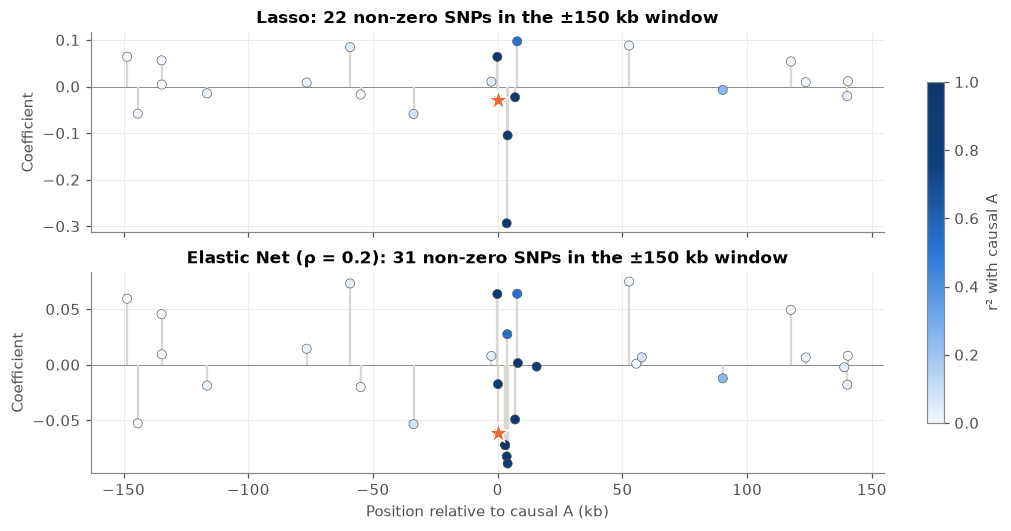

03:51:40 | INFO  | Window: 171 SNPs, 28 in strong LD (r² > 0.8) with causal A. Lasso keeps 22 SNPs; Elastic Net keeps 31.


In [26]:
blk = np.flatnonzero(qc_keep & (snp_chr == snp_chr[causal_A]) & (np.abs(snp_pos - snp_pos[causal_A]) <= 150_000))
Xb = D_pool[np.ix_(val, blk)].astype(float)
Xb = (Xb - Xb.mean(0)) / np.where(Xb.std(0) > 0, Xb.std(0), 1)
yb = y_pool[val] - y_pool[val].mean()
r2_to_A = corr_r2(G_ref_f[:, blk], G_ref_f[:, [causal_A]])[:, 0]
with warnings.catch_warnings():
    warnings.simplefilter("ignore", ConvergenceWarning)
    las = LassoCV(cv=5, random_state=0).fit(Xb, yb)
    en = ElasticNetCV(l1_ratio=0.2, cv=5, random_state=0).fit(Xb, yb)

fig, axes = plt.subplots(2, 1, figsize=(10, 5.2), sharex=True)
kb = (snp_pos[blk] - snp_pos[causal_A]) / 1e3
for ax, mdl, name in ((axes[0], las, "Lasso"), (axes[1], en, "Elastic Net (ρ = 0.2)")):
    nz = mdl.coef_ != 0
    ax.axhline(0, color=PAL["gray"], lw=0.6)
    ax.vlines(kb[nz], 0, mdl.coef_[nz], color=PAL["lightgray"], lw=1.5)
    sc = ax.scatter(kb[nz], mdl.coef_[nz], c=r2_to_A[nz], cmap=SEQ_BLUE, vmin=0, vmax=1, s=36, edgecolors=PAL["ink2"], linewidths=0.4, zorder=3)
    ax.scatter([0], [mdl.coef_[np.flatnonzero(blk == causal_A)[0]]] if causal_A in blk else [0], marker="*", s=200,
               color=PAL["orange"], edgecolors="white", zorder=4)
    ax.set(ylabel="Coefficient", title=f"{name}: {nz.sum()} non-zero SNPs in the ±150 kb window")
axes[1].set_xlabel("Position relative to causal A (kb)")
fig.colorbar(sc, ax=axes, fraction=0.02, label="r² with causal A")
plt.show()
logger.info(f"Window: {len(blk)} SNPs, {np.sum(r2_to_A > 0.8)} in strong LD (r² > 0.8) with causal A. "
            f"Lasso keeps {np.sum(las.coef_ != 0)} SNPs; Elastic Net keeps {np.sum(en.coef_ != 0)}.")

**What to look for.** Lasso concentrates the signal on one or a few SNPs of the block, and which ones it picks can change from sample to sample. Elastic Net spreads the weight across the dark-blue (high-r² with causal A) SNPs: **it keeps the correlated group together**.

> 🔑 **An important subtlety that is often missed.** After strict LD pruning (r² < 0.1) there are **no correlated groups left**, so Elastic Net's grouping advantage largely disappears and Elastic Net ≈ Lasso on pruned data. You have two coherent strategies:
> * **Prune, then Lasso/EN.** Fewer, independent features. Clean interpretation (one SNP ≈ one locus). Recommended at n = 28.
> * **Don't prune, then EN with a moderate ρ.** EN handles LD by grouping. Selection is at the level of *blocks*, and $p$ is much larger.
>
> Mixing both (prune *and* rely on EN grouping) is not wrong, but the grouping argument then no longer justifies choosing EN. Section 14 runs both strategies.

## 12. Validation at n = 28: why LOOCV, and why *nested*

### 12.1 Why not a train/test split or 10-fold CV?
* A 70/30 split tests on **8 people**. The resulting R² is almost pure noise, and 30% of an already tiny dataset is thrown away.
* 10-fold CV uses test folds of 2–3 people. Per-fold R² is undefined or meaningless, and results depend heavily on the random split.
* **Leave-one-out CV** trains on 27 (the most data we can afford), predicts each person exactly once, and is deterministic for the outer loop.

### 12.2 How to compute R² from LOOCV
**Never average per-fold R²** (with one test person it is undefined). Pool the 28 held-out predictions and compute

$$ R^2_{\text{LOO}} = 1 - \frac{\sum_i (y_i - \hat y_{-i})^2}{\sum_i (y_i - \bar y)^2} = 1 - \frac{\text{PRESS}}{\text{TSS}}, $$

where $\hat y_{-i}$ is the prediction for person $i$ from the model trained without $i$. **$R^2_{\text{LOO}}$ can be negative.** That means the model predicts worse than the mean.

### 12.3 A subtle bias every small-n researcher should know
The simplest possible "model" predicts the training mean. Under LOO, $\hat y_{-i} = \bar y_{-i} = (n\bar y - y_i)/(n-1)$, so $y_i - \hat y_{-i} = \frac{n}{n-1}(y_i - \bar y)$ and therefore

$$ R^2_{\text{LOO}}(\text{mean model}) = 1 - \left(\frac{n}{n-1}\right)^2 = 1 - (28/27)^2 \approx -0.075 . $$

So **zero is not the baseline**. A model with no information scores about −0.075, not 0. The held-out person's value is always on the "opposite side" of the training mean, so this model's LOO predictions are even *perfectly negatively* correlated with y (Pearson r = −1, visible in the §14 table).

### 12.4 Nested CV: the inner loop must not see the outer test person
Tuning λ and ρ by cross-validation and then reporting that same CV score is optimistic: you picked the best of many models on the data you evaluate on (Varma & Simon 2006). The fix:

| Step | Uses phenotype? | Where it must happen |
|---|---|---|
| QC (MAF, Rsq, HWE), LD pruning (reference LD), PCA (reference) | no | may be done once, outside CV |
| Regressing covariates out (FWL) | **yes** | inside each outer fold, on the 27 training people |
| Standardising SNPs | no (but uses test data if done globally) | inside each outer fold, with training statistics |
| **Univariate GWAS ranking for pre-selection** | **yes** | **inside each outer fold** (otherwise: Ambroise & McLachlan 2002 selection bias) |
| Choosing λ, ρ (and λ-rule) | **yes** | inner CV on the 27 training people only |
| Scoring | yes | only on the held-out person |

In [27]:
loo_mean_pred = (y.sum() - y) / (n - 1)
r2_null_loo = 1 - np.sum((y - loo_mean_pred) ** 2) / np.sum((y - y.mean()) ** 2)
logger.info(f"LOOCV R² of the 'predict the training mean' model: {r2_null_loo:.4f} "
            f"(theory: 1 − (n/(n−1))² = {1 - (n/(n-1))**2:.4f})")

03:51:40 | INFO  | LOOCV R² of the 'predict the training mean' model: -0.0754 (theory: 1 − (n/(n−1))² = -0.0754)


## 13. A transparent nested-LOOCV engine

**Design.** One function, `fit_predict_split`, takes *any* train/test split and does everything that must be learned from training data:

1. **FWL covariate adjustment.** Fit $y \sim 1 + C$ and $X \sim 1 + C$ on the training people only, then residualize both training and test data with those coefficients.
2. **Standardise** SNPs with training means and SDs.
3. Call each **model family** on the prepared data. A family can return several named variants (e.g. EN with λ_min, λ_1SE and a ≤5-SNP cap) from a single inner-CV fit.
4. Final prediction = covariate part + genetic part.

`nested_loocv` loops this over the 28 outer folds and logs each fold. The same `fit_predict_split` is reused for the final model, the external validation, the permutation test and the replicate cohorts, so **exactly the same pipeline** is evaluated everywhere.

### Model families

| Name | What it does | Inner tuning |
|---|---|---|
| Null (training mean) | predicts $\bar y_{\text{train}}$ | – |
| Covariates only (OLS) | sex + age + PC1 | – |
| OLS, all SNPs (min-norm) | the failure mode from §10.7 | – |
| Lasso (λ_min) | ρ = 1 | repeated 5-fold, λ minimising CV-MSE |
| **Elastic Net (λ_min)** | ρ ∈ {0.7, 0.8, 0.9} | repeated 5-fold, (λ, ρ) minimising CV-MSE |
| **Elastic Net (λ_1SE)** | same fit | **largest λ within 1 SE of the minimum**: a sparser, more conservative model (Hastie *et al.*, ESL §7.10) |
| Elastic Net (λ_1SE, ≤5 SNPs) | same fit | if λ_1SE still selects > 5 SNPs, raise λ until ≤ 5. This encodes the prior "at most ~n/5 SNPs"; it is fixed in advance, so it is legitimate inside nested CV |
| **Clump + Elastic Net** (λ_min, λ_1SE, ≤5 SNPs) | in-fold LD clumping of all QC'd SNPs (§8.1), then EN on the index SNPs | as Elastic Net |
| **GWAS top-k + Ridge** (k = 2, 3) | univariate ranking inside the fold, then Ridge on the top k | efficient LOO for Ridge λ |
| Extra Trees / Random Forest (depth ≤ 3) | shallow ensembles, `min_samples_leaf = 4`, √p features per split | fixed (no tuning, to save df) |

**About the 1-SE rule.** With 27 training people the CV-MSE curve is flat and noisy, and λ_min tends to land on a model with too many SNPs. The 1-SE rule deliberately chooses the *simplest* model that is statistically indistinguishable from the best one. That matches the advice "if the model selects more than 3–5 SNPs, it is probably overfitting", but the rule is data-driven instead of a hard cap.

In [28]:
@dataclass
class SplitData:
    """Everything a model family needs for one train/test split (all already FWL-adjusted & scaled)."""
    Xtr: np.ndarray        # standardized, covariate-residualized training SNPs
    Xte: np.ndarray        # same transform applied to the test people
    ytr: np.ndarray        # covariate-residualized training phenotype (mean 0)
    Xtr_raw: np.ndarray    # raw training dosages (for tree models)
    Xte_raw: np.ndarray
    seed: int


def prepare_split(Xtr_raw, ytr, Ctr, Xte_raw, Cte):
    """Frisch–Waugh–Lovell residualization and standardization using TRAINING data only."""
    Ctr1 = np.column_stack([np.ones(len(Ctr)), Ctr])
    Cte1 = np.column_stack([np.ones(len(Cte)), Cte])
    gamma_y, *_ = np.linalg.lstsq(Ctr1, ytr, rcond=None)          # y ~ 1 + covariates
    y_res = ytr - Ctr1 @ gamma_y
    Gam_x, *_ = np.linalg.lstsq(Ctr1, Xtr_raw, rcond=None)        # each SNP ~ 1 + covariates
    Xtr_res = Xtr_raw - Ctr1 @ Gam_x
    Xte_res = Xte_raw - Cte1 @ Gam_x
    sd = Xtr_res.std(0)
    informative = sd > 1e-8                                        # SNP may be monomorphic in 27 people
    sd = np.where(informative, sd, 1.0)
    return Xtr_res / sd * informative, Xte_res / sd * informative, y_res, Cte1 @ gamma_y


# ─────────────────────────────── model families ───────────────────────────────
def enet_family(l1_ratios, prefix="Elastic Net", variants=("min", "1se", "cap"),
                n_alphas=CFG["n_alphas"], inner_splits=CFG["inner_splits"],
                inner_repeats=CFG["inner_repeats"], max_snps=CFG["max_snps"], tol=1e-4):
    """Elastic Net / Lasso tuned by an INNER repeated K-fold CV on the training people only."""
    l1_ratios = list(l1_ratios)

    def fit(d: SplitData):
        inner = RepeatedKFold(n_splits=inner_splits, n_repeats=inner_repeats, random_state=d.seed)
        out = {}
        with warnings.catch_warnings():
            # Very small λ on p ≫ n can hit max_iter; those λ are never chosen, so silence the warning.
            warnings.simplefilter("ignore", ConvergenceWarning)
            cv = ElasticNetCV(l1_ratio=l1_ratios, alphas=n_alphas, cv=inner, max_iter=20_000, tol=tol).fit(d.Xtr, d.ytr)
            li = l1_ratios.index(cv.l1_ratio_)
            if "min" in variants:
                sel = np.flatnonzero(cv.coef_)
                out[f"{prefix} (λ_min)"] = (cv.predict(d.Xte), sel,
                                            dict(alpha=cv.alpha_, l1_ratio=cv.l1_ratio_, coef=cv.coef_[sel]))
            if "1se" in variants or "cap" in variants:
                alphas = np.reshape(cv.alphas_, (len(l1_ratios), -1))[li]            # descending grid
                mse = np.reshape(cv.mse_path_, (len(l1_ratios), len(alphas), -1))[li]
                mean, se = mse.mean(1), mse.std(1, ddof=1) / np.sqrt(mse.shape[1])
                i_min = np.argmin(mean)
                a_1se = alphas[mean <= mean[i_min] + se[i_min]].max()                # the 1-SE rule
                _, coefs, _ = enet_path(d.Xtr, d.ytr, l1_ratio=cv.l1_ratio_, alphas=alphas[alphas >= a_1se],
                                        max_iter=20_000, tol=tol)
                coef_1se = coefs[:, -1]                                              # path ends at a_1se
                if "1se" in variants:
                    sel = np.flatnonzero(coef_1se)
                    out[f"{prefix} (λ_1SE)"] = (d.Xte @ coef_1se, sel,
                                                dict(alpha=a_1se, l1_ratio=cv.l1_ratio_, coef=coef_1se[sel]))
                if "cap" in variants:
                    nnz = (coefs != 0).sum(0)
                    k = np.flatnonzero(nnz <= max_snps).max()                        # smallest λ with ≤ cap SNPs
                    coef_cap = coefs[:, k]
                    sel = np.flatnonzero(coef_cap)
                    out[f"{prefix} (λ_1SE, ≤{max_snps} SNPs)"] = (d.Xte @ coef_cap, sel,
                        dict(alpha=alphas[alphas >= a_1se][k], l1_ratio=cv.l1_ratio_, coef=coef_cap[sel]))
        return out
    return fit


def gwas_ridge_family(ks=CFG["gwas_top_k"], prefix="GWAS"):
    """Univariate association ranking INSIDE the fold, then Ridge on the top-k SNPs."""
    def fit(d: SplitData):
        r = d.Xtr.T @ d.ytr / (len(d.ytr) * d.ytr.std())         # Pearson r (Xtr is standardized)
        order = np.argsort(-np.abs(r))
        out = {}
        for k in ks:
            sel = order[:k]
            m = RidgeCV(alphas=np.logspace(-3, 3, 61)).fit(d.Xtr[:, sel], d.ytr)   # efficient LOO for λ
            out[f"{prefix} top-{k} + Ridge"] = (m.predict(d.Xte[:, sel]), sel, dict(alpha=m.alpha_, coef=m.coef_, r=r[sel]))
        return out
    return fit


def tree_family(n_trees=CFG["n_trees"], depth=CFG["tree_max_depth"], min_leaf=CFG["tree_min_leaf"], n_jobs=1):
    """Shallow, heavily constrained tree ensembles on raw dosages (phenotype already covariate-adjusted)."""
    def fit(d: SplitData):
        out = {}
        for name, Est in (("Extra Trees (depth≤3)", ExtraTreesRegressor), ("Random Forest (depth≤3)", RandomForestRegressor)):
            m = Est(n_estimators=n_trees, max_depth=depth, min_samples_leaf=min_leaf, max_features="sqrt",
                    random_state=d.seed, n_jobs=n_jobs).fit(d.Xtr_raw, d.ytr)
            used = np.flatnonzero(m.feature_importances_ > 0)    # every SNP used in at least one split
            top = np.argsort(-m.feature_importances_)[:5]
            out[name] = (m.predict(d.Xte_raw), used, dict(top5=top, importance=m.feature_importances_[top]))
        return out
    return fit


def clump_enet_family(nbrs, l1_ratios=CFG["l1_ratios"], prefix="Clump + Elastic Net", variants=("min", "1se", "cap")):
    """In-fold LD clumping on the training association ranking, then the Elastic Net family on the index SNPs."""
    inner_fit = enet_family(l1_ratios, prefix=prefix, variants=variants)

    def fit(d: SplitData):
        r = d.Xtr.T @ d.ytr / (len(d.ytr) * d.ytr.std())
        keep = clump(np.abs(r), nbrs)                               # uses TRAINING phenotype only
        sub = SplitData(d.Xtr[:, keep], d.Xte[:, keep], d.ytr, d.Xtr_raw[:, keep], d.Xte_raw[:, keep], d.seed)
        return {name: (p_, keep[sel], {**h, "n_index_snps": len(keep)}) for name, (p_, sel, h) in inner_fit(sub).items()}
    return fit


def ols_minnorm_family():
    def fit(d: SplitData):
        coef = np.linalg.pinv(d.Xtr) @ d.ytr
        return {"OLS, all SNPs (min-norm)": (d.Xte @ coef, np.arange(d.Xtr.shape[1]), {})}
    return fit


def ols_family(name="OLS"):
    def fit(d: SplitData):
        m = LinearRegression().fit(d.Xtr, d.ytr)
        return {name: (m.predict(d.Xte), np.arange(d.Xtr.shape[1]), dict(coef=m.coef_))}
    return fit

In [29]:
def fit_predict_split(Xtr_raw, ytr, Ctr, Xte_raw, Cte, families, seed=0):
    """Train every model family on one training set and predict the test set.

    Returns {model name: (prediction array, selected feature indices, hyper-parameter dict)}.
    """
    Xtr, Xte, y_res, cov_pred = prepare_split(Xtr_raw, ytr, Ctr, Xte_raw, Cte)
    d = SplitData(Xtr, Xte, y_res, Xtr_raw, Xte_raw, seed)
    out = {"Null (training mean)": (np.full(len(Xte_raw), ytr.mean()), np.array([], int), {}),
           "Covariates only (OLS)": (cov_pred, np.array([], int), {})}
    for fam in families:
        for name, (g_pred, sel, hyp) in fam(d).items():
            out[name] = (cov_pred + g_pred, sel, hyp)             # covariate part + genetic part
    return out


@dataclass
class CVResult:
    name: str
    y: np.ndarray
    pred: np.ndarray
    selected: list        # per outer fold: indices of selected features
    hyper: list           # per outer fold: chosen hyper-parameters

    @property
    def r2(self):
        return 1 - np.sum((self.y - self.pred) ** 2) / np.sum((self.y - self.y.mean()) ** 2)

    @property
    def rmse(self):
        return float(np.sqrt(np.mean((self.y - self.pred) ** 2)))


def nested_loocv(X, y, C, families, seed=0, log_model=None, feature_names=None, sample_names=None, quiet=False):
    """Outer leave-one-out loop. Every learned quantity is re-estimated in each of the n folds."""
    n_ = len(y)
    preds, sels, hyps = {}, {}, {}
    for i in range(n_):
        tr = np.arange(n_) != i
        res = fit_predict_split(X[tr], y[tr], C[tr], X[~tr], C[~tr], families, seed=seed + i)
        for name, (p_, s_, h_) in res.items():
            preds.setdefault(name, np.empty(n_))[i] = p_[0]
            sels.setdefault(name, []).append(s_)
            hyps.setdefault(name, []).append(h_)
        if log_model and not quiet:
            p_, s_, h_ = res[log_model]
            names = [str(feature_names[j]) for j in s_[:6]] if feature_names is not None else [int(j) for j in s_[:6]]
            hp = " ".join(f"{k}={v:.3g}" for k, v in h_.items() if np.isscalar(v))
            logger.info(f"  fold {i+1:02d}/{n_} | held-out {sample_names[i] if sample_names is not None else i} | "
                        f"{hp} | {len(s_)} SNPs {names}{'…' if len(s_) > 6 else ''} | "
                        f"y = {y[i]:+.2f}, ŷ = {p_[0]:+.2f}")
    return {name: CVResult(name, y, preds[name], sels[name], hyps[name]) for name in preds}


def summarize(results, n_features=None):
    rows = []
    for r in results.values():
        n_sel = np.array([len(s) for s in r.selected])
        rows.append({"model": r.name, "R²_LOO": r.r2, "RMSE": r.rmse,
                     "Pearson r": np.corrcoef(r.y, r.pred)[0, 1] if r.pred.std() > 0 else np.nan,
                     "median #SNPs used": np.median(n_sel), "range #SNPs": f"{n_sel.min()}–{n_sel.max()}"})
    return pd.DataFrame(rows).set_index("model")

## 14. Model comparison with nested LOOCV

**Goal.** Run every model through *exactly* the same nested-LOOCV pipeline. The per-fold log for the main model, Elastic Net (λ_1SE), shows the held-out person, the chosen (λ, ρ), which SNPs were selected, and the prediction. Watch how the selected SNPs change from fold to fold.

In [30]:
sample_names = [f"{meta_pool.iid[i]}({meta_pool['pop'][i]})" for i in coh]
families_main = [
    ols_minnorm_family(),
    enet_family([1.0], prefix="Lasso", variants=("min",)),
    enet_family(CFG["l1_ratios"], prefix="Elastic Net"),
    gwas_ridge_family(),
    tree_family(n_jobs=N_JOBS),
]
with log_step(f"Nested LOOCV: {n} outer folds × all models (p = {p_feat:,} pruned SNPs)"):
    res_main = nested_loocv(X, y, C, families_main, seed=CFG["seed"], log_model="Elastic Net (λ_1SE)",
                            feature_names=feat_names, sample_names=sample_names)

03:51:40 | INFO  | ▶ Nested LOOCV: 28 outer folds × all models (p = 379 pruned SNPs)


03:51:43 | INFO  |   fold 01/28 | held-out IND0400(EUR) | alpha=0.798 l1_ratio=0.7 | 0 SNPs [] | y = -0.50, ŷ = -0.70


03:51:45 | INFO  |   fold 02/28 | held-out IND0482(EUR) | alpha=0.0739 l1_ratio=0.7 | 29 SNPs ['chr1:115175', 'chr1:671943', 'chr1:714175', 'chr3:371500', 'chr3:716751', 'chr4:513607']… | y = -0.23, ŷ = -0.13


03:51:47 | INFO  |   fold 03/28 | held-out IND0486(EUR) | alpha=0.0228 l1_ratio=0.7 | 28 SNPs ['chr1:115175', 'chr1:671943', 'chr1:714175', 'chr4:513607', 'chr5:318093', 'chr6:562882']… | y = -0.54, ŷ = -1.19


03:51:50 | INFO  |   fold 04/28 | held-out IND0488(EUR) | alpha=0.014 l1_ratio=0.7 | 30 SNPs ['chr1:115175', 'chr1:374874', 'chr1:671943', 'chr1:714175', 'chr1:925001', 'chr3:371500']… | y = +0.91, ŷ = +0.65


...

03:52:37 | INFO  |   fold 25/28 | held-out IND0973(EAS) | alpha=0.03 l1_ratio=0.7 | 29 SNPs ['chr1:115175', 'chr1:671943', 'chr1:714175', 'chr3:371500', 'chr4:445630', 'chr5:756027']… | y = -0.17, ŷ = -1.02


03:52:39 | INFO  |   fold 26/28 | held-out IND0977(EAS) | alpha=0.0208 l1_ratio=0.7 | 28 SNPs ['chr1:115175', 'chr1:671943', 'chr1:714175', 'chr3:371500', 'chr3:716751', 'chr4:513607']… | y = +0.60, ŷ = -1.15


03:52:41 | INFO  |   fold 27/28 | held-out IND0986(EAS) | alpha=0.0169 l1_ratio=0.7 | 25 SNPs ['chr1:671943', 'chr1:714175', 'chr5:318093', 'chr6:562882', 'chr7:859814', 'chr7:872687']… | y = -2.76, ŷ = +0.39


03:52:44 | INFO  |   fold 28/28 | held-out IND0989(EAS) | alpha=0.42 l1_ratio=0.7 | 12 SNPs ['chr7:439912', 'chr7:859814', 'chr7:872687', 'chr10:732494', 'chr10:964959', 'chr11:199557']… | y = -0.39, ŷ = -1.06


03:52:44 | INFO  | ✔ Nested LOOCV: 28 outer folds × all models (p = 379 pruned SNPs) (done in 63.5 s)


In [31]:
# Oracle (NOT achievable in practice): OLS on the TRUE genotypes of the 3 causal SNPs + covariates.
X_oracle = G_pool_true[np.ix_(coh, causal)].astype(float)
res_oracle = nested_loocv(X_oracle, y, C, [ols_family("Oracle: true causal genotypes (OLS)")], quiet=True)

# Two strategies on ALL QC'd SNPs (p ≈ 10k):
#  • in-fold clumping + Elastic Net (§8.1)
#  • no pruning at all, relying on Elastic Net grouping (§11); lower ρ values allow grouping
families_qc = [clump_enet_family(nbrs_qc),
               enet_family(CFG["unpruned_l1_ratios"], prefix="EN unpruned", variants=("min", "1se"), tol=1e-3)]
with log_step(f"Nested LOOCV on all QC'd SNPs (p = {len(qc_idx):,}): clumping + EN, and unpruned EN"):
    res_qc = nested_loocv(X_qc, y, C, families_qc, seed=CFG["seed"], log_model=f"Clump + Elastic Net (λ_1SE, {CAP})",
                          feature_names=snp_id[qc_idx], sample_names=sample_names)

all_res = {**res_main, **{k: v for k, v in res_oracle.items() if k.startswith("Oracle")},
           **{k: v for k, v in res_qc.items() if k.startswith(("EN unpruned", "Clump"))}}
summary = summarize(all_res)
summary["ΔR² vs covariates"] = summary["R²_LOO"] - summary.loc["Covariates only (OLS)", "R²_LOO"]
logger.info("Nested-LOOCV performance (n = 28):\n" + summary.round(3).to_string())
summary.to_csv(os.path.join(OUT_DIR, "loocv_model_comparison.csv"))
summary.round(3)

03:52:44 | INFO  | ▶ Nested LOOCV on all QC'd SNPs (p = 10,212): clumping + EN, and unpruned EN


03:52:49 | INFO  |   fold 01/28 | held-out IND0400(EUR) | alpha=0.789 l1_ratio=0.7 n_index_snps=611 | 2 SNPs ['chr14:490248', 'chr14:359463'] | y = -0.50, ŷ = -0.73


03:52:55 | INFO  |   fold 02/28 | held-out IND0482(EUR) | alpha=0.614 l1_ratio=0.9 n_index_snps=612 | 2 SNPs ['chr14:490248', 'chr14:359463'] | y = -0.23, ŷ = +0.27


03:53:02 | INFO  |   fold 03/28 | held-out IND0486(EUR) | alpha=0.818 l1_ratio=0.7 n_index_snps=619 | 2 SNPs ['chr14:498487', 'chr14:359463'] | y = -0.54, ŷ = -0.54


03:53:07 | INFO  |   fold 04/28 | held-out IND0488(EUR) | alpha=0.773 l1_ratio=0.7 n_index_snps=610 | 2 SNPs ['chr14:490248', 'chr14:359463'] | y = +0.91, ŷ = +0.25


...

03:55:06 | INFO  |   fold 27/28 | held-out IND0986(EAS) | alpha=0.582 l1_ratio=0.7 n_index_snps=618 | 5 SNPs ['chr14:490248', 'chr14:359463', 'chr7:653439', 'chr15:767349', 'chr19:929356'] | y = -2.76, ŷ = -0.32


03:55:11 | INFO  |   fold 28/28 | held-out IND0989(EAS) | alpha=0.808 l1_ratio=0.7 n_index_snps=619 | 2 SNPs ['chr14:490248', 'chr14:359463'] | y = -0.39, ŷ = -0.77


03:55:11 | INFO  | ✔ Nested LOOCV on all QC'd SNPs (p = 10,212): clumping + EN, and unpruned EN (done in 147.2 s)


03:55:11 | INFO  | Nested-LOOCV performance (n = 28):
                                      R²_LOO  RMSE  Pearson r  median #SNPs used range #SNPs  ΔR² vs covariates
model                                                                                                          
Null (training mean)                  -0.075 1.084         -1                  0         0–0              0.035
Covariates only (OLS)                  -0.11 1.101      0.087                  0         0–0                  0
OLS, all SNPs (min-norm)              -0.416 1.244     -0.225                379     379–379             -0.306
Lasso (λ_min)                         -0.789 1.397     -0.051               25.5        0–30             -0.678
Elastic Net (λ_min)                   -0.786 1.397     -0.088                 30       26–35             -0.676
Elastic Net (λ_1SE)                   -0.368 1.222      -0.02               16.5        0–32             -0.258
Elastic Net (λ_1SE, ≤5 SNPs)          -0.107   1.1

,R²_LOO,RMSE,Pearson r,median #SNPs used,range #SNPs,ΔR² vs covariates
model,,,,,,
Null (training mean),-0.075,1.084,-1,0,0–0,0.035
Covariates only (OLS),-0.11,1.101,0.087,0,0–0,0
"OLS, all SNPs (min-norm)",-0.416,1.244,-0.225,379,379–379,-0.306
Lasso (λ_min),-0.789,1.397,-0.051,25.5,0–30,-0.678
Elastic Net (λ_min),-0.786,1.397,-0.088,30,26–35,-0.676
Elastic Net (λ_1SE),-0.368,1.222,-0.02,16.5,0–32,-0.258
"Elastic Net (λ_1SE, ≤5 SNPs)",-0.107,1.1,0.08,3,0–5,0.003
GWAS top-2 + Ridge,-0.364,1.22,0.051,2,2–2,-0.254
GWAS top-3 + Ridge,-0.256,1.171,0.184,3,3–3,-0.146


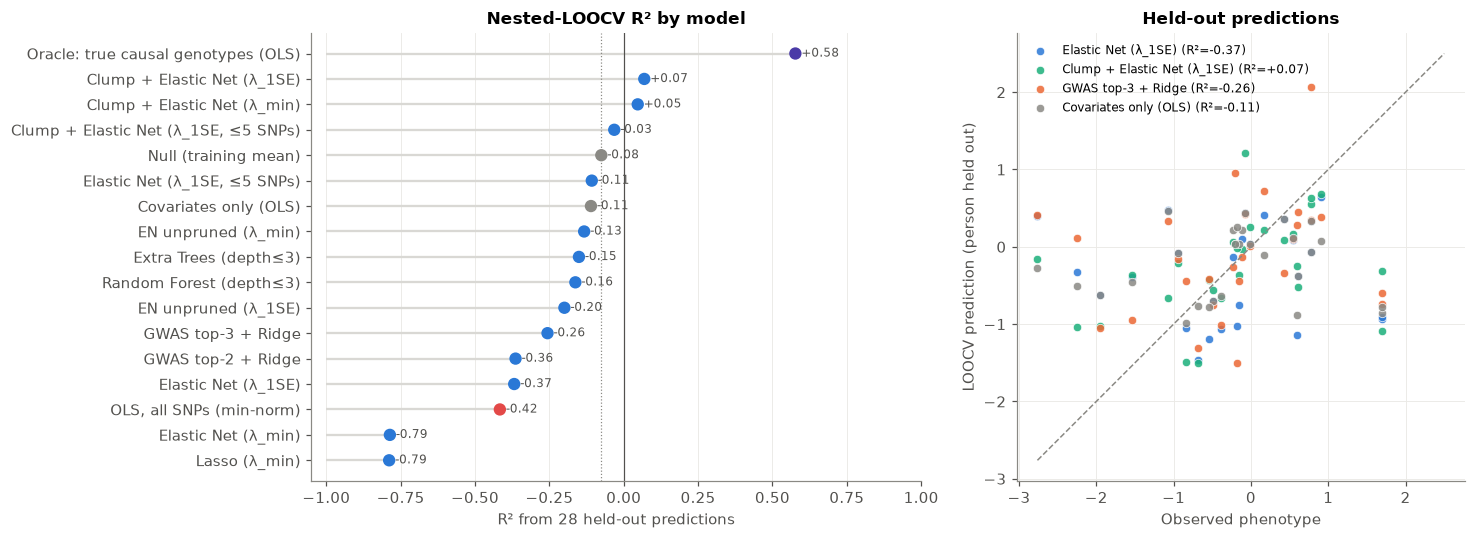

In [32]:
order = summary.sort_values("R²_LOO").index
fig, axes = plt.subplots(1, 2, figsize=(14, 5), gridspec_kw={"width_ratios": [1.1, 1]})
ax = axes[0]
yy = np.arange(len(order))
vals = summary.loc[order, "R²_LOO"].clip(lower=-1.0)
colors = [PAL["gray"] if ("Null" in m or "Covariates" in m) else PAL["violet"] if "Oracle" in m
          else PAL["red"] if "OLS, all" in m else PAL["blue"] for m in order]
ax.hlines(yy, -1.0, vals, color=PAL["lightgray"], lw=1.5)
ax.scatter(vals, yy, color=colors, s=50, zorder=3)
for yi, m in zip(yy, order):
    v = summary.loc[m, "R²_LOO"]
    ax.text(max(v, -1.0) + 0.02, yi, f"{v:+.2f}" + (" (clipped)" if v < -1 else ""), va="center", fontsize=8, color=PAL["ink2"])
ax.axvline(0, color=PAL["ink2"], lw=0.8)
ax.axvline(1 - (n / (n - 1)) ** 2, color=PAL["gray"], lw=0.8, ls=":")
ax.set(yticks=yy, yticklabels=order, xlabel="R² from 28 held-out predictions", title="Nested-LOOCV R² by model", xlim=(-1.05, 1))
ax.grid(axis="y", visible=False)

ax = axes[1]
for name, col in (("Elastic Net (λ_1SE)", PAL["blue"]), ("Clump + Elastic Net (λ_1SE)", PAL["aqua"]),
                  ("GWAS top-3 + Ridge", PAL["orange"]), ("Covariates only (OLS)", PAL["gray"])):
    ax.scatter(all_res[name].y, all_res[name].pred, s=30, color=col, alpha=0.85, edgecolors="white", linewidths=0.5,
               label=f"{name} (R²={all_res[name].r2:+.2f})")
lim = [min(y.min(), -2.5), max(y.max(), 2.5)]
ax.plot(lim, lim, color=PAL["gray"], lw=1, ls="--")
ax.set(xlabel="Observed phenotype", ylabel="LOOCV prediction (person held out)", title="Held-out predictions", aspect="equal")
ax.legend(fontsize=8, loc="upper left")
plt.tight_layout(); plt.show()

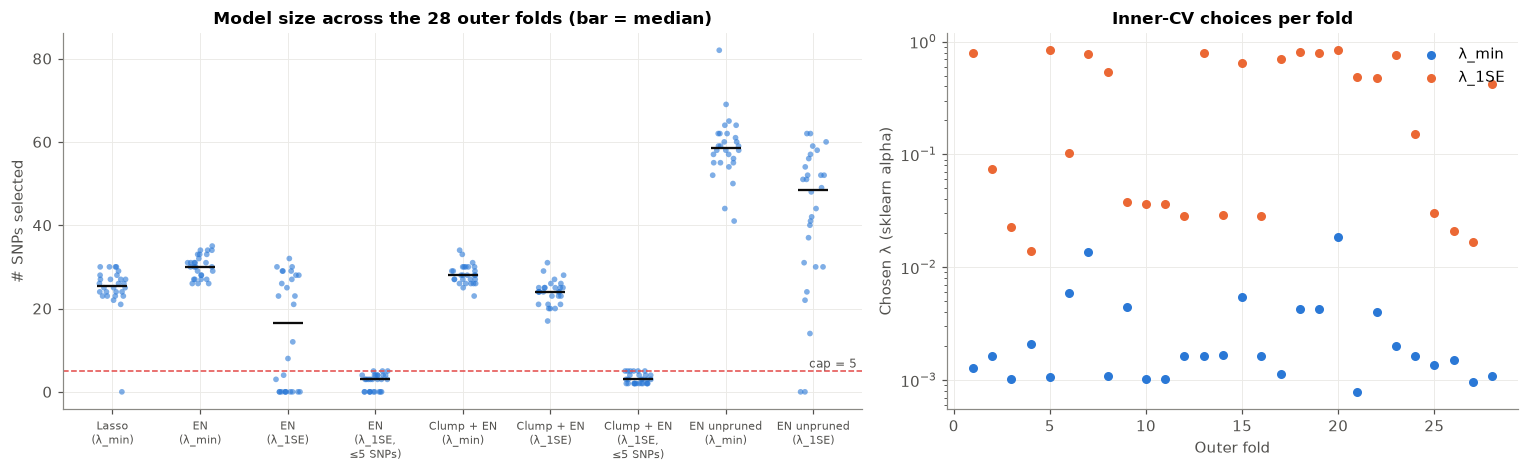

03:55:12 | INFO  | Chosen l1_ratio (ρ) across outer folds: l1_ratio | 0.7    25 | 0.8     1 | 0.9     2


In [33]:
# How many SNPs does each model use per fold, and which (λ, ρ) did the inner CV choose?
show = ["Lasso (λ_min)", "Elastic Net (λ_min)", "Elastic Net (λ_1SE)", f"Elastic Net (λ_1SE, {CAP})",
        "Clump + Elastic Net (λ_min)", "Clump + Elastic Net (λ_1SE)", f"Clump + Elastic Net (λ_1SE, {CAP})",
        "EN unpruned (λ_min)", "EN unpruned (λ_1SE)"]
fig, axes = plt.subplots(1, 2, figsize=(14, 4.4), gridspec_kw={"width_ratios": [1.4, 1]})
ax = axes[0]
for k, name in enumerate(show):
    cnt = [len(s) for s in all_res[name].selected]
    ax.scatter(np.full(len(cnt), k) + np.random.default_rng(k).uniform(-0.15, 0.15, len(cnt)), cnt, s=14,
               color=PAL["blue"], alpha=0.6, edgecolors="none")
    ax.scatter([k], [np.median(cnt)], marker="_", s=400, color=PAL["ink"])
ax.axhline(CFG["max_snps"], color=PAL["red"], ls="--", lw=1)
ax.text(len(show) - 0.5, CFG["max_snps"] + 0.8, f"cap = {CFG['max_snps']}", ha="right", fontsize=8, color=PAL["ink2"])
ax.set(xticks=range(len(show)), ylabel="# SNPs selected", title="Model size across the 28 outer folds (bar = median)")
ax.set_xticklabels([s.replace("Elastic Net", "EN").replace(" (", "\n(").replace(", ≤", ",\n≤") for s in show], fontsize=7.5)
ax = axes[1]
hp = pd.DataFrame(all_res["Elastic Net (λ_min)"].hyper)[["alpha", "l1_ratio"]]
hp1 = pd.DataFrame(all_res["Elastic Net (λ_1SE)"].hyper)[["alpha"]]
ax.scatter(np.arange(1, n + 1), hp["alpha"], s=24, color=PAL["blue"], label="λ_min")
ax.scatter(np.arange(1, n + 1), hp1["alpha"], s=24, color=PAL["orange"], label="λ_1SE")
ax.set(yscale="log", xlabel="Outer fold", ylabel="Chosen λ (sklearn alpha)", title="Inner-CV choices per fold"); ax.legend()
plt.tight_layout(); plt.show()
logger.info("Chosen l1_ratio (ρ) across outer folds: " + hp["l1_ratio"].value_counts().sort_index().to_string().replace("\n", " | "))

### 14.1 Looking inside one inner CV: why does λ_1SE still keep many SNPs?

To see how λ is chosen, we reproduce the inner cross-validation of outer fold 1 (27 training people, genome-wide pruned SNPs, ρ = 0.9) and plot the CV error curve together with the model size along the λ path.

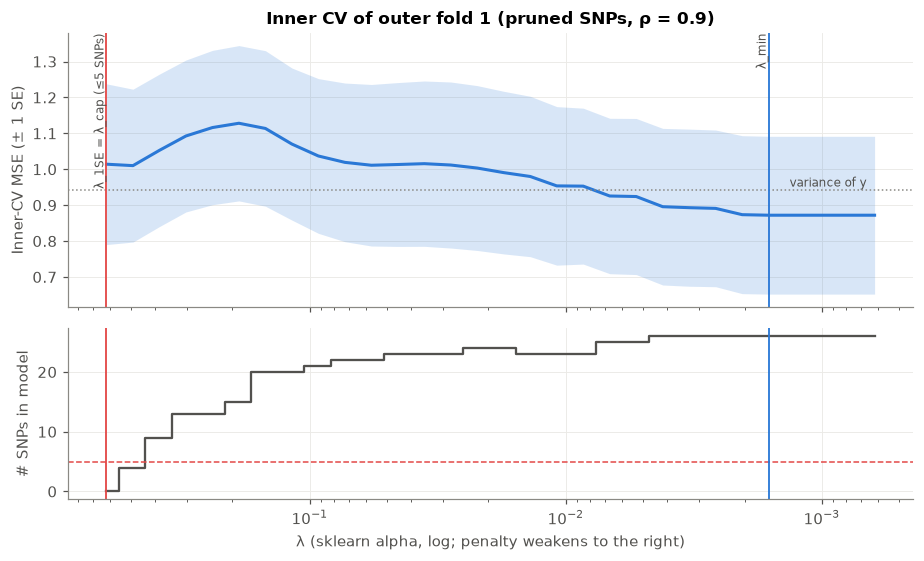

03:55:12 | INFO  | Fold-1 inner CV: λ_min = 0.00161 → 26 SNPs; λ_1SE = 0.6208 → 0 SNPs; λ_cap = 0.6208 → 0 SNPs. MSE at λ_min is 8% below the no-SNP model.


In [34]:
tr = np.arange(n) != 0                                               # outer fold 1: person 0 held out
Xtr_s, _, ytr_r, _ = prepare_split(X[tr], y[tr], C[tr], X[~tr], C[~tr])
with warnings.catch_warnings():
    warnings.simplefilter("ignore", ConvergenceWarning)
    cvd = ElasticNetCV(l1_ratio=0.9, alphas=CFG["n_alphas"], max_iter=20_000,
                       cv=RepeatedKFold(n_splits=CFG["inner_splits"], n_repeats=CFG["inner_repeats"], random_state=CFG["seed"])
                       ).fit(Xtr_s, ytr_r)
    _, coefs_d, _ = enet_path(Xtr_s, ytr_r, l1_ratio=0.9, alphas=cvd.alphas_, max_iter=20_000)
mean_d = cvd.mse_path_.mean(1)
se_d = cvd.mse_path_.std(1, ddof=1) / np.sqrt(cvd.mse_path_.shape[1])
i_min = int(mean_d.argmin())
a_min, a_1se = cvd.alphas_[i_min], cvd.alphas_[mean_d <= mean_d[i_min] + se_d[i_min]].max()
nnz_d = (coefs_d != 0).sum(0)
a_cap = cvd.alphas_[np.flatnonzero((nnz_d <= CFG["max_snps"]) & (cvd.alphas_ >= a_1se)).max()]

fig, axes = plt.subplots(2, 1, figsize=(8.5, 5.2), sharex=True, gridspec_kw={"height_ratios": [1.6, 1]})
ax = axes[0]
ax.fill_between(cvd.alphas_, mean_d - se_d, mean_d + se_d, color=PAL["blue"], alpha=0.18, lw=0)
ax.plot(cvd.alphas_, mean_d, color=PAL["blue"], lw=2)
ax.axhline(np.var(ytr_r), color=PAL["gray"], ls=":", lw=1)
ax.text(cvd.alphas_[-1], np.var(ytr_r), "variance of y  ", va="bottom", ha="right", fontsize=8, color=PAL["ink2"])
ax.set(ylabel="Inner-CV MSE (± 1 SE)", title="Inner CV of outer fold 1 (pruned SNPs, ρ = 0.9)")
ax = axes[1]
ax.step(cvd.alphas_, nnz_d, where="mid", color=PAL["ink2"], lw=1.5)
ax.axhline(CFG["max_snps"], color=PAL["red"], ls="--", lw=1)
ax.set(xscale="log", ylabel="# SNPs in model", xlabel="λ (sklearn alpha, log; penalty weakens to the right)")
ax.invert_xaxis()
marks = {}
for a_, lab in ((a_min, "λ_min"), (a_1se, "λ_1SE"), (a_cap, f"λ_cap ({CAP})")):
    marks.setdefault(a_, []).append(lab)                              # merge labels of coinciding λ values
for a_, labs in marks.items():
    for ax in axes:
        ax.axvline(a_, color=PAL["red"] if a_ == a_cap else PAL["blue"], lw=1.2)
    axes[0].text(a_, axes[0].get_ylim()[1], " " + " = ".join(labs), rotation=90, va="top", ha="right", fontsize=8,
                 color=PAL["ink2"])
plt.tight_layout(); plt.show()
logger.info(f"Fold-1 inner CV: λ_min = {a_min:.4g} → {nnz_d[cvd.alphas_ == a_min][0]} SNPs; λ_1SE = {a_1se:.4g} → "
            f"{nnz_d[cvd.alphas_ == a_1se][0]} SNPs; λ_cap = {a_cap:.4g} → {nnz_d[cvd.alphas_ == a_cap][0]} SNPs. "
            f"MSE at λ_min is {100 * (1 - mean_d[i_min] / np.var(ytr_r)):.0f}% below the no-SNP model.")

**What to look for.** The curve is almost flat. Even the best λ lowers the inner-CV error only a few percent below the no-SNP model, and that shallow dip sits at a *tiny* λ where 20–30 SNPs enter. The 1-SE band is wide enough that, depending on the fold, λ_1SE lands either on the **empty model** (as here) or near λ_min with dozens of SNPs. That is why the model-size plot above shows λ_1SE jumping between 0 and ~30 SNPs across folds. At n = 27 **the data cannot tell you the right model size**, so you must bring that prior. The hard cap ("≤ 5 SNPs", fixed before seeing the data) is one honest way to do it.

### 14.2 How to read the model comparison
* **OLS on all SNPs** is disastrous: a perfect training fit (§10.7) and a strongly negative held-out R².
* The **null model** sits at exactly −0.075, as derived in §12.3, and its Pearson r is −1.
* **Covariates only** is the real baseline, and it is itself slightly negative: three covariates cost almost as much as they explain at n = 28. The question for every SNP model is the **ΔR²** column.
* **Genome-wide pruned Lasso/EN** do *worse* than covariates: λ_min selects ~25–30 SNPs per fold and badly overfits, λ_1SE helps, and the ≤5-SNP cap roughly ties the baseline. Two reasons: pruning left causal A and B only weakly tagged (§8), and the chance-correlation wall (§15).
* **Clump + Elastic Net** is the only genome-wide strategy with a positive LOOCV R². In-fold clumping keeps the best-tagging SNP of every block (§8.1).
* **GWAS top-k + Ridge** suffers from the *winner's curse*: at n = 27 the top-ranked SNPs are mostly noise, and Ridge (with a small penalty chosen by LOO) trusts them.
* **Shallow tree ensembles** use ~300 SNPs (see the #SNPs column). Random feature sampling limits damage from any single false positive, but with n = 27 they cannot estimate additive dosage effects efficiently.
* **Oracle** is the ceiling: even knowing the exact causal genotypes, 28 people give a noisy estimate of the ~50% variance they explain.
* None of these numbers has an error bar yet. That comes in Section 16. First, the most effective fix.

## 15. The most effective lever: shrink the search space with biological priors

**Why genome-wide selection struggles at n = 28.** With $p$ independent null SNPs, the *largest chance correlation* with the phenotype grows like $\sqrt{2\ln(2p)/n}$. For a SNP to be picked by any selection method (Lasso, EN, GWAS ranking or clumping), its true correlation must beat that maximum. At n = 27 this bar is very high. The median of the maximum is exact under the null:

$$ P\big(\max_j |r_j| < t\big) = F_{|r|}(t)^{p} \;\Rightarrow\; t_{\text{median}} \text{ solves } F_{|r|}(t) = 0.5^{1/p}, $$

where $F_{|r|}$ follows from the t-distribution of $r\sqrt{\text{df}/(1-r^2)}$.

03:55:12 | INFO  | Largest chance correlation in a training fold (df = 22):
 p (independent SNPs)  median max |r| under H0  equivalent R²
                    5                    0.318          0.101
                   10                     0.38          0.144
                   30                    0.463          0.214
                  100                    0.536          0.288
                  300                    0.592           0.35
                 1000                    0.643          0.414
                10000                    0.721          0.521
               100000                     0.78          0.609
              1000000                    0.825          0.681


03:55:12 | INFO  | True |r| of the causal variants ≈ A: 0.55, B: 0.39, C: 0.28


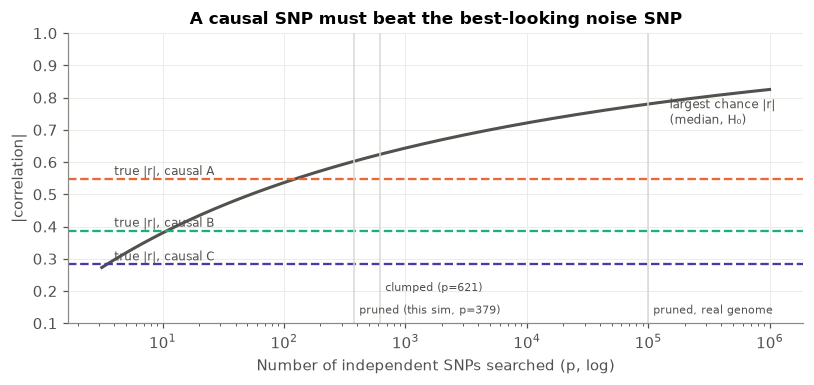

In [35]:
def median_max_null_r(p, df):
    """Median of the largest |Pearson r| among p independent null SNPs (df = n − 2 − #covariates)."""
    pv = 1 - 0.5 ** (1 / p)                      # per-SNP two-sided p-value of the median maximum
    t = stats.t.isf(pv / 2, df)
    return t / np.sqrt(t ** 2 + df)


df_fold = (n - 1) - 2 - len(COV_NAMES)           # a training fold: 27 people, minus covariates
p_grid = np.array([5, 10, 30, 100, 300, 1_000, 10_000, 100_000, 1_000_000])
maxr = pd.DataFrame({"p (independent SNPs)": p_grid, "median max |r| under H0": median_max_null_r(p_grid, df_fold)})
maxr["equivalent R²"] = maxr["median max |r| under H0"] ** 2
logger.info(f"Largest chance correlation in a training fold (df = {df_fold}):\n" + maxr.round(3).to_string(index=False))
logger.info("True |r| of the causal variants ≈ " + ", ".join(f"{l}: {np.sqrt(h):.2f}" for l, h in zip("ABC", CFG["major_h2"])))

fig, ax = plt.subplots(figsize=(7.5, 3.6))
pp = np.logspace(0.5, 6, 200)
ax.plot(pp, median_max_null_r(pp, df_fold), color=PAL["ink2"], lw=2)
ax.text(1.5e5, median_max_null_r(1.5e5, df_fold) - 0.07, "largest chance |r|\n(median, H₀)", fontsize=8, color=PAL["ink2"])
for h, lab, col in zip(CFG["major_h2"], "ABC", CAUSAL_COLORS):
    ax.axhline(np.sqrt(h), color=col, lw=1.5, ls="--")
    ax.text(4, np.sqrt(h) + 0.012, f"true |r|, causal {lab}", fontsize=8, color=PAL["ink2"])
for p_, lab, yl in ((p_feat, f"pruned (this sim, p={p_feat})", 0.13), (len(idx_snps), f"clumped (p={len(idx_snps)})", 0.2),
                    (1e5, "pruned, real genome", 0.13)):
    ax.axvline(p_, color=PAL["lightgray"], lw=1)
    ax.text(p_ * 1.1, yl, lab, fontsize=7, ha="left", color=PAL["ink2"])
ax.set(xscale="log", ylim=(0.1, 1), xlabel="Number of independent SNPs searched (p, log)", ylabel="|correlation|",
       title="A causal SNP must beat the best-looking noise SNP")
plt.tight_layout(); plt.show()

**What to look for.** Searching ~400–600 independent SNPs, the best *noise* SNP typically reaches |r| ≈ 0.6. That is larger than the true correlation of even our 30%-variance variant (|r| ≈ 0.55). On a real genome (~10⁵ independent SNPs) the bar is |r| ≈ 0.8. With a **handful of candidate regions** (a few dozen independent SNPs) it drops to ≈ 0.45, and strong causal variants become competitive.

This is why small pharmacogenomic studies test pre-specified genes, e.g. *VKORC1* and *CYP2C9* for warfarin, rather than the whole genome. **Reducing p with prior knowledge helps far more than any choice of algorithm.**

### 15.1 A candidate-region analysis (with decoys)

Suppose the literature suggests **8 candidate genes** (±100 kb windows). Three of them contain our causal variants, with the window centre offset by up to 50 kb so the causal SNP is not conveniently in the middle. The other five are **decoys** that contain no major causal variant: priors are rarely perfect. The gene labels are shuffled so the names do not reveal the truth. The candidate list must be fixed **before** looking at the phenotype, e.g. from PharmGKB, OMIM or published GWAS. Choosing regions after seeing the data would be leakage again.

In [36]:
rng_cand = np.random.default_rng(CFG["seed"] + 8)
half_w, L = CFG["candidate_kb"] * 1000, CFG["segment_length"]
reg = []
for k, j in enumerate(causal):
    off = rng_cand.integers(-CFG["candidate_offset_kb"] * 1000, CFG["candidate_offset_kb"] * 1000 + 1)
    reg.append({"chr": int(snp_chr[j]), "centre": int(np.clip(snp_pos[j] + off, half_w, L - half_w)),
                "truth (hidden)": f"contains causal {'ABC'[k]}"})
decoy_chr = rng_cand.choice(np.setdiff1d(np.arange(1, CFG["n_segments"] + 1), snp_chr[causal]),
                            CFG["n_decoy_regions"], replace=False)
for c in decoy_chr:
    reg.append({"chr": int(c), "centre": int(rng_cand.integers(half_w, L - half_w)), "truth (hidden)": "decoy"})
regions = pd.DataFrame(reg).sample(frac=1, random_state=CFG["seed"]).reset_index(drop=True)
regions.insert(0, "gene", [f"GENE{i + 1}" for i in range(len(regions))])
regions["start"], regions["end"] = regions["centre"] - half_w, regions["centre"] + half_w

snp_region = np.full(m_snps, -1)
for r_i, row in regions.iterrows():
    snp_region[(snp_chr == row["chr"]) & (snp_pos >= row["start"]) & (snp_pos <= row["end"])] = r_i
cand_idx = np.flatnonzero(qc_keep & (snp_region >= 0))            # QC'd SNPs in candidate regions
cand_pruned_idx = np.flatnonzero(pruned_ref & (snp_region >= 0))  # … and their LD-pruned subset
regions["QC SNPs"] = [int(np.sum(snp_region[cand_idx] == r)) for r in range(len(regions))]
regions["pruned SNPs"] = [int(np.sum(snp_region[cand_pruned_idx] == r)) for r in range(len(regions))]
logger.info("Candidate regions:\n" + regions.to_string(index=False))

X_cand = D_coh[:, cand_idx].astype(np.float64)
X_candp = D_coh[:, cand_pruned_idx].astype(np.float64)
nbrs_cand = build_ld_neighbours(G_ref, snp_chr, snp_pos, cand_idx, CFG["clump_r2"], CFG["clump_kb"])
logger.info(f"Candidate feature sets: {len(cand_idx)} QC'd SNPs (clumped in-fold) | {len(cand_pruned_idx)} pruned SNPs")

families_cand_qc = [clump_enet_family(nbrs_cand, prefix="Candidate: clump + EN")]
families_cand_pr = [enet_family(CFG["l1_ratios"], prefix="Candidate: pruned + EN", variants=("min", "1se")),
                    gwas_ridge_family(prefix="Candidate: GWAS")]
with log_step("Nested LOOCV within candidate regions"):
    res_cand = nested_loocv(X_cand, y, C, families_cand_qc, seed=CFG["seed"], log_model=f"Candidate: clump + EN (λ_1SE, {CAP})",
                            feature_names=snp_id[cand_idx], sample_names=sample_names)
    res_candp = nested_loocv(X_candp, y, C, families_cand_pr, seed=CFG["seed"], quiet=True)
all_res.update({k: v for k, v in {**res_cand, **res_candp}.items() if k.startswith("Candidate")})

summary = summarize(all_res)
summary["ΔR² vs covariates"] = summary["R²_LOO"] - summary.loc["Covariates only (OLS)", "R²_LOO"]
summary.to_csv(os.path.join(OUT_DIR, "loocv_model_comparison.csv"))
cmp_models = ["Covariates only (OLS)", "Elastic Net (λ_1SE)", f"Elastic Net (λ_1SE, {CAP})", "Clump + Elastic Net (λ_1SE)",
              f"Clump + Elastic Net (λ_1SE, {CAP})", "GWAS top-3 + Ridge",
              "Candidate: pruned + EN (λ_1SE)", "Candidate: clump + EN (λ_min)", "Candidate: clump + EN (λ_1SE)",
              f"Candidate: clump + EN (λ_1SE, {CAP})", "Candidate: GWAS top-2 + Ridge", "Candidate: GWAS top-3 + Ridge",
              "Oracle: true causal genotypes (OLS)"]
logger.info("Genome-wide vs candidate-region search (nested LOOCV):\n" + summary.loc[cmp_models].round(3).to_string())
summary.loc[cmp_models].round(3)

03:55:12 | INFO  | Candidate regions:
 gene  chr  centre    truth (hidden)  start    end  QC SNPs  pruned SNPs
GENE1   17  892102             decoy 792102 992102       88            4
GENE2    1  723411             decoy 623411 823411      134            6
GENE3    6  507122             decoy 407122 607122       94            3
GENE4   13  106709             decoy   6709 206709      146            6
GENE5   14  486458 contains causal A 386458 586458      136            3
GENE6   11  578678 contains causal C 478678 678678      114            3
GENE7   12  396445             decoy 296445 496445       50            3
GENE8   15  509525 contains causal B 409525 609525      144            5


03:55:12 | INFO  | Candidate feature sets: 906 QC'd SNPs (clumped in-fold) | 33 pruned SNPs


03:55:12 | INFO  | ▶ Nested LOOCV within candidate regions


03:55:13 | INFO  |   fold 01/28 | held-out IND0400(EUR) | alpha=0.386 l1_ratio=0.7 n_index_snps=58 | 5 SNPs ['chr14:490248', 'chr15:554011', 'chr11:608866', 'chr15:474957', 'chr1:794315'] | y = -0.50, ŷ = -0.88


03:55:13 | INFO  |   fold 02/28 | held-out IND0482(EUR) | alpha=0.338 l1_ratio=0.8 n_index_snps=58 | 4 SNPs ['chr14:490248', 'chr15:554011', 'chr11:608866', 'chr15:419557'] | y = -0.23, ŷ = -0.01


...

03:55:15 | INFO  |   fold 27/28 | held-out IND0986(EAS) | alpha=0.361 l1_ratio=0.7 n_index_snps=58 | 4 SNPs ['chr14:490248', 'chr15:554011', 'chr11:608866', 'chr15:419557'] | y = -2.76, ŷ = -0.78


03:55:15 | INFO  |   fold 28/28 | held-out IND0989(EAS) | alpha=0.273 l1_ratio=0.8 n_index_snps=56 | 4 SNPs ['chr14:490248', 'chr15:554011', 'chr11:608866', 'chr15:419557'] | y = -0.39, ŷ = -0.40


03:55:18 | INFO  | ✔ Nested LOOCV within candidate regions (done in 6.0 s)


03:55:18 | INFO  | Genome-wide vs candidate-region search (nested LOOCV):
                                        R²_LOO  RMSE  Pearson r  median #SNPs used range #SNPs  ΔR² vs covariates
model                                                                                                            
Covariates only (OLS)                    -0.11 1.101      0.087                  0         0–0                  0
Elastic Net (λ_1SE)                     -0.368 1.222      -0.02               16.5        0–32             -0.258
Elastic Net (λ_1SE, ≤5 SNPs)            -0.107   1.1       0.08                  3         0–5              0.003
Clump + Elastic Net (λ_1SE)              0.069 1.008      0.358                 24       17–31              0.179
Clump + Elastic Net (λ_1SE, ≤5 SNPs)    -0.032 1.061        0.2                  3         2–5              0.078
GWAS top-3 + Ridge                      -0.256 1.171      0.184                  3         3–3             -0.146
Candidate: pru

,R²_LOO,RMSE,Pearson r,median #SNPs used,range #SNPs,ΔR² vs covariates
model,,,,,,
Covariates only (OLS),-0.11,1.101,0.087,0,0–0,0
Elastic Net (λ_1SE),-0.368,1.222,-0.02,16.5,0–32,-0.258
"Elastic Net (λ_1SE, ≤5 SNPs)",-0.107,1.1,0.08,3,0–5,0.003
Clump + Elastic Net (λ_1SE),0.069,1.008,0.358,24,17–31,0.179
"Clump + Elastic Net (λ_1SE, ≤5 SNPs)",-0.032,1.061,0.2,3,2–5,0.078
GWAS top-3 + Ridge,-0.256,1.171,0.184,3,3–3,-0.146
Candidate: pruned + EN (λ_1SE),0.104,0.989,0.466,21,3–25,0.214
Candidate: clump + EN (λ_min),-0.492,1.276,0.169,24,15–28,-0.382
Candidate: clump + EN (λ_1SE),-0.259,1.172,0.216,20.5,6–26,-0.149


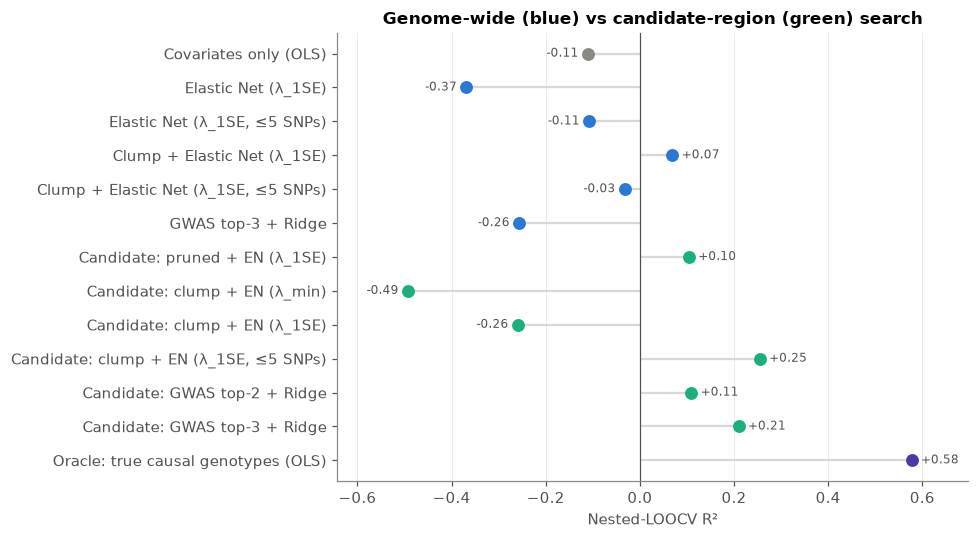

In [37]:
fig, ax = plt.subplots(figsize=(9, 5))
yy = np.arange(len(cmp_models))[::-1]
for yi, m in zip(yy, cmp_models):
    v = summary.loc[m, "R²_LOO"]
    col = PAL["aqua"] if m.startswith("Candidate") else PAL["violet"] if "Oracle" in m else PAL["gray"] if "Covariates" in m else PAL["blue"]
    ax.hlines(yi, min(v, 0), max(v, 0), color=PAL["lightgray"], lw=1.5)
    ax.scatter([v], [yi], color=col, s=55, zorder=3)
    ax.text(v + (0.02 if v >= 0 else -0.02), yi, f"{v:+.2f}", va="center", ha="left" if v >= 0 else "right", fontsize=8, color=PAL["ink2"])
ax.axvline(0, color=PAL["ink2"], lw=0.8)
vals_ = summary.loc[cmp_models, "R²_LOO"]
ax.set(xlim=(min(vals_.min(), 0) - 0.15, max(vals_.max(), 0) + 0.12))
ax.set(yticks=yy, yticklabels=cmp_models, xlabel="Nested-LOOCV R²", title="Genome-wide (blue) vs candidate-region (green) search")
ax.grid(axis="y", visible=False)
plt.tight_layout(); plt.show()

**What to look for.**
* Restricting the search to 8 pre-specified genes turns failure into signal. **Candidate: clump + EN (λ_1SE, ≤5 SNPs)** and **Candidate: GWAS top-3 + Ridge** reach clearly positive LOOCV R² and ΔR², while every genome-wide model stays near or below the covariate baseline.
* **Both priors matter.** Inside the candidate regions, the *uncapped* EN (λ_min, λ_1SE) still overfits with ~20 SNPs, so a prior on *where* to look and a prior on *how many* SNPs to allow work together.
* The candidate analysis is honest only because the regions were chosen *without* looking at the phenotype, and it includes decoys. Sections 16–18 check it three independent ways: against the truth, with permutations, and with stability selection.

## 16. How much can we trust an R² estimated from 28 people?

Three complementary views:

1. **Bootstrap CI** of the LOOCV R², resampling the 28 (observed, predicted) pairs. This is cheap, but it ignores the fact that the models themselves would change with different training data, so it is **too narrow**.
2. **External truth.** We fit the final model on all 28 and score it on the 472 hidden validation people. A real study cannot do this; it is the benefit of simulation.
3. **Replicate cohorts.** We repeat the *entire* pipeline (QC → pruning/clumping → covariates → nested LOOCV) on **independent** cohorts of 28 people from the same population. This shows the true sampling variability of the LOOCV estimate, i.e. how different your paper's headline number would have been with different recruits.

In [38]:
def bootstrap_r2_ci(y_, pred_, n_boot, seed=0):
    rng_ = np.random.default_rng(seed)
    idx = rng_.integers(0, len(y_), (n_boot, len(y_)))
    yy_, pp_ = y_[idx], pred_[idx]
    r2s = 1 - ((yy_ - pp_) ** 2).sum(1) / ((yy_ - yy_.mean(1, keepdims=True)) ** 2).sum(1)
    return np.percentile(r2s, [2.5, 97.5])

key_models = ["Covariates only (OLS)", "Lasso (λ_min)", "Elastic Net (λ_min)", "Elastic Net (λ_1SE)",
              f"Elastic Net (λ_1SE, {CAP})", "GWAS top-2 + Ridge", "GWAS top-3 + Ridge",
              "Extra Trees (depth≤3)", "Random Forest (depth≤3)", "EN unpruned (λ_1SE)",
              "Clump + Elastic Net (λ_min)", "Clump + Elastic Net (λ_1SE)", f"Clump + Elastic Net (λ_1SE, {CAP})",
              "Candidate: pruned + EN (λ_1SE)", "Candidate: clump + EN (λ_1SE)", f"Candidate: clump + EN (λ_1SE, {CAP})",
              "Candidate: GWAS top-3 + Ridge"]

# External validation: train on all 28 with EXACTLY the same families, predict 472 hidden people
C_val = make_covariates(sex[val], age[val], project_pcs(D_pool[np.ix_(val, feat_idx)], pca_ref))
split_sets = [  # (feature indices, families)
    (feat_idx, families_main), (qc_idx, families_qc), (cand_idx, families_cand_qc), (cand_pruned_idx, families_cand_pr)]
final_fit, final_cols = {}, {}
with log_step("Fitting final models on all 28 and scoring the 472 hidden validation people"):
    for cols, fams in split_sets:
        fit_ = fit_predict_split(D_coh[:, cols].astype(np.float64), y, C,
                                 D_pool[np.ix_(val, cols)].astype(np.float64), C_val, fams, seed=CFG["seed"])
        for k_, v_ in fit_.items():
            if k_ not in final_fit or k_ in ("Null (training mean)", "Covariates only (OLS)"):
                final_fit[k_], final_cols[k_] = v_, cols      # remember which SNP set the indices refer to
y_val = y_pool[val]
rows = []
for m in key_models:
    lo, hi = bootstrap_r2_ci(y, all_res[m].pred, CFG["n_bootstrap"], seed=1)
    pv = final_fit[m][0]
    rows.append({"model": m, "LOOCV R²": all_res[m].r2, "bootstrap 95% CI": f"[{lo:+.2f}, {hi:+.2f}]",
                 "TRUE R² (472 new people)": 1 - np.sum((y_val - pv) ** 2) / np.sum((y_val - y_val.mean()) ** 2),
                 "#SNPs in final model": len(final_fit[m][1])})
ext_tbl = pd.DataFrame(rows).set_index("model")
logger.info("LOOCV estimate vs. truth:\n" + ext_tbl.round(3).to_string())
ext_tbl.round(3)

03:55:19 | INFO  | ▶ Fitting final models on all 28 and scoring the 472 hidden validation people


03:55:27 | INFO  | ✔ Fitting final models on all 28 and scoring the 472 hidden validation people (done in 8.1 s)


03:55:27 | INFO  | LOOCV estimate vs. truth:
                                        LOOCV R² bootstrap 95% CI  TRUE R² (472 new people)  #SNPs in final model
model                                                                                                            
Covariates only (OLS)                      -0.11   [-0.64, +0.16]                    -0.125                     0
Lasso (λ_min)                             -0.789   [-1.69, -0.34]                    -0.089                    24
Elastic Net (λ_min)                       -0.786   [-1.68, -0.34]                    -0.004                    33
Elastic Net (λ_1SE)                       -0.368   [-0.94, -0.01]                     0.027                    29
Elastic Net (λ_1SE, ≤5 SNPs)              -0.107   [-0.62, +0.16]                    -0.059                     3
GWAS top-2 + Ridge                        -0.364   [-0.86, -0.06]                    -0.015                     2
GWAS top-3 + Ridge                        -

,LOOCV R²,bootstrap 95% CI,TRUE R² (472 new people),#SNPs in final model
model,,,,
Covariates only (OLS),-0.11,"[-0.64, +0.16]",-0.125,0
Lasso (λ_min),-0.789,"[-1.69, -0.34]",-0.089,24
Elastic Net (λ_min),-0.786,"[-1.68, -0.34]",-0.004,33
Elastic Net (λ_1SE),-0.368,"[-0.94, -0.01]",0.027,29
"Elastic Net (λ_1SE, ≤5 SNPs)",-0.107,"[-0.62, +0.16]",-0.059,3
GWAS top-2 + Ridge,-0.364,"[-0.86, -0.06]",-0.015,2
GWAS top-3 + Ridge,-0.256,"[-0.72, +0.11]",-0.026,3
Extra Trees (depth≤3),-0.151,"[-0.73, +0.14]",-0.087,328
Random Forest (depth≤3),-0.163,"[-0.72, +0.13]",-0.102,300


In [39]:
REP_MODELS = ("Covariates only (OLS)", "Elastic Net (λ_1SE)", f"Elastic Net (λ_1SE, {CAP})", "GWAS top-3 + Ridge",
              f"Clump + Elastic Net (λ_1SE, {CAP})", f"Candidate: clump + EN (λ_1SE, {CAP})")


def analyse_replicate(r, D_pool, G_ref, y_pool, sex, age):
    """Run the full pipeline on replicate cohort r and score its final models on everyone else in the pool.

    Large arrays are passed as arguments so that joblib memory-maps them once instead of
    pickling them for every worker task.
    """
    idx = replicate_cohorts[r]
    rest = np.setdiff1d(np.arange(len(y_pool)), idx)
    D_r, y_r = D_pool[idx], y_pool[idx]
    keep_r, st_r, _ = qc_variants(D_r, CFG["maf_min"], CFG["rsq_min"], CFG["hwe_p_min"], verbose=False)
    qc_r = np.flatnonzero(keep_r)
    feat_r = np.flatnonzero(ld_prune(G_ref, snp_chr, snp_pos, st_r["maf"].to_numpy(), qc_r,
                                     CFG["prune_window"], CFG["prune_step"], CFG["prune_r2"]))
    cand_r = np.flatnonzero(keep_r & (snp_region >= 0))
    pca_r = fit_reference_pca(G_ref[:, feat_r].astype(np.float32), n_pc=CFG["n_pcs"])
    C_r = make_covariates(sex[idx], age[idx], project_pcs(D_r[:, feat_r], pca_r))
    C_rest = make_covariates(sex[rest], age[rest], project_pcs(D_pool[np.ix_(rest, feat_r)], pca_r))
    nb = lambda cols: build_ld_neighbours(G_ref, snp_chr, snp_pos, cols, CFG["clump_r2"], CFG["clump_kb"])
    plan = [(feat_r, [enet_family(CFG["l1_ratios"], variants=("1se", "cap")), gwas_ridge_family((3,))]),
            (qc_r, [clump_enet_family(nb(qc_r), variants=("cap",))]),
            (cand_r, [clump_enet_family(nb(cand_r), prefix="Candidate: clump + EN", variants=("cap",))])]
    cvr, fin = {}, {}
    for cols, fams in plan:
        Xr = D_r[:, cols].astype(np.float64)
        cvr.update(nested_loocv(Xr, y_r, C_r, fams, seed=CFG["seed"] + 100 * r, quiet=True))
        fin.update(fit_predict_split(Xr, y_r, C_r, D_pool[np.ix_(rest, cols)].astype(np.float64), C_rest, fams, seed=CFG["seed"]))
    yr = y_pool[rest]
    out = {"replicate": r}
    for m in REP_MODELS:
        out[f"{m} | LOOCV"] = cvr[m].r2
        out[f"{m} | true"] = 1 - np.sum((yr - fin[m][0]) ** 2) / np.sum((yr - yr.mean()) ** 2)
    return out


n_rep = min(CFG["n_replicate_cohorts"], len(replicate_cohorts))
with log_step(f"Re-running the ENTIRE pipeline on {n_rep} independent cohorts of n = 28 (parallel)"):
    rep = pd.DataFrame(Parallel(n_jobs=N_JOBS)(delayed(analyse_replicate)(r, D_pool, G_ref, y_pool, sex, age)
                                               for r in range(n_rep)))
rep.to_csv(os.path.join(OUT_DIR, "replicate_cohorts.csv"), index=False)
for m in REP_MODELS:
    lo, tr_ = rep[f"{m} | LOOCV"], rep[f"{m} | true"]
    logger.info(f"{m:<32} LOOCV R²: mean {lo.mean():+.3f}, SD {lo.std():.3f}, range [{lo.min():+.2f}, {lo.max():+.2f}] | "
                f"true R²: mean {tr_.mean():+.3f} (SD {tr_.std():.3f})")

03:55:27 | INFO  | ▶ Re-running the ENTIRE pipeline on 12 independent cohorts of n = 28 (parallel)


03:56:58 | INFO  | ✔ Re-running the ENTIRE pipeline on 12 independent cohorts of n = 28 (parallel) (done in 91.7 s)


03:56:58 | INFO  | Covariates only (OLS)            LOOCV R²: mean -0.144, SD 0.139, range [-0.35, +0.12] | true R²: mean -0.011 (SD 0.077)


03:56:58 | INFO  | Elastic Net (λ_1SE)              LOOCV R²: mean -0.445, SD 0.472, range [-1.11, +0.32] | true R²: mean -0.025 (SD 0.077)


03:56:58 | INFO  | Elastic Net (λ_1SE, ≤5 SNPs)     LOOCV R²: mean -0.142, SD 0.166, range [-0.31, +0.29] | true R²: mean +0.017 (SD 0.085)


03:56:58 | INFO  | GWAS top-3 + Ridge               LOOCV R²: mean -0.467, SD 0.430, range [-1.30, +0.16] | true R²: mean -0.068 (SD 0.205)


03:56:58 | INFO  | Clump + Elastic Net (λ_1SE, ≤5 SNPs) LOOCV R²: mean -0.167, SD 0.182, range [-0.46, +0.22] | true R²: mean +0.038 (SD 0.085)


03:56:59 | INFO  | Candidate: clump + EN (λ_1SE, ≤5 SNPs) LOOCV R²: mean -0.078, SD 0.202, range [-0.40, +0.29] | true R²: mean +0.175 (SD 0.123)


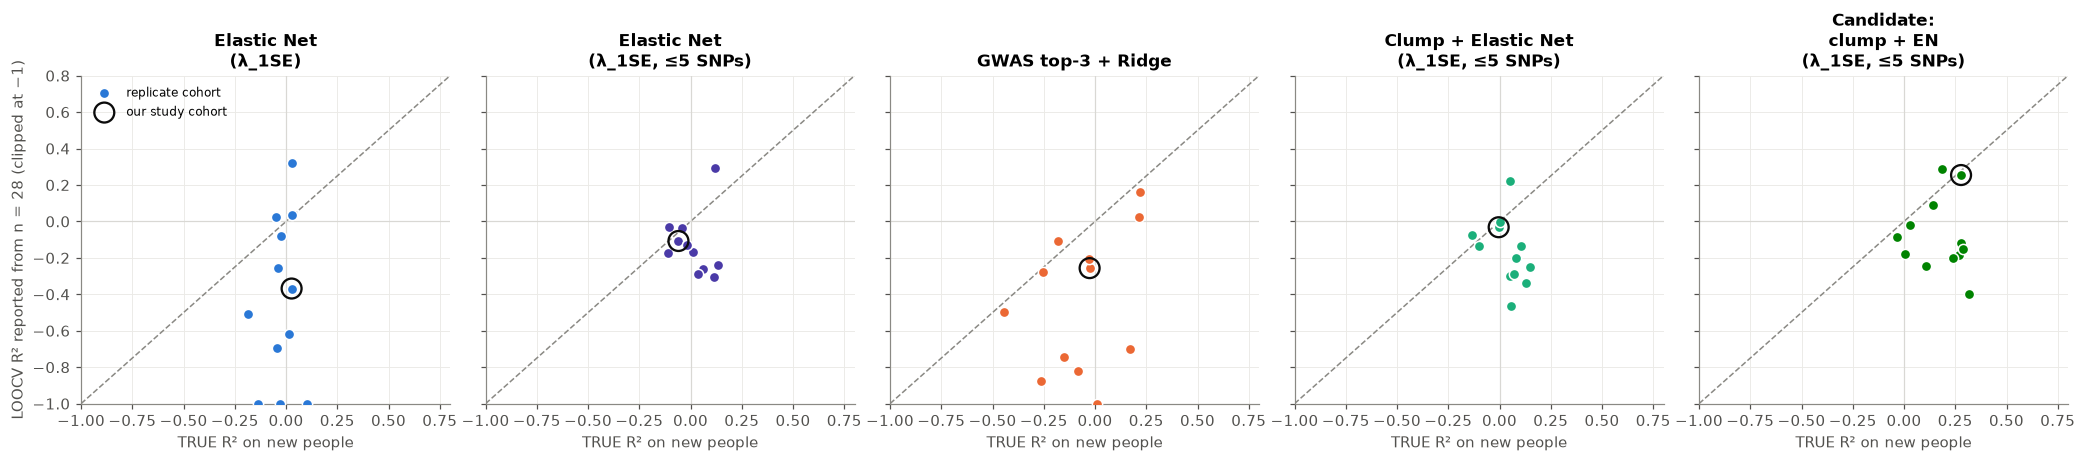

In [40]:
fig, axes = plt.subplots(1, 5, figsize=(19, 4.3), sharex=True, sharey=True)
lims = [-1.0, 0.8]
for ax, m, col in zip(axes, REP_MODELS[1:], (PAL["blue"], PAL["violet"], PAL["orange"], PAL["aqua"], PAL["green"])):
    tx, ly = rep[f"{m} | true"].clip(lims[0], lims[1]), rep[f"{m} | LOOCV"].clip(lims[0], lims[1])
    ax.plot(lims, lims, color=PAL["gray"], ls="--", lw=1)
    ax.axhline(0, color=PAL["lightgray"], lw=0.8); ax.axvline(0, color=PAL["lightgray"], lw=0.8)
    ax.scatter(tx, ly, s=45, color=col, edgecolors="white", zorder=3, label="replicate cohort")
    ax.scatter([tx[0]], [ly[0]], s=170, facecolors="none", edgecolors=PAL["ink"], lw=1.5, zorder=4, label="our study cohort")
    ax.set(xlim=lims, ylim=lims, xlabel="TRUE R² on new people", title=m.replace(" (", "\n(").replace(": ", ":\n"))
axes[0].set_ylabel("LOOCV R² reported from n = 28 (clipped at −1)")
axes[0].legend(fontsize=8, loc="upper left")
plt.tight_layout(); plt.show()

**What to look for.**
* The *vertical* spread is the sampling variability of a LOOCV R² computed from 28 people. It is large, often several tenths. This is Varoquaux's (2018) point: at small n, cross-validation error bars are wide. The bootstrap CI from a single cohort captures part of this spread, not all of it.
* Points on the diagonal would mean LOOCV reports the truth. Any single cohort can land well above or below it. **Report the CI and a permutation p-value, never just a point estimate.**
* The *horizontal* position (true R²) is what the model is really worth. Candidate-region models are consistently further right (in this run, mean true R² ≈ +0.18 across 12 cohorts vs ≈ 0 for every genome-wide model): prior knowledge buys real predictive value, not just a better-looking CV number.
* LOOCV can also be **pessimistic**. Averaged over replicate cohorts, the candidate model's LOOCV R² is *below* its true R². Each fold trains on only 27 people, and selection noise costs more in a fold than in the final fit. In our own cohort, `Candidate: clump + EN (λ_1SE)` reports LOOCV R² ≈ −0.26 while its true R² is ≈ +0.31. Small-n CV errors go in both directions.

## 17. Permutation test: is the R² better than chance?

**Question.** Could an R² this large arise if the SNPs carried **no** information about the phenotype, given the covariates?

**Freedman–Lane permutation** tests the SNPs while keeping the covariate effects intact:

1. Fit the reduced model $y = \hat y_C + e$ (covariates only) on the full cohort.
2. Permute the residuals: $y^{*} = \hat y_C + \pi(e)$. The covariate structure is kept, and any SNP–phenotype link is destroyed.
3. Re-run the **entire nested-LOOCV pipeline** on $y^{*}$, including in-fold clumping, GWAS ranking, inner tuning and the 1-SE rule, and record $\Delta R^2 = R^2_{\text{model}} - R^2_{\text{covariates}}$.
4. $p = \dfrac{1 + \#\{\Delta R^{2*} \ge \Delta R^2_{\text{obs}}\}}{1 + B}$.

> Re-running the *whole* pipeline, not just refitting a fixed model, is what makes the test valid: the null distribution includes all the optimism that comes from tuning and selection (Ojala & Garriga 2010).

In [41]:
C1 = np.column_stack([np.ones(n), C])
gamma_full, *_ = np.linalg.lstsq(C1, y, rcond=None)
y_cov_hat = C1 @ gamma_full
resid_full = y - y_cov_hat
perm_plan = [  # (feature-matrix key, families)
    ("pruned", [enet_family(CFG["l1_ratios"]), gwas_ridge_family()]),
    ("qc", [clump_enet_family(nbrs_qc)]),
    ("cand", [clump_enet_family(nbrs_cand, prefix="Candidate: clump + EN")]),
    ("candp", [gwas_ridge_family(prefix="Candidate: GWAS")]),
]
perm_models = ["Elastic Net (λ_min)", "Elastic Net (λ_1SE)", f"Elastic Net (λ_1SE, {CAP})",
               "GWAS top-2 + Ridge", "GWAS top-3 + Ridge",
               "Clump + Elastic Net (λ_min)", "Clump + Elastic Net (λ_1SE)", f"Clump + Elastic Net (λ_1SE, {CAP})",
               "Candidate: clump + EN (λ_min)", "Candidate: clump + EN (λ_1SE)", f"Candidate: clump + EN (λ_1SE, {CAP})",
               "Candidate: GWAS top-3 + Ridge"]


def one_permutation(b, mats):
    rng_b = np.random.default_rng(CFG["seed"] + 50_000 + b)
    y_star = y_cov_hat + rng_b.permutation(resid_full)          # Freedman–Lane
    rr = {}
    for key, fams in perm_plan:
        rr.update(nested_loocv(mats[key], y_star, C, fams, seed=CFG["seed"] + b, quiet=True))
    base = rr["Covariates only (OLS)"].r2
    return {m: rr[m].r2 - base for m in perm_models}


B = CFG["n_permutations"]
mats = {"pruned": X, "qc": X_qc, "cand": X_cand, "candp": X_candp}
with log_step(f"Permutation test: {B} × full nested LOOCV of every strategy (parallel over {N_JOBS} workers)"):
    null_dist = pd.DataFrame(Parallel(n_jobs=N_JOBS)(delayed(one_permutation)(b, mats) for b in range(B)))
null_dist.to_csv(os.path.join(OUT_DIR, "permutation_null.csv"), index=False)

perm_tbl = []
for m in perm_models:
    obs = summary.loc[m, "ΔR² vs covariates"]
    pval = (1 + np.sum(null_dist[m] >= obs)) / (1 + B)
    perm_tbl.append({"model": m, "observed ΔR²": obs, "null mean": null_dist[m].mean(),
                     "null 95th pct": null_dist[m].quantile(0.95), "permutation p": pval})
perm_tbl = pd.DataFrame(perm_tbl).set_index("model")
logger.info(f"Permutation results (B = {B}; smallest attainable p = {1/(B+1):.4f}):\n" + perm_tbl.round(4).to_string())
perm_tbl.round(4)

03:56:59 | INFO  | ▶ Permutation test: 100 × full nested LOOCV of every strategy (parallel over 4 workers)


04:08:15 | INFO  | ✔ Permutation test: 100 × full nested LOOCV of every strategy (parallel over 4 workers) (done in 675.5 s)


04:08:15 | INFO  | Permutation results (B = 100; smallest attainable p = 0.0099):
                                        observed ΔR²  null mean  null 95th pct  permutation p
model                                                                                        
Elastic Net (λ_min)                           -0.676    -0.3608          0.261         0.7921
Elastic Net (λ_1SE)                           -0.258    -0.2666         0.2572          0.505
Elastic Net (λ_1SE, ≤5 SNPs)                  0.0028    -0.0275         0.1222         0.3168
GWAS top-2 + Ridge                           -0.2535    -0.3677         0.2816         0.4851
GWAS top-3 + Ridge                            -0.146     -0.349         0.2264         0.4059
Clump + Elastic Net (λ_min)                   0.1573    -0.2742         0.2788         0.1287
Clump + Elastic Net (λ_1SE)                   0.1793    -0.2413         0.2938         0.1089
Clump + Elastic Net (λ_1SE, ≤5 SNPs)          0.0783     -0.017         

,observed ΔR²,null mean,null 95th pct,permutation p
model,,,,
Elastic Net (λ_min),-0.676,-0.3608,0.261,0.7921
Elastic Net (λ_1SE),-0.258,-0.2666,0.2572,0.505
"Elastic Net (λ_1SE, ≤5 SNPs)",0.0028,-0.0275,0.1222,0.3168
GWAS top-2 + Ridge,-0.2535,-0.3677,0.2816,0.4851
GWAS top-3 + Ridge,-0.146,-0.349,0.2264,0.4059
Clump + Elastic Net (λ_min),0.1573,-0.2742,0.2788,0.1287
Clump + Elastic Net (λ_1SE),0.1793,-0.2413,0.2938,0.1089
"Clump + Elastic Net (λ_1SE, ≤5 SNPs)",0.0783,-0.017,0.1401,0.1485
Candidate: clump + EN (λ_min),-0.3822,-0.5911,0.1859,0.4356


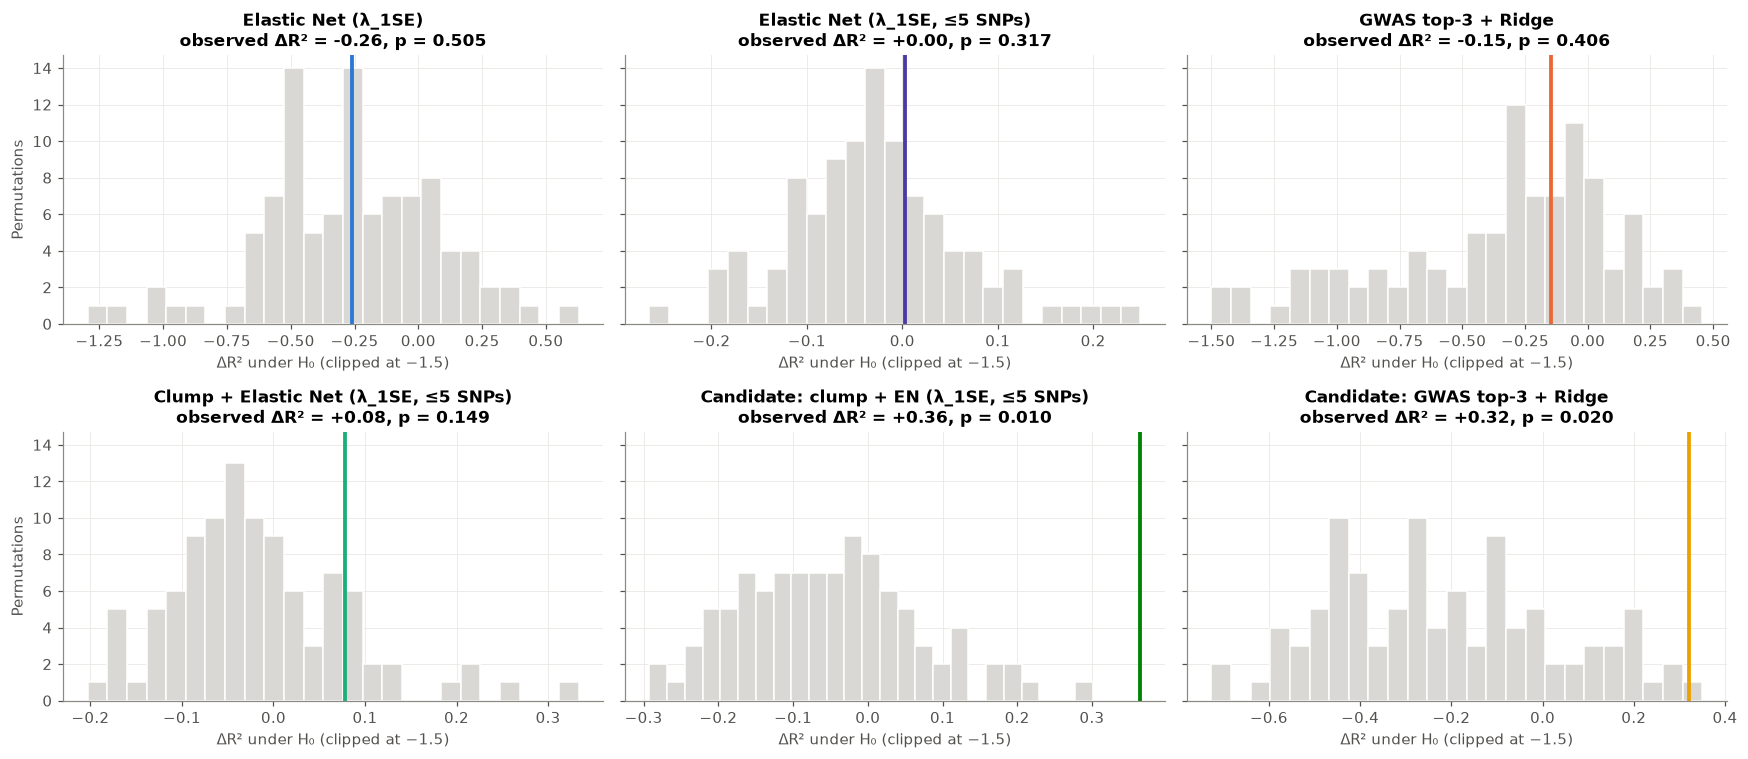

In [42]:
show_perm = ("Elastic Net (λ_1SE)", f"Elastic Net (λ_1SE, {CAP})", "GWAS top-3 + Ridge",
             f"Clump + Elastic Net (λ_1SE, {CAP})", f"Candidate: clump + EN (λ_1SE, {CAP})", "Candidate: GWAS top-3 + Ridge")
fig, axes = plt.subplots(2, 3, figsize=(16, 7), sharey=True)
axes = axes.ravel()
for ax, m, col in zip(axes, show_perm, (PAL["blue"], PAL["violet"], PAL["orange"], PAL["aqua"], PAL["green"], PAL["yellow"])):
    ax.hist(null_dist[m].clip(lower=-1.5), bins=25, color=PAL["lightgray"], edgecolor="white")
    obs = perm_tbl.loc[m, "observed ΔR²"]
    ax.axvline(obs, color=col, lw=2.5)
    ax.set(title=f"{m}\nobserved ΔR² = {obs:+.2f}, p = {perm_tbl.loc[m, 'permutation p']:.3f}",
           xlabel="ΔR² under H₀ (clipped at −1.5)")
axes[0].set_ylabel("Permutations"); axes[3].set_ylabel("Permutations")
plt.tight_layout(); plt.show()

**What to look for.** The null distributions are centred **below zero**: under $H_0$, tuned models lose relative to covariates-only because they spend degrees of freedom on noise. A real signal appears as an observed ΔR² in the far right tail. In this run only the two **candidate-region** models are significant (capped EN p ≈ 0.01, the smallest attainable; GWAS top-3 + Ridge p ≈ 0.02). No genome-wide model is (all p > 0.1), including clumping + EN, whose positive ΔR² is within the null range. With B = 100 the smallest attainable p is 1/101 ≈ 0.01. For a publication, use B ≥ 1,000 (just raise `CFG["n_permutations"]`).

## 18. Selection stability: which SNPs are *reproducibly* chosen?

A single Lasso/EN fit on 28 people returns *a* set of SNPs, but a slightly different sample would return a different set. We need **selection probabilities**.

### 18.1 A tempting but misleading measure: frequency across LOO folds
Two LOO training sets share 26 of 27 people (96%). Selections across folds are therefore **highly correlated**, and frequencies near 100% are *expected* even for false positives. LOO frequency measures sensitivity to single people, not reproducibility.

### 18.2 Complementary-pairs stability selection (CPSS; Meinshausen & Bühlmann 2010; Shah & Samworth 2013)
1. Randomly split the 28 people into two **disjoint halves** of 14. Repeat for $B$ = 100 pairs, giving 200 half-samples.
2. On each half, run Elastic Net (ρ = 0.9) along a fixed λ path and record the first ≈ $q$ = 5 SNPs to enter the model.
3. $\hat\pi_j$ = fraction of half-samples in which SNP $j$ was selected.
4. Declare SNP $j$ **stable** if $\hat\pi_j \ge \pi_{\text{thr}}$.

**Error control.** Under mild exchangeability assumptions, the expected number of falsely selected noise SNPs satisfies

$$ \mathbb{E}[V] \;\le\; \frac{q^2}{(2\pi_{\text{thr}} - 1)\,p}. $$

We run CPSS twice: on the **genome-wide pruned** SNP set, and on the **candidate-region** SNPs. For the candidate set we also report a **gene-level** probability: the fraction of half-samples in which *any* SNP of the gene is selected. That is robust to the signal moving between LD proxies.

> Stability selection is a *selection* tool, not a *prediction* tool. Here we regress covariates out on the full cohort once (FWL), which is fine because we are not estimating out-of-sample performance.

In [43]:
def cpss(Xs, ys, n_pairs, q, l1_ratio, seed, n_grid=40):
    """Complementary-pairs stability selection with Elastic Net paths.

    Returns π̂ (p,), selection-probability paths (p × n_grid), path x-axis (−log10 λ/λmax),
    mean model size q̄, and the per-half-sample selection matrix (2·n_pairs × p).
    """
    n_, half = len(ys), len(ys) // 2
    alpha_max = np.max(np.abs(Xs.T @ ys)) / (n_ * l1_ratio)
    grid = alpha_max * np.logspace(0, -1.5, n_grid)
    rng_ = np.random.default_rng(seed)
    path_hits = np.zeros((Xs.shape[1], n_grid))
    q_sel = []
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", ConvergenceWarning)
        for _ in range(n_pairs):
            perm = rng_.permutation(n_)
            for h in (perm[:half], perm[half:2 * half]):              # two DISJOINT halves
                Xh = Xs[h] - Xs[h].mean(0)
                sd = Xh.std(0)
                Xh = Xh / np.where(sd > 0, sd, 1)
                yh = ys[h] - ys[h].mean()
                _, coefs, _ = enet_path(Xh, yh, l1_ratio=l1_ratio, alphas=grid, max_iter=10_000)
                nz = coefs != 0
                path_hits += nz
                ok = np.flatnonzero(nz.sum(0) <= q)
                q_sel.append(nz[:, ok.max() if len(ok) else 0])        # "first ≈ q variables to enter"
    q_sel = np.array(q_sel)
    return q_sel.mean(0), path_hits / len(q_sel), -np.log10(grid / alpha_max), q_sel.sum(1).mean(), q_sel


def causal_tagging(snps):
    """Reference-panel r² between each SNP (global index) and each causal variant (0 on other chromosomes)."""
    T = np.zeros((len(snps), 3))
    for k, j in enumerate(causal):
        same = snp_chr[snps] == snp_chr[j]
        if same.any():
            T[same, k] = corr_r2(G_ref_f[:, snps[same]], G_ref_f[:, [j]])[:, 0]
    return T


def truth_label(snp):
    """Simulation-only annotation of a SNP (global index)."""
    t = causal_tagging(np.array([snp]))[0]
    k = int(t.argmax())
    if snp == causal[k]:
        return f"causal {'ABC'[k]} itself"
    return f"tags causal {'ABC'[k]} (r²={t[k]:.2f})" if t[k] >= TAG_THR else "—"


def loo_frequency(res, n_cols):
    cnt = np.zeros(n_cols)
    for s in res.selected:
        cnt[s] += 1
    return cnt / len(res.selected)


stab = {}
for label, cols, Xm in (("genome-wide pruned", feat_idx, X), ("candidate regions", cand_idx, X_cand)):
    Xs_, _, ys_, _ = prepare_split(Xm, y, C, Xm[:1], C[:1])          # FWL on the full cohort (selection only)
    with log_step(f"CPSS on {label} SNPs (p = {len(cols)}): {CFG['cpss_pairs']} complementary pairs"):
        pi_, path_, xpath_, qbar_, qsel_ = cpss(Xs_, ys_, CFG["cpss_pairs"], CFG["cpss_q"], CFG["cpss_l1_ratio"],
                                                seed=CFG["seed"] + 6)
    bound = qbar_ ** 2 / ((2 * CFG["cpss_pi_thr"] - 1) * len(cols))
    stab[label] = dict(cols=cols, pi=pi_, path=path_, x=xpath_, qsel=qsel_, bound=bound,
                       stable=np.flatnonzero(pi_ >= CFG["cpss_pi_thr"]), tag=causal_tagging(cols))
    logger.info(f"  {label}: q̄ = {qbar_:.2f}, stable SNPs (π̂ ≥ {CFG['cpss_pi_thr']}) = {len(stab[label]['stable'])}, "
                f"E[false stable] ≤ {bound:.3f}")

loo_gw = loo_frequency(all_res["Elastic Net (λ_1SE)"], p_feat)
loo_cd = loo_frequency(all_res["Candidate: clump + EN (λ_1SE)"], len(cand_idx))
tables = {}
for label, loo in (("genome-wide pruned", loo_gw), ("candidate regions", loo_cd)):
    s_ = stab[label]
    top = np.argsort(-s_["pi"])[:10]
    tables[label] = pd.DataFrame({"SNP": snp_id[s_["cols"][top]], "CPSS π̂": s_["pi"][top],
                                  "LOO-fold freq": loo[top], "truth (simulation only)": [truth_label(j) for j in s_["cols"][top]]})
    if label == "candidate regions":
        tables[label].insert(1, "gene", regions["gene"].to_numpy()[snp_region[s_["cols"][top]]])
    logger.info(f"Top SNPs by stability, {label}:\n" + tables[label].round(3).to_string(index=False))

# Gene-level stability: fraction of half-samples selecting ≥ 1 SNP in the gene
reg_of_cand = snp_region[cand_idx]
regions["gene-level π̂"] = [stab["candidate regions"]["qsel"][:, reg_of_cand == r].any(1).mean() for r in range(len(regions))]
logger.info("Gene-level stability:\n" + regions[["gene", "chr", "QC SNPs", "gene-level π̂", "truth (hidden)"]].round(3).to_string(index=False))
tables["candidate regions"].round(3)

04:08:15 | INFO  | ▶ CPSS on genome-wide pruned SNPs (p = 379): 100 complementary pairs


04:08:16 | INFO  | ✔ CPSS on genome-wide pruned SNPs (p = 379): 100 complementary pairs (done in 0.7 s)


04:08:16 | INFO  |   genome-wide pruned: q̄ = 4.85, stable SNPs (π̂ ≥ 0.6) = 0, E[false stable] ≤ 0.310


04:08:16 | INFO  | ▶ CPSS on candidate regions SNPs (p = 906): 100 complementary pairs


04:08:18 | INFO  | ✔ CPSS on candidate regions SNPs (p = 906): 100 complementary pairs (done in 2.0 s)


04:08:18 | INFO  |   candidate regions: q̄ = 4.62, stable SNPs (π̂ ≥ 0.6) = 0, E[false stable] ≤ 0.118


04:08:18 | INFO  | Top SNPs by stability, genome-wide pruned:
         SNP  CPSS π̂  LOO-fold freq truth (simulation only)
 chr7:859814    0.335          0.607                       —
chr14:500517    0.235          0.571 tags causal A (r²=0.59)
 chr7:872687    0.225          0.643                       —
chr17:324447    0.155            0.5                       —
chr11:199557    0.155          0.429                       —
 chr1:671943    0.125            0.5                       —
chr14:593547     0.12          0.393                       —
 chr7:439912    0.115          0.536                       —
chr10:964959    0.105          0.536                       —
 chr14:93254      0.1          0.071                       —


04:08:18 | INFO  | Top SNPs by stability, candidate regions:
         SNP  gene  CPSS π̂  LOO-fold freq truth (simulation only)
chr14:490248 GENE5     0.37          0.821 tags causal A (r²=1.00)
chr11:608866 GENE6    0.285              1 tags causal C (r²=0.62)
chr14:498487 GENE5     0.26          0.179 tags causal A (r²=0.94)
chr14:459945 GENE5    0.135              0                       —
chr14:509883 GENE5    0.095              0 tags causal A (r²=0.67)
chr14:498381 GENE5    0.095              0 tags causal A (r²=0.94)
chr14:509239 GENE5     0.09              0 tags causal A (r²=0.63)
chr15:474957 GENE8    0.085          0.214                       —
chr14:492074 GENE5    0.085              0 tags causal A (r²=0.64)
chr14:505309 GENE5    0.075              0 tags causal A (r²=0.86)


04:08:18 | INFO  | Gene-level stability:
 gene  chr  QC SNPs  gene-level π̂    truth (hidden)
GENE1   17       88           0.16             decoy
GENE2    1      134          0.295             decoy
GENE3    6       94          0.065             decoy
GENE4   13      146           0.15             decoy
GENE5   14      136           0.87 contains causal A
GENE6   11      114          0.425 contains causal C
GENE7   12       50          0.095             decoy
GENE8   15      144            0.5 contains causal B


,SNP,gene,CPSS π̂,LOO-fold freq,truth (simulation only)
0,chr14:490248,GENE5,0.37,0.821,tags causal A (r²=1.00)
1,chr11:608866,GENE6,0.285,1,tags causal C (r²=0.62)
2,chr14:498487,GENE5,0.26,0.179,tags causal A (r²=0.94)
3,chr14:459945,GENE5,0.135,0,—
4,chr14:509883,GENE5,0.095,0,tags causal A (r²=0.67)
5,chr14:498381,GENE5,0.095,0,tags causal A (r²=0.94)
6,chr14:509239,GENE5,0.09,0,tags causal A (r²=0.63)
7,chr15:474957,GENE8,0.085,0.214,—
8,chr14:492074,GENE5,0.085,0,tags causal A (r²=0.64)
9,chr14:505309,GENE5,0.075,0,tags causal A (r²=0.86)


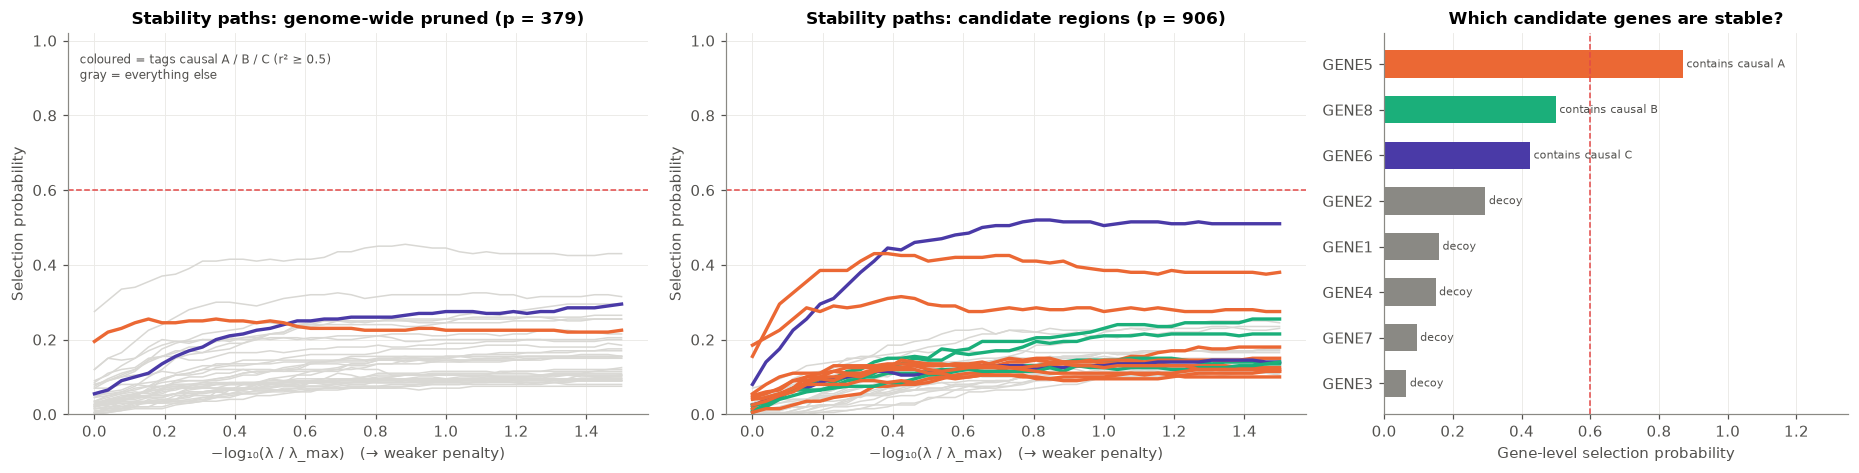

In [44]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.4), gridspec_kw={"width_ratios": [1, 1, 0.8]})
for ax, label in zip(axes[:2], ("genome-wide pruned", "candidate regions")):
    s_ = stab[label]
    order_ = np.argsort(-s_["path"].max(1))[:40]
    for f in order_:
        k = int(s_["tag"][f].argmax()); is_tag = s_["tag"][f, k] >= TAG_THR
        ax.plot(s_["x"], s_["path"][f], color=CAUSAL_COLORS[k] if is_tag else PAL["lightgray"],
                lw=2.2 if is_tag else 1, zorder=3 if is_tag else 1)
    ax.axhline(CFG["cpss_pi_thr"], color=PAL["red"], ls="--", lw=1)
    ax.set(xlabel="−log₁₀(λ / λ_max)   (→ weaker penalty)", ylabel="Selection probability", ylim=(0, 1.02),
           title=f"Stability paths: {label} (p = {len(s_['cols'])})")
axes[0].text(0.02, 0.95, "coloured = tags causal A / B / C (r² ≥ 0.5)\ngray = everything else", transform=axes[0].transAxes,
             fontsize=8, va="top", color=PAL["ink2"])
ax = axes[2]
rg = regions.sort_values("gene-level π̂")
cols_ = [CAUSAL_COLORS["ABC".index(t[-1])] if t.startswith("contains") else PAL["gray"] for t in rg["truth (hidden)"]]
ax.barh(rg["gene"], rg["gene-level π̂"], color=cols_, height=0.6)
ax.axvline(CFG["cpss_pi_thr"], color=PAL["red"], ls="--", lw=1)
for yi, (v, t) in enumerate(zip(rg["gene-level π̂"], rg["truth (hidden)"])):
    ax.text(v + 0.01, yi, t, va="center", fontsize=7, color=PAL["ink2"])
ax.set(xlim=(0, 1.35), xlabel="Gene-level selection probability", title="Which candidate genes are stable?")
ax.grid(axis="y", visible=False)
plt.tight_layout(); plt.show()

**What to look for.**
* **Genome-wide**, no SNP is stable at n = 28, and the most "stable" pruned SNP is a noise SNP. This is the multiple-testing wall from §15 in another form. The error bound is still valid, so anything declared stable would be trustworthy, but power is low.
* **Within candidate regions**, the SNP-level probabilities are highest for tags of causal A and C, but they stay below 0.6: the signal is *shared among LD proxies*, so no single SNP wins consistently. Aggregating to the **gene level** fixes this. The gene containing causal A is clearly stable (π̂ ≈ 0.87), the genes with B and C come next (≈ 0.4–0.5), and all five decoys stay below 0.3.
* The **LOO-fold frequency** is systematically *higher* than π̂. For example, the tag of causal C is selected in 100% of LOO folds but in only ~30% of half-samples. That is the correlation artefact from §18.1.

## 19. Negative control: what failure looks like (a purely polygenic trait)

Many traits studied in small cohorts are **highly polygenic**: heritable (here h² = 50%), but spread over thousands of tiny effects. We run the *identical* pipelines on such a trait, using the same people, genotypes and covariates. Every SNP now explains ≪ 1% of the variance, and §2 and §15 say nothing is learnable at n = 28, even inside candidate regions.

In [45]:
y_neg = y_neg_pool[coh]
with log_step("Nested LOOCV on the polygenic negative-control trait"):
    res_neg = nested_loocv(X, y_neg, C, [enet_family(CFG["l1_ratios"]), gwas_ridge_family((3,))],
                           seed=CFG["seed"], quiet=True)
    res_neg.update({k: v for k, v in nested_loocv(X_qc, y_neg, C, [clump_enet_family(nbrs_qc, variants=("1se", "cap"))],
                                                  seed=CFG["seed"], quiet=True).items() if k.startswith("Clump")})
    res_neg.update({k: v for k, v in nested_loocv(X_cand, y_neg, C, [clump_enet_family(nbrs_cand, prefix="Candidate: clump + EN", variants=("1se", "cap"))],
                                                  seed=CFG["seed"], quiet=True).items() if k.startswith("Candidate")})
neg_sum = summarize(res_neg)
neg_sum["ΔR² vs covariates"] = neg_sum["R²_LOO"] - neg_sum.loc["Covariates only (OLS)", "R²_LOO"]
logger.info("Polygenic control, nested LOOCV:\n" + neg_sum.round(3).to_string())
snp_models = neg_sum.drop(["Null (training mean)", "Covariates only (OLS)"])["ΔR² vs covariates"]
logger.info(f"→ Heritability is 50%, yet the best SNP model adds only ΔR² = {snp_models.max():+.3f} ({snp_models.idxmax()}), "
            f"well inside the permutation null of §17: the signal is real but not learnable at n = 28.")
neg_sum.round(3)

04:08:18 | INFO  | ▶ Nested LOOCV on the polygenic negative-control trait


04:08:46 | INFO  | ✔ Nested LOOCV on the polygenic negative-control trait (done in 28.2 s)


04:08:46 | INFO  | Polygenic control, nested LOOCV:
                                        R²_LOO  RMSE  Pearson r  median #SNPs used range #SNPs  ΔR² vs covariates
model                                                                                                            
Null (training mean)                    -0.075 0.925         -1                  0         0–0             -0.051
Covariates only (OLS)                   -0.024 0.903      0.238                  0         0–0                  0
Elastic Net (λ_min)                     -1.393  1.38     -0.414               24.5        0–32             -1.368
Elastic Net (λ_1SE)                      -1.08 1.287     -0.306                  0        0–28             -1.056
Elastic Net (λ_1SE, ≤5 SNPs)            -0.144 0.954      0.119                  0         0–5             -0.119
GWAS top-3 + Ridge                      -0.583 1.123     -0.063                  3         3–3             -0.558
Clump + Elastic Net (λ_1SE)         

04:08:46 | INFO  | → Heritability is 50%, yet the best SNP model adds only ΔR² = +0.035 (Candidate: clump + EN (λ_1SE, ≤5 SNPs)), well inside the permutation null of §17: the signal is real but not learnable at n = 28.


,R²_LOO,RMSE,Pearson r,median #SNPs used,range #SNPs,ΔR² vs covariates
model,,,,,,
Null (training mean),-0.075,0.925,-1,0,0–0,-0.051
Covariates only (OLS),-0.024,0.903,0.238,0,0–0,0
Elastic Net (λ_min),-1.393,1.38,-0.414,24.5,0–32,-1.368
Elastic Net (λ_1SE),-1.08,1.287,-0.306,0,0–28,-1.056
"Elastic Net (λ_1SE, ≤5 SNPs)",-0.144,0.954,0.119,0,0–5,-0.119
GWAS top-3 + Ridge,-0.583,1.123,-0.063,3,3–3,-0.558
Clump + Elastic Net (λ_1SE),-0.471,1.082,-0.026,25,18–31,-0.447
"Clump + Elastic Net (λ_1SE, ≤5 SNPs)",-0.112,0.941,0.162,4,0–5,-0.087
Candidate: clump + EN (λ_1SE),-1.176,1.317,0.034,18.5,5–25,-1.152


## 20. The final model and how to report it

**The rule.** *Performance* comes from nested LOOCV (Sections 14–15), with its uncertainty (16) and permutation p-value (17). The *model you report or deploy* is refitted **once on all 28 people** with the same procedure: in-fold clumping, inner CV for λ and ρ, and the 1-SE rule. Its coefficients are **not** themselves validated, so pair them with stability (Section 18).

Below: the final candidate-region model (the recommended strategy when prior knowledge exists) and the final genome-wide model from the original pruning pipeline.

In [46]:
pi_by_snp = {}
for s_ in stab.values():
    pi_by_snp.update(dict(zip(s_["cols"], s_["pi"])))


def final_model_table(model):
    _, sel, hyp = final_fit[model]
    cols = final_cols[model][sel]                       # global SNP indices of the selected features
    sd_x = D_coh[:, cols].std(0)
    return pd.DataFrame({
        "SNP": snp_id[cols],
        "gene (candidate)": [regions["gene"].iat[snp_region[j]] if snp_region[j] >= 0 else "" for j in cols],
        "β per SD": hyp["coef"], "β per allele (approx.)": hyp["coef"] / np.where(sd_x > 0, sd_x, 1),
        "cohort MAF": maf_coh[cols], "Rsq": snp_stats["rsq"].to_numpy()[cols],
        "CPSS π̂": [pi_by_snp.get(j, np.nan) for j in cols],
        "truth (simulation only)": [truth_label(j) for j in cols],
    }).sort_values("β per SD", key=np.abs, ascending=False)


for model in (f"Candidate: clump + EN (λ_1SE, {CAP})", "Elastic Net (λ_1SE)"):
    t_ = final_model_table(model)
    h_ = final_fit[model][2]
    logger.info(f"Final model '{model}' on all {n}: λ = {h_['alpha']:.4g}, ρ = {h_['l1_ratio']}, {len(t_)} SNPs\n"
                + t_.round(3).to_string(index=False))
    fname = "".join(ch if ch.isalnum() else "_" for ch in model).strip("_")
    t_.to_csv(os.path.join(OUT_DIR, f"final_model_{fname}.csv"), index=False)
final_model_table(f"Candidate: clump + EN (λ_1SE, {CAP})").round(3)

04:08:46 | INFO  | Final model 'Candidate: clump + EN (λ_1SE, ≤5 SNPs)' on all 28: λ = 0.3797, ρ = 0.7, 4 SNPs
         SNP gene (candidate)  β per SD  β per allele (approx.)  cohort MAF   Rsq  CPSS π̂ truth (simulation only)
chr14:490248            GENE5     0.317                    0.43       0.418     1     0.37 tags causal A (r²=1.00)
chr15:419557            GENE8     0.112                   0.165       0.268     1    0.075                       —
chr11:608866            GENE6    -0.101                  -0.167       0.336 0.823    0.285 tags causal C (r²=0.62)
chr15:554011            GENE8    -0.097                  -0.149       0.464 0.851    0.055 tags causal B (r²=1.00)


04:08:46 | INFO  | Final model 'Elastic Net (λ_1SE)' on all 28: λ = 0.02793, ρ = 0.7, 29 SNPs
         SNP gene (candidate)  β per SD  β per allele (approx.)  cohort MAF   Rsq  CPSS π̂ truth (simulation only)
 chr7:859814                     -0.253                  -0.636       0.108 0.825    0.335                       —
chr10:964959                        0.2                   0.336       0.184     1    0.105                       —
 chr7:439912                     -0.186                  -0.369       0.124     1    0.115                       —
chr14:500517            GENE5    -0.145                  -0.192         0.5     1     0.01 tags causal A (r²=0.59)
chr20:620625                     -0.128                  -0.178       0.448     1     0.03                       —
 chr7:872687                     -0.122                  -0.187       0.497 0.848    0.225                       —
chr11:593949            GENE6     0.121                   0.184         0.5 0.857    0.015 tags causa

,SNP,gene (candidate),β per SD,β per allele (approx.),cohort MAF,Rsq,CPSS π̂,truth (simulation only)
0,chr14:490248,GENE5,0.317,0.43,0.418,1,0.37,tags causal A (r²=1.00)
3,chr15:419557,GENE8,0.112,0.165,0.268,1,0.075,—
2,chr11:608866,GENE6,-0.101,-0.167,0.336,0.823,0.285,tags causal C (r²=0.62)
1,chr15:554011,GENE8,-0.097,-0.149,0.464,0.851,0.055,tags causal B (r²=1.00)


In [47]:
report_models = ["Elastic Net (λ_1SE)", f"Elastic Net (λ_1SE, {CAP})", "GWAS top-3 + Ridge", f"Clump + Elastic Net (λ_1SE, {CAP})",
                 f"Candidate: clump + EN (λ_1SE, {CAP})", "Candidate: GWAS top-3 + Ridge"]
report_tbl = pd.DataFrame({
    "LOOCV R²": [all_res[m].r2 for m in report_models],
    "bootstrap 95% CI": [ext_tbl.loc[m, "bootstrap 95% CI"] for m in report_models],
    "ΔR² vs covariates": [summary.loc[m, "ΔR² vs covariates"] for m in report_models],
    "permutation p": [perm_tbl.loc[m, "permutation p"] for m in report_models],
    "#SNPs (final model)": [len(final_fit[m][1]) for m in report_models],
    "TRUE R² (simulation only)": [ext_tbl.loc[m, "TRUE R² (472 new people)"] for m in report_models],
}, index=report_models)
report_tbl.to_csv(os.path.join(OUT_DIR, "reporting_table.csv"))
header = f"""
REPORTING SUMMARY (auto-generated from this run)
------------------------------------------------
Cohort: n = {n} ({CFG['n_cohort_eur']} EUR, {CFG['n_cohort_eas']} EAS); continuous phenotype (z-scored).
Variants: {qc_funnel.remaining.iloc[0]:,} → {qc_keep.sum():,} after QC (MAF ≥ {CFG['maf_min']}, Rsq ≥ {CFG['rsq_min']}, HWE p ≥ {CFG['hwe_p_min']:g}).
  Pruning (reference-panel LD, window {CFG['prune_window']}, step {CFG['prune_step']}, r² < {CFG['prune_r2']}) → {p_feat:,} SNPs.
  Clumping (in-fold, reference LD, r² > {CFG['clump_r2']}, ±{CFG['clump_kb']} kb) on all {len(qc_idx):,} QC'd SNPs.
  Candidate regions: {len(regions)} pre-specified genes (±{CFG['candidate_kb']} kb) → {len(cand_idx)} QC'd SNPs.
Covariates (unpenalized via FWL inside each fold): {', '.join(COV_NAMES)} (PCs projected from the reference panel).
Model: Elastic Net, l1_ratio ∈ {list(CFG['l1_ratios'])}, {CFG['n_alphas']}-point λ path, 1-SE rule;
       inner CV = {CFG['inner_repeats']}× repeated {CFG['inner_splits']}-fold; outer CV = leave-one-out.
Baselines: covariates-only LOOCV R² = {all_res['Covariates only (OLS)'].r2:+.3f}; mean-only = {1 - (n/(n-1))**2:+.3f} (theory).
Permutation: Freedman–Lane, B = {B}, whole pipeline re-run. Stability: CPSS, {CFG['cpss_pairs']} pairs, q = {CFG['cpss_q']}, π_thr = {CFG['cpss_pi_thr']}.
"""
logger.info(header + "\n" + report_tbl.round(3).to_string())
with open(os.path.join(OUT_DIR, "reporting_summary.txt"), "w") as fh:
    fh.write(header + "\n" + report_tbl.round(3).to_string() + "\n")
report_tbl.round(3)

04:08:46 | INFO  | 
REPORTING SUMMARY (auto-generated from this run)
------------------------------------------------
Cohort: n = 28 (22 EUR, 6 EAS); continuous phenotype (z-scored).
Variants: 27,428 → 10,212 after QC (MAF ≥ 0.1, Rsq ≥ 0.8, HWE p ≥ 1e-06).
  Pruning (reference-panel LD, window 50, step 5, r² < 0.1) → 379 SNPs.
  Clumping (in-fold, reference LD, r² > 0.1, ±250 kb) on all 10,212 QC'd SNPs.
  Candidate regions: 8 pre-specified genes (±100 kb) → 906 QC'd SNPs.
Covariates (unpenalized via FWL inside each fold): sex, age, PC1 (PCs projected from the reference panel).
Model: Elastic Net, l1_ratio ∈ [0.7, 0.8, 0.9], 30-point λ path, 1-SE rule;
       inner CV = 2× repeated 5-fold; outer CV = leave-one-out.
Baselines: covariates-only LOOCV R² = -0.110; mean-only = -0.075 (theory).
Permutation: Freedman–Lane, B = 100, whole pipeline re-run. Stability: CPSS, 100 pairs, q = 5, π_thr = 0.6.

                                        LOOCV R² bootstrap 95% CI  ΔR² vs covariates  permu

,LOOCV R²,bootstrap 95% CI,ΔR² vs covariates,permutation p,#SNPs (final model),TRUE R² (simulation only)
Elastic Net (λ_1SE),-0.368,"[-0.94, -0.01]",-0.258,0.505,29,0.027
"Elastic Net (λ_1SE, ≤5 SNPs)",-0.107,"[-0.62, +0.16]",0.003,0.317,3,-0.059
GWAS top-3 + Ridge,-0.256,"[-0.72, +0.11]",-0.146,0.406,3,-0.026
"Clump + Elastic Net (λ_1SE, ≤5 SNPs)",-0.032,"[-0.54, +0.23]",0.078,0.149,2,-0.004
"Candidate: clump + EN (λ_1SE, ≤5 SNPs)",0.255,"[-0.12, +0.47]",0.365,0.01,4,0.278
Candidate: GWAS top-3 + Ridge,0.21,"[-0.11, +0.47]",0.32,0.02,3,0.213


### Reporting checklist for small-n genomic prediction papers

- [ ] Sample size, ancestry composition, phenotype definition and transformation.
- [ ] Imputation panel/server, Rsq threshold, MAF (and MAC) threshold, HWE handling.
- [ ] LD pruning or clumping parameters, **which data the LD was estimated from**, and (for clumping) that it ran inside each fold.
- [ ] Any candidate-region restriction, with its source, **fixed before phenotype analysis**.
- [ ] Every step that uses the phenotype (covariate adjustment, clumping, GWAS ranking, tuning) happens **inside** the outer CV. State this explicitly.
- [ ] Hyperparameter grid, inner CV scheme and λ-selection rule (min vs 1-SE).
- [ ] LOOCV R² computed from pooled predictions, **plus** a CI, **plus** a permutation p-value that re-runs the whole pipeline.
- [ ] The covariates-only baseline and ΔR². Note that the null LOOCV R² is −(2n−1)/(n−1)² ≈ −0.075, not 0.
- [ ] Selection stability (CPSS π̂, gene-level π̂, error bound), not only the final model's coefficient list.
- [ ] A clear statement that n = 28 findings are **hypothesis-generating** and need replication.

## 21. Running this on your own data

### 21.1 Preparing inputs with PLINK 2 (optional; the loaders below are pure Python)

```bash
# 1) QC on imputed dosages (Minimac/TOPMed VCF with DS + R2 INFO fields)
plink2 --vcf chr1-22.dose.vcf.gz dosage=DS --extract-if-info "R2 >= 0.8" \
       --maf 0.10 --hwe 1e-6 --make-pgen --out cohort_qc

# 2) LD pruning with LD from an ancestry-matched REFERENCE panel (e.g. 1000 Genomes EUR),
#    restricted to the variants that passed QC in your cohort
plink2 --pfile cohort_qc --write-snplist --out cohort_qc
plink2 --pfile 1kg_EUR --extract cohort_qc.snplist --indep-pairwise 50 5 0.1 --out ref_prune

# 3) Export pruned dosages in additive format → a .raw file readable by load_plink_raw()
plink2 --pfile cohort_qc --extract ref_prune.prune.in --export A --out cohort_pruned
```

### 21.2 Pure-Python loaders

These are tested below on small example files written to `outputs/`.

In [48]:
def load_plink_raw(path):
    """Read a PLINK additive `.raw` file (plink2 --export A / plink --recode A).

    Returns (sample table, dosage matrix [n × m] float, SNP ids, counted alleles).
    Column names look like 'rs123_A', meaning the dosage counts allele A.
    """
    df = pd.read_csv(path, sep=r"\s+")
    meta_cols = ["FID", "IID", "PAT", "MAT", "SEX", "PHENOTYPE"]
    geno = df.drop(columns=meta_cols)
    snps, alleles = zip(*(c.rsplit("_", 1) for c in geno.columns))
    D = geno.to_numpy(dtype=float)                       # 'NA' → NaN
    logger.info(f"Loaded {path}: {D.shape[0]} samples × {D.shape[1]} variants; missing = {np.isnan(D).mean():.2%}")
    return df[meta_cols], D, np.array(snps), np.array(alleles)


def load_vcf_dosage(path, field="DS", info_keys=("R2", "INFO", "MAF")):
    """Stream a (b)gzipped or plain VCF and extract per-sample dosages from the FORMAT field `field`.

    Returns (sample ids, dosage matrix [n × m], variant table with CHROM/POS/ID/REF/ALT + INFO keys).
    """
    opener = gzip.open if path.endswith(".gz") else open
    samples, rows, variants = None, [], []
    with opener(path, "rt") as fh:
        for line in fh:
            if line.startswith("##"):
                continue
            if line.startswith("#CHROM"):
                samples = line.rstrip("\n").split("\t")[9:]
                continue
            f = line.rstrip("\n").split("\t")
            fmt = f[8].split(":")
            if field not in fmt:
                raise ValueError(f"FORMAT field {field} not found at {f[0]}:{f[1]}")
            k = fmt.index(field)
            rows.append([float(s.split(":")[k]) if s.split(":")[k] not in (".", "") else np.nan for s in f[9:]])
            info = dict(kv.split("=", 1) if "=" in kv else (kv, True) for kv in f[7].split(";"))
            variants.append({"CHROM": f[0], "POS": int(f[1]), "ID": f[2], "REF": f[3], "ALT": f[4],
                             **{key: float(info[key]) for key in info_keys if key in info}})
    D = np.array(rows, dtype=float).T
    logger.info(f"Loaded {path}: {D.shape[0]} samples × {D.shape[1]} variants (field {field})")
    return np.array(samples), D, pd.DataFrame(variants)


# ── Self-test on tiny example files built from our simulated cohort ──────────
demo_snps = feat_idx[:5]
raw_path = os.path.join(OUT_DIR, "example_cohort.raw")
raw_df = pd.DataFrame({"FID": meta_pool.iid[coh].values, "IID": meta_pool.iid[coh].values, "PAT": 0, "MAT": 0,
                       "SEX": (sex[coh] + 1).astype(int), "PHENOTYPE": np.round(y, 4)})
for j in demo_snps:
    raw_df[f"{snp_id[j]}_A"] = np.round(D_pool[coh, j], 3)
raw_df.to_csv(raw_path, sep=" ", index=False)
_, D_raw, ids_raw, _ = load_plink_raw(raw_path)

vcf_path = os.path.join(OUT_DIR, "example_cohort.dose.vcf.gz")
with gzip.open(vcf_path, "wt") as fh:
    fh.write("##fileformat=VCFv4.2\n##FORMAT=<ID=DS,Number=1,Type=Float,Description=\"Dosage\">\n")
    fh.write("#CHROM\tPOS\tID\tREF\tALT\tQUAL\tFILTER\tINFO\tFORMAT\t" + "\t".join(meta_pool.iid[coh]) + "\n")
    for j in demo_snps:
        ds = "\t".join(f"{v:.3f}" for v in D_pool[coh, j])
        fh.write(f"{snp_chr[j]}\t{snp_pos[j]}\t{snp_id[j]}\tA\tG\t.\tPASS\tR2={snp_stats.rsq[j]:.3f};MAF={maf_coh[j]:.3f}\tDS\t{ds}\n")
_, D_vcf, var_tbl = load_vcf_dosage(vcf_path)
assert np.allclose(D_raw, D_vcf, atol=1e-3), "loaders disagree"
logger.info("Both loaders round-trip the same dosages ✔\n" + var_tbl.to_string(index=False))

04:08:46 | INFO  | Loaded outputs/example_cohort.raw: 28 samples × 5 variants; missing = 0.00%


04:08:46 | INFO  | Loaded outputs/example_cohort.dose.vcf.gz: 28 samples × 5 variants (field DS)


04:08:46 | INFO  | Both loaders round-trip the same dosages ✔
CHROM    POS          ID REF ALT    R2   MAF
    1  57953  chr1:57953   A   G 0.982 0.496
    1 115175 chr1:115175   A   G     1  0.25
    1 118791 chr1:118791   A   G 0.901 0.492
    1 201383 chr1:201383   A   G 0.954 0.166
    1 242358 chr1:242358   A   G     1 0.318


### 21.3 Plugging your data into the pipeline

```python
fam, D_coh, snp_ids, _ = load_plink_raw("cohort_pruned.raw")    # already QC'd + pruned by PLINK
y   = pd.read_csv("phenotype.tsv", sep="\t").set_index("IID").loc[fam.IID, "trait"].to_numpy()
C   = pd.read_csv("covariates.tsv", sep="\t").set_index("IID").loc[fam.IID, ["sex", "age", "PC1"]].to_numpy()
X   = np.nan_to_num(D_coh, nan=np.nanmean(D_coh, axis=0))        # mean-impute rare missing dosages
res = nested_loocv(X, y, C, [enet_family(CFG["l1_ratios"]), gwas_ridge_family()],
                   log_model="Elastic Net (λ_1SE)", feature_names=snp_ids)
summarize(res)
```
Then run Sections 17–18 unchanged: set `X`, `y`, `C`, `feat_names = snp_ids` and `p_feat = X.shape[1]`, and skip the "truth" columns, which exist only in simulation.

**Adapting the thresholds to your n.** Keep MAC = 2·n·MAF ≥ ~5. Keep the number of unpenalized covariates ≤ n/10. For n > ~60, 5×-repeated 10-fold outer CV becomes a reasonable alternative to LOOCV. Always keep the whole pipeline nested.

## 22. Take-home messages

1. **Know what is learnable.** At n = 28 only variants explaining a large share of the variance leave a usable trace (§2), and a purely polygenic trait is not learnable at all, however heritable (§19). Check your trait's expected architecture *before* the study.
2. **Continuous dosages are an asset.** They are posterior means, so effect estimates are calibrated (§4). Filter strictly on Rsq and on minor-allele *count*.
3. **Estimate LD from a reference panel, not from your 28 people.** A sizeable share of independent SNP pairs exceeds r² = 0.1 by chance at n = 28, and mixed ancestry makes it worse (§7).
4. **Pruning is phenotype-blind and can lose the causal signal** (§8). **Clumping inside each training fold** keeps the best-tagging SNP of every LD block (§8.1, §14).
5. **Penalize.** OLS memorises (§10.7). Lasso/EN turn feature selection into soft-thresholding (§10.3). EN's grouping helps inside LD blocks (§11) but largely disappears after strict pruning.
6. **Nest everything that touches y**: covariate adjustment, clumping, GWAS ranking and hyperparameter tuning (§12–13). The baseline is not 0: the mean-only LOOCV R² is −0.075 at n = 28. Compare against covariates-only and report ΔR².
7. **The data cannot choose the model size at n = 27** (§14.1). Bring the prior yourself: a hard cap of ~n/5 SNPs, fixed in advance.
8. **Shrink the search space with biological priors.** It is the single most effective lever (§15): the chance-correlation wall drops from |r| ≈ 0.6 (genome-wide) to ≈ 0.45 (a few genes). Fix the candidate list before touching the phenotype.
9. **Put error bars on everything.** LOOCV R² from 28 people varies a lot between cohorts (§16). Add a **permutation test that re-runs the entire pipeline** (§17).
10. **Report stability, not just a SNP list.** CPSS gives selection probabilities with a finite-sample error bound. Gene-level stability is more robust than SNP-level stability, and LOO-fold frequencies are inflated (§18).
11. **Treat n = 28 results as hypotheses** to be replicated in an independent cohort.

## References

- Tibshirani R (1996). Regression shrinkage and selection via the lasso. *J R Stat Soc B* 58:267–288.
- Zou H, Hastie T (2005). Regularization and variable selection via the elastic net. *J R Stat Soc B* 67:301–320.
- Friedman J, Hastie T, Tibshirani R (2010). Regularization paths for generalized linear models via coordinate descent. *J Stat Softw* 33(1).
- Hastie T, Tibshirani R, Friedman J (2009). *The Elements of Statistical Learning*, 2nd ed., §7.10 (one-standard-error rule).
- Varma S, Simon R (2006). Bias in error estimation when using cross-validation for model selection. *BMC Bioinformatics* 7:91.
- Ambroise C, McLachlan GJ (2002). Selection bias in gene extraction on the basis of microarray gene-expression data. *PNAS* 99:6562–6566.
- Varoquaux G (2018). Cross-validation failure: small sample sizes lead to large error bars. *NeuroImage* 180:68–77.
- Meinshausen N, Bühlmann P (2010). Stability selection. *J R Stat Soc B* 72:417–473.
- Shah RD, Samworth RJ (2013). Variable selection with error control: another look at stability selection. *J R Stat Soc B* 75:55–80.
- Ojala M, Garriga GC (2010). Permutation tests for studying classifier performance. *JMLR* 11:1833–1863.
- Freedman D, Lane D (1983). A nonstochastic interpretation of reported significance levels. *J Bus Econ Stat* 1:292–298.
- Winkler AM *et al.* (2014). Permutation inference for the general linear model. *NeuroImage* 92:381–397.
- Lovell MC (1963). Seasonal adjustment of economic time series and multiple regression analysis. *JASA* 58:993–1010 (Frisch–Waugh–Lovell theorem).
- Gutenkunst RN *et al.* (2009). Inferring the joint demographic history of multiple populations from multidimensional SNP frequency data. *PLoS Genet* 5:e1000695.
- Baumdicker F *et al.* (2022). Efficient ancestry and mutation simulation with msprime 1.0. *Genetics* 220:iyab229.
- Kong A *et al.* (2012). Rate of de novo mutations and the importance of father's age to disease risk. *Nature* 488:471–475.
- Das S *et al.* (2016). Next-generation genotype imputation service and methods. *Nat Genet* 48:1284–1287.
- Marchini J, Howie B (2010). Genotype imputation for genome-wide association studies. *Nat Rev Genet* 11:499–511.
- Chang CC *et al.* (2015). Second-generation PLINK: rising to the challenge of larger and richer datasets. *GigaScience* 4:7.
- Purcell SM *et al.* (2009). Common polygenic variation contributes to risk of schizophrenia and bipolar disorder. *Nature* 460:748–752 (clumping + thresholding scores).
- Choi SW, Mak TS-H, O'Reilly PF (2020). Tutorial: a guide to performing polygenic risk score analyses. *Nat Protoc* 15:2759–2772.
- Price AL *et al.* (2006). Principal components analysis corrects for stratification in genome-wide association studies. *Nat Genet* 38:904–909.
- International Warfarin Pharmacogenetics Consortium (2009). Estimation of the warfarin dose with clinical and pharmacogenetic data. *NEJM* 360:753–764.
- Clarke R *et al.* (2009). Genetic variants associated with Lp(a) lipoprotein level and coronary disease. *NEJM* 361:2518–2528.
- Wray NR *et al.* (2013). Pitfalls of predicting complex traits from SNPs. *Nat Rev Genet* 14:507–515.

In [49]:
logger.info(f"Notebook finished. Outputs written to ./{OUT_DIR}/: " + ", ".join(sorted(os.listdir(OUT_DIR))))

04:08:46 | INFO  | Notebook finished. Outputs written to ./outputs/: example_cohort.dose.vcf.gz, example_cohort.raw, final_model_Candidate__clump___EN__λ_1SE___5_SNPs.csv, final_model_Elastic_Net__λ_1SE.csv, loocv_model_comparison.csv, permutation_null.csv, replicate_cohorts.csv, reporting_summary.txt, reporting_table.csv, tutorial_run.log
